# Minesweeper FInal Project by Rishab Kokate (RVK22)
---
## 0) Setup - board creation helpers

In [ ]:
import numpy as np
import pandas as pd
import random
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from google.colab import drive
import shutil
from pathlib import Path
import matplotlib.pyplot as plt
# 1. Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

# 2. Global settings for board dimensions
H, W = 22, 22

MINE_DENSITY = {
    "easy":   0.10,  # 10% mines
    "medium": 0.15,  # 15% mines
    "hard":   0.20,  # 20% mines
}

difficulty_to_idx = {"easy": 0, "medium": 1, "hard": 2}

rng = np.random.default_rng(42)  # fixed seed for reproducibility

# 3. Board generator function
def generate_board(mode: str = "easy", rng=None, H: int = 22, W: int = 22):
    """
    Return:
        mines   : bool [H, W]  (True = mine)
        clues   : int8 [H, W]  (0-8, undefined for mines)
        visible : bool [H, W]  (all False initially)
        flags   : bool [H, W]  (all False initially)
    """
    if rng is None:
        rng = np.random.default_rng() # set randomness if none

    if mode not in MINE_DENSITY:
        raise ValueError(f"Unknown mode {mode!r}, use one of {list(MINE_DENSITY.keys())}")

    mine_fraction = MINE_DENSITY[mode]
    num_cells = H * W
    num_mines = int(round(mine_fraction * num_cells))

    # mines: random mine placement
    mines = np.zeros(num_cells, dtype=bool)
    mine_indices = rng.choice(num_cells, size=num_mines, replace=False)
    mines[mine_indices] = True
    mines = mines.reshape(H, W)

    # clues: neighbor mine counts
    clues = np.zeros((H, W), dtype=np.int8)
    for i in range(H):
        for j in range(W):
            if mines[i, j]:
                continue
            cnt = 0
            for di in (-1, 0, 1):
                for dj in (-1, 0, 1):
                    if di == 0 and dj == 0:
                        continue
                    ni, nj = i + di, j + dj
                    if 0 <= ni < H and 0 <= nj < W and mines[ni, nj]:
                        cnt += 1
            clues[i, j] = cnt

    visible = np.zeros((H, W), dtype=bool)
    flags   = np.zeros((H, W), dtype=bool)

    return mines, clues, visible, flags

In [ ]:

# 4. Save many boards to Drive
base_dir = Path("/content/drive/MyDrive/minesweeper_boards")
base_dir.mkdir(parents=True, exist_ok=True)
print("Saving boards to:", base_dir)

boards_per_mode = {
    "easy":   300,
    "medium": 300,
    "hard":   300,
}

global_id = 0

# generate boards and save them to google drive for fetching later
for mode, n_boards in boards_per_mode.items():
    for k in range(n_boards):
        mines, clues, visible, flags = generate_board(mode, rng=rng, H=H, W=W)

        fname = base_dir / f"{mode}_board_{global_id:05d}.npz"
        np.savez(
            fname,
            mode=mode,
            difficulty_idx=difficulty_to_idx[mode],
            H=H,
            W=W,
            board_id=global_id,
            mines=mines,                        # bool [H, W]
            clues=clues,                        # int8 [H, W]
            visible=visible,                    # bool [H, W]
            flags=flags,                        # bool [H, W]
        )
        global_id += 1

print("Generated and saved", global_id, "boards.")

Saving boards to: /content/drive/MyDrive/minesweeper_boards
Generated and saved 900 boards.


### load the generated boards

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 7900 easy boards
Loaded file: hard_board_00200.npz
Mode: hard (difficulty_idx=2)  board_id=200
Shape: 22 x 22
Total mines: 97


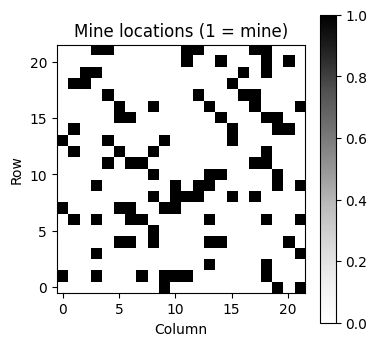

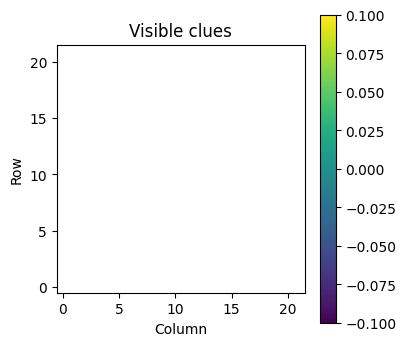

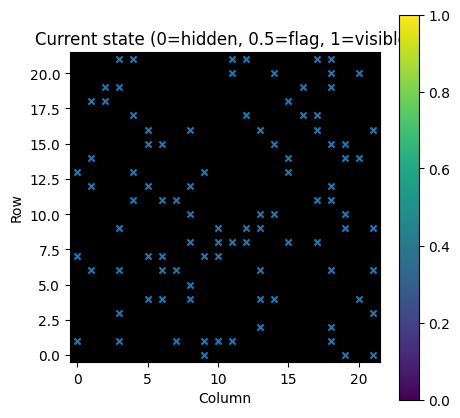

In [ ]:
# Mount drive again and load the board
drive.mount('/content/drive')

base_dir = Path("/content/drive/MyDrive/minesweeper_boards")

# sort boards by difficulty
difficulty = "hard"
files = sorted(base_dir.glob(f"{difficulty}_board_*.npz"))
print("Found", len(files), "easy boards")

# Pick one example file
example_file = files[0]
data = np.load(example_file)

# Extract schema fields
H = int(data["H"])
W = int(data["W"])
board_id = int(data["board_id"])

# handle bytes conversion
raw_mode = data["mode"]
if isinstance(raw_mode, np.ndarray):
    raw_mode = raw_mode.item()
if isinstance(raw_mode, bytes):
    mode = raw_mode.decode("utf-8")
else:
    mode = str(raw_mode)

difficulty_idx = int(data["difficulty_idx"])

mines = data["mines"]       # bool [H, W]
clues = data["clues"]       # int [H, W]
visible = data["visible"]   # bool [H, W]
flags = data["flags"]       # bool [H, W]

print("Loaded file:", example_file.name)
print(f"Mode: {mode} (difficulty_idx={difficulty_idx})  board_id={board_id}")
print(f"Shape: {H} x {W}")
print("Total mines:", mines.sum())

# Show a simple heatmap of mine locations
def plot_mines(mines):
    plt.figure(figsize=(4, 4))
    plt.imshow(mines, cmap="Greys")
    plt.title("Mine locations (1 = mine)")
    plt.colorbar()
    plt.xlabel("Column")
    plt.ylabel("Row")
    plt.gca().invert_yaxis()
    plt.show()

# tries to Show visible cells with clue numbers overlaid
def plot_visible_clues(clues, visible):
    plt.figure(figsize=(4, 4))
    masked = np.ma.array(clues, mask=~visible)  # mask hidden cells
    plt.imshow(masked, cmap="viridis")
    plt.title("Visible clues")
    plt.xlabel("Column")
    plt.ylabel("Row")
    plt.gca().invert_yaxis()
    for i in range(clues.shape[0]):
        for j in range(clues.shape[1]):
            if visible[i, j]:
                v = clues[i, j]
                if v > 0:
                    plt.text(j, i, str(v),
                             ha="center", va="center", fontsize=8)
    plt.colorbar()
    plt.show()

# combine the visual: background vs visible
def plot_current_state(mines, clues, visible, flags, reveal_mines=False):
    H, W = clues.shape
    state_map = np.zeros((H, W), dtype=float)

    # 0 = hidden, 0.5 = flagged, 1 = visible
    state_map[~visible] = 0.0
    state_map[flags] = 0.5
    state_map[visible] = 1.0

    plt.figure(figsize=(5, 5))
    plt.imshow(state_map, cmap="cubehelix")
    plt.title("Current state (0=hidden, 0.5=flag, 1=visible)")
    plt.xlabel("Column")
    plt.ylabel("Row")
    plt.gca().invert_yaxis()

    # Add clue numbers where visible
    for i in range(H):
        for j in range(W):
            if visible[i, j]:
                v = clues[i, j]
                ch = "." if v == 0 else str(v)
                plt.text(j, i, ch, ha="center", va="center", fontsize=8)

    # Optionally overlay mines
    if reveal_mines:
        mine_y, mine_x = np.where(mines)
        plt.scatter(mine_x, mine_y, marker="x", s=20, linewidths=1.5)

    plt.colorbar()
    plt.show()

# visualizers
plot_mines(mines)
plot_visible_clues(clues, visible)
plot_current_state(mines, clues, visible, flags, reveal_mines=True)

## 2) Logic Bot

In [134]:
import numpy as np

# a game enviornment class
class MinesweeperEnv:
    def __init__(self, mines, clues):
        self.mines = mines.astype(bool)
        self.clues = clues.astype(np.int8)
        self.H, self.W = mines.shape

        self.visible = np.zeros_like(self.mines, dtype=bool)
        self.flags   = np.zeros_like(self.mines, dtype=bool)
        self.game_over = False
        self.num_opened = 0

    # allow older code paths that expect env_factory() to return (mines, clues)
    def __len__(self):
        return 2

    def __iter__(self):
        return iter((self.mines, self.clues))

    # helper to define bounds
    def in_bounds(self, i, j):
        return 0 <= i < self.H and 0 <= j < self.W

    # check the neighbor of cell
    def neighbors(self, i, j):
        for di in (-1, 0, 1):
            for dj in (-1, 0, 1):
                if di == 0 and dj == 0:
                    continue
                ni, nj = i + di, j + dj
                if self.in_bounds(ni, nj):
                    yield ni, nj

    # open a cell, returns -1 if mine is triggered, else flood fills if clue = 0
    def open_cell(self, i, j):
        if self.game_over or self.visible[i, j]:
            return False, int(self.clues[i, j])

        if self.mines[i, j]:
            self.visible[i, j] = True
            self.game_over = True
            self.num_opened += 1
            return True, -1  # mine triggered

        # safe cell
        self._flood_reveal(i, j)
        return False, int(self.clues[i, j])

    # Reveal a region of zero-clue cells and their border clues
    def _flood_reveal(self, i, j):
        stack = [(int(i), int(j))]
        while stack:
            ci, cj = stack.pop()
            if self.visible[ci, cj]:
                continue
            self.visible[ci, cj] = True
            self.num_opened += 1
            if int(self.clues[ci, cj]) == 0:
                for ni, nj in self.neighbors(ci, cj):
                    if (not self.visible[ni, nj]) and (not self.mines[ni, nj]):
                        stack.append((int(ni), int(nj)))

    # True if all non-mine cells have been opened
    def all_safe_revealed(self):
        total_safe = int((~self.mines).sum())
        return int(self.num_opened) >= total_safe


First move at (np.int64(0), np.int64(0)) mine? False clue: 0


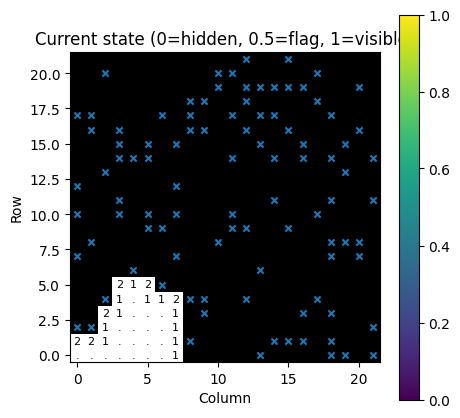

In [135]:
# inspect the loaded board
env = MinesweeperEnv(mines, clues)

# choose a guaranteed-safe first cell any non-mine
safe_positions = np.argwhere(~env.mines)
i0, j0 = safe_positions[0]
is_mine, clue = env.open_cell(i0, j0)

print("First move at", (i0, j0), "mine?", is_mine, "clue:", clue)

# re-use visualizer with env.visible / env.flags to plot the current move
plot_current_state(env.mines, env.clues, env.visible, env.flags, reveal_mines=True)


In [ ]:
# play a single game on the board using the described logic in assignment instgructions
def logic_bot_play(mines, clues, board_id=0, difficulty_idx=0, max_steps=10_000, verbose=False):
    """
    Play a single game on the given board using the project-spec logic bot.
    Returns:
        history: list of dicts, one per step, each containing:
            - 'visible', 'flags', 'mines', 'clues'
            - 'board_id', 'step', 'difficulty_idx'
            - 'game_over', 'hit_mine'
    """
    env = MinesweeperEnv(mines, clues)
    H, W = env.H, env.W

    # Sets from spec
    cells_remaining = {(i, j) for i in range(H) for j in range(W)}
    inferred_safe = set()
    inferred_mine = set()
    clue_number = {}  # (i,j) -> clue value for revealed clue cells

    history = []

    # Helper to update clue_number set from env.visible
    def refresh_clues_from_visible():
        for i in range(H):
            for j in range(W):
                if env.visible[i, j] and not env.mines[i, j]:
                    clue_number[(i, j)] = int(env.clues[i, j])

    # run inference loop once
    def run_inference():
        nonlocal inferred_safe, inferred_mine, cells_remaining
        changed = False

        for (ci, cj), clue in list(clue_number.items()):
            # gather neighbors
            neigh = list(env.neighbors(ci, cj))

            # neighbors already inferred as mines/safe
            neigh_mines = [p for p in neigh if p in inferred_mine]
            neigh_safe  = [p for p in neigh if env.visible[p] or p in inferred_safe]

            # unrevealed neighbors (not visible, not already inferred)
            unrevealed = [
                p for p in neigh
                if (not env.visible[p]) and (p not in inferred_mine) and (p not in inferred_safe)
            ]

            if not unrevealed:
                continue

            # Rule 1:
            # If (cell clue) - (# neighbors inferred to be mines) = (# unrevealed neighbors)
            # then all unrevealed neighbors are mines
            if clue - len(neigh_mines) == len(unrevealed):
                for p in unrevealed:
                    if p not in inferred_mine:
                        inferred_mine.add(p)
                        cells_remaining.discard(p)
                        env.flags[p] = True
                        changed = True
                continue  # move on to next clue cell

            # Rule 2:
            # If ((# neighbors) - (cell clue)) - (# neighbors revealed or inferred safe) = (# unrevealed neighbors)
            # hence all unrevealed neighbors are safe
            num_neighbors = len(neigh)
            safe_count = len(neigh_safe)
            if (num_neighbors - clue) - safe_count == len(unrevealed):
                for p in unrevealed:
                    if p not in inferred_safe:
                        inferred_safe.add(p)
                        cells_remaining.discard(p)
                        changed = True

        return changed

    # Helper that logs the current state to be saved later
    def log_state(step_idx, hit_mine_flag):
        history.append({
            "visible": env.visible.copy(),
            "flags": env.flags.copy(),
            "mines": env.mines.copy(),
            "clues": env.clues.copy(),
            "board_id": board_id,
            "step": step_idx,
            "difficulty_idx": difficulty_idx,
            "game_over": env.game_over,
            "hit_mine": hit_mine_flag,
        })

    # 1) ensure that the first move is guaranted safe first move
    safe_cells = list(zip(*np.where(~env.mines)))
    i0, j0 = random.choice(safe_cells)
    hit_mine, _ = env.open_cell(i0, j0)
    cells_remaining.discard((i0, j0))

    refresh_clues_from_visible()
    log_state(step_idx=0, hit_mine_flag=hit_mine)

    if verbose:
        print(f"[Step 0] First move at {(i0, j0)}, hit_mine={hit_mine}")

    if env.game_over:
        return history  # super unlucky, but possible

    # 2) Main game loop
    step = 1
    while not env.game_over and not env.all_safe_revealed() and step < max_steps:
        # Run inference until no new cells inferred
        while run_inference():
            refresh_clues_from_visible()  # in case new cells got revealed earlier

        # Decide next cell to open
        if inferred_safe:
            # Pick one safe-inferred cell to open
            i, j = inferred_safe.pop()
            if verbose:
                print(f"[Step {step}] Open inferred safe {i, j}")
        else:
            # No safe inference: choose a random remaining cell
            if not cells_remaining:
                break
            i, j = random.choice(list(cells_remaining))
            if verbose:
                print(f"[Step {step}] Random guess at {i, j}")

        cells_remaining.discard((i, j))

        # Open the cell
        hit_mine, _ = env.open_cell(i, j)
        refresh_clues_from_visible()
        log_state(step_idx=step, hit_mine_flag=hit_mine)

        if verbose and hit_mine:
            print(f"|-------> Hit a mine at {i, j}!")

        step += 1

    return history


[Step 0] First move at (np.int64(16), np.int64(12)), hit_mine=False
[Step 1] Random guess at (19, 20)
[Step 2] Random guess at (8, 4)
[Step 3] Random guess at (13, 21)
[Step 4] Random guess at (18, 5)
[Step 5] Random guess at (17, 13)
[Step 6] Random guess at (1, 13)
[Step 7] Random guess at (19, 7)
[Step 8] Open inferred safe (10, 15)
[Step 9] Open inferred safe (9, 14)
[Step 10] Open inferred safe (19, 12)
[Step 11] Open inferred safe (16, 4)
[Step 12] Open inferred safe (18, 14)
[Step 13] Open inferred safe (13, 8)
[Step 14] Open inferred safe (16, 7)
[Step 15] Open inferred safe (15, 8)
[Step 16] Open inferred safe (20, 13)
[Step 17] Open inferred safe (18, 13)
[Step 18] Open inferred safe (12, 15)
[Step 19] Open inferred safe (17, 14)
[Step 20] Open inferred safe (9, 16)
[Step 21] Open inferred safe (19, 14)
[Step 22] Open inferred safe (11, 16)
[Step 23] Open inferred safe (15, 7)
[Step 24] Open inferred safe (13, 16)
[Step 25] Open inferred safe (16, 6)
[Step 26] Open inferred s

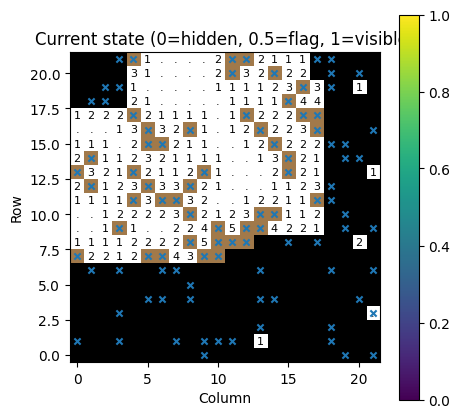

In [ ]:
# test to see if the histories are being stored correctly
test_history = logic_bot_play(mines, clues, board_id=board_id, difficulty_idx=difficulty_idx, verbose=True)
print("Steps played:", len(test_history))
print("Final state: game_over =", test_history[-1]["game_over"],
      "hit_mine =", test_history[-1]["hit_mine"])

# visualize the final board state
final = test_history[-1]
plot_current_state(final["mines"], final["clues"], final["visible"], final["flags"], reveal_mines=True)


### now run the game for many boards

In [ ]:
# a helper that converts a snapshot to a sample that can be used later
def snapshot_to_sample(snap):
    """
    snapshot dict into:
      - input_state: [3, H, W]
      - target_mines: [1, H, W]
      - loss_mask: [1, H, W]
    """
    mines   = snap["mines"].astype(bool)
    clues   = snap["clues"].astype(np.int8)
    visible = snap["visible"].astype(bool)
    flags   = snap["flags"].astype(bool)

    H, W = mines.shape

    inp = np.zeros((3, H, W), dtype=np.float32)

    # ch0: visible mask
    inp[0] = visible.astype(np.float32)

    # ch1: clue values where visible, 0 elsewhere
    clue_chan = np.zeros((H, W), dtype=np.float32)
    clue_chan[visible] = clues[visible].astype(np.float32)
    inp[1] = clue_chan

    # ch2: flag mask
    inp[2] = flags.astype(np.float32)

    # target mines: 1 if mine, 0 if safe
    target = mines.astype(np.int8)[None, ...]      # [1, H, W]

    # loss mask: only currently hidden cells contribute to loss
    loss_mask = (~visible).astype(bool)[None, ...] # [1, H, W]

    return inp, target, loss_mask

In [ ]:
# Rebuild datasets from saved boards and overwrite {easy,medium,hard}_train.npz
from pathlib import Path
import numpy as np
import shutil, os, gc

boards_dir = Path("/content/drive/MyDrive/minesweeper_boards")
data_dir_drive = Path("/content/drive/MyDrive/minesweeper_data")
data_dir_drive.mkdir(parents=True, exist_ok=True)

# local output is much faster than writing directly to Drive
data_dir_local = Path("/content/minesweeper_data")
data_dir_local.mkdir(parents=True, exist_ok=True)

difficulties = ["easy", "medium", "hard"]

# Large cap so it is not "too few", but avoids extremely slow runs on thousands of boards
MAX_BOARDS_PER_DIFFICULTY = 400

for d in difficulties:
    board_files = sorted(boards_dir.glob(f"{d}_board_*.npz"))
    print("Found", len(board_files), d, "boards")

    if len(board_files) == 0:
        continue

    if MAX_BOARDS_PER_DIFFICULTY is not None and len(board_files) > int(MAX_BOARDS_PER_DIFFICULTY):
        board_files = board_files[:int(MAX_BOARDS_PER_DIFFICULTY)]
        print("Using", len(board_files), d, "boards")

    # Accumulators
    inputs_list = []
    targets_list = []
    loss_masks_list = []
    board_ids_list = []
    steps_list = []
    difficulties_list = []

    for bi, f in enumerate(board_files, start=1):
        with np.load(str(f), allow_pickle=False) as data:
            mines = data["mines"]
            clues = data["clues"]
            board_id = int(data["board_id"])
            difficulty_idx = int(data["difficulty_idx"])

        history = logic_bot_play(
            mines,
            clues,
            board_id=board_id,
            difficulty_idx=difficulty_idx,
            verbose=False,
        )

        for snap in history:
            inp, tgt, msk = snapshot_to_sample(snap)
            inputs_list.append(inp)
            targets_list.append(tgt)
            loss_masks_list.append(msk)
            board_ids_list.append(int(snap["board_id"]))
            steps_list.append(int(snap["step"]))
            difficulties_list.append(int(snap["difficulty_idx"]))

        if bi % 200 == 0:
            print(d, "processed", bi, "of", len(board_files), "boards",
                  "snapshots", len(inputs_list))

    print("Total snapshots collected:", len(inputs_list))

    # Stack into arrays and save
    inputs = np.stack(inputs_list, axis=0)          # [N, 3, H, W]
    targets = np.stack(targets_list, axis=0)        # [N, 1, H, W]
    loss_masks = np.stack(loss_masks_list, axis=0)  # [N, 1, H, W]
    board_ids = np.asarray(board_ids_list, dtype=np.int32)
    steps = np.asarray(steps_list, dtype=np.int32)
    difficulties_arr = np.asarray(difficulties_list, dtype=np.int8)

    print("Dataset shapes:")
    print("  inputs     :", inputs.shape)
    print("  targets    :", targets.shape)
    print("  loss_masks :", loss_masks.shape)

    out_local = data_dir_local / f"{d}_train.npz"
    np.savez(
        str(out_local),
        inputs=inputs,
        targets=targets,
        loss_masks=loss_masks,
        board_ids=board_ids,
        steps=steps,
        difficulties=difficulties_arr,
    )
    print("Saved dataset locally to:", out_local)

    out_drive = data_dir_drive / out_local.name
    shutil.copy2(str(out_local), str(out_drive))
    print("Copied dataset to Drive:", out_drive)

    # Free memory between difficulties
    del inputs_list, targets_list, loss_masks_list, board_ids_list, steps_list, difficulties_list
    del inputs, targets, loss_masks, board_ids, steps, difficulties_arr
    gc.collect()


Found 7800 easy boards
Using 400 easy boards
easy processed 200 of 400 boards snapshots 18831
easy processed 400 of 400 boards snapshots 37459
Total snapshots collected: 37459
Dataset shapes:
  inputs     : (37459, 3, 22, 22)
  targets    : (37459, 1, 22, 22)
  loss_masks : (37459, 1, 22, 22)
Saved dataset locally to: /content/minesweeper_data/easy_train.npz
Copied dataset to Drive: /content/drive/MyDrive/minesweeper_data/easy_train.npz
Found 7900 medium boards
Using 400 medium boards
medium processed 200 of 400 boards snapshots 26310
medium processed 400 of 400 boards snapshots 50272
Total snapshots collected: 50272
Dataset shapes:
  inputs     : (50272, 3, 22, 22)
  targets    : (50272, 1, 22, 22)
  loss_masks : (50272, 1, 22, 22)
Saved dataset locally to: /content/minesweeper_data/medium_train.npz
Copied dataset to Drive: /content/drive/MyDrive/minesweeper_data/medium_train.npz
Found 7900 hard boards
Using 400 hard boards
hard processed 200 of 400 boards snapshots 12764
hard process

### basic eda

N snapshots: 37459
inputs shape: (37459, 3, 22, 22)
targets shape: (37459, 1, 22, 22)
unique boards: 400


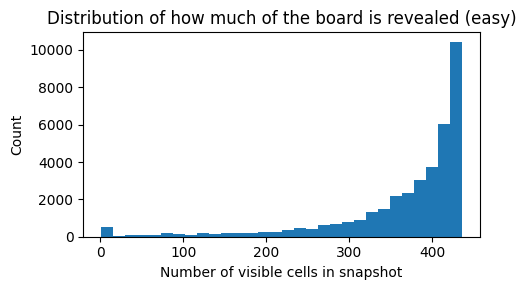

Hidden cells in dataset: 4427461
Hidden cells that are mines: 1797958
Mine fraction among hidden cells: 0.4061


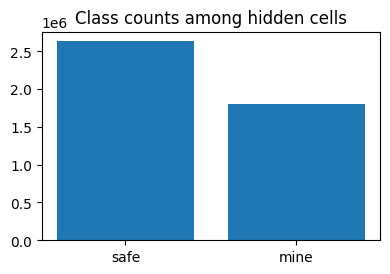

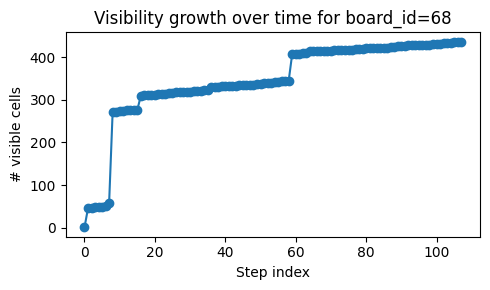

In [ ]:
data_dir = Path("/content/drive/MyDrive/minesweeper_data")

ds = np.load(data_dir / "easy_train.npz")
inputs      = ds["inputs"]        # [N, 3, 22, 22]
targets     = ds["targets"]       # [N, 1, 22, 22]
loss_masks  = ds["loss_masks"]    # [N, 1, 22, 22]
board_ids   = ds["board_ids"]     # [N]
steps       = ds["steps"]         # [N]
difficulties = ds["difficulties"] # [N]

print("N snapshots:", inputs.shape[0])
print("inputs shape:", inputs.shape)
print("targets shape:", targets.shape)
print("unique boards:", np.unique(board_ids).size)

# channel 0 = visible mask
visible = inputs[:, 0, :, :] > 0.5   # [N, 22, 22]
visible_counts = visible.sum(axis=(1, 2))

plt.figure(figsize=(5, 3))
plt.hist(visible_counts, bins=30)
plt.xlabel("Number of visible cells in snapshot")
plt.ylabel("Count")
plt.title("Distribution of how much of the board is revealed (easy)")
plt.tight_layout()
plt.show()

# only care about cells where loss_mask == 1 (currently hidden)
hidden_mask = loss_masks.astype(bool)  # [N, 1, 22, 22]
hidden_targets = targets[hidden_mask]  # 1D array of 0/1

num_hidden = hidden_targets.size
num_mines = hidden_targets.sum()
mine_fraction = num_mines / num_hidden

print("Hidden cells in dataset:", num_hidden)
print("Hidden cells that are mines:", num_mines)
print("Mine fraction among hidden cells: {:.4f}".format(mine_fraction))

plt.figure(figsize=(4, 3))
plt.bar(["safe", "mine"], [num_hidden - num_mines, num_mines])
plt.title("Class counts among hidden cells")
plt.tight_layout()
plt.show()

# pick a random board from the easy split to see how visibility grows over time
unique_boards = np.unique(board_ids)
bid = int(np.random.choice(unique_boards))
mask = (board_ids == bid)

board_steps = steps[mask]
board_visible_counts = visible_counts[mask]

# sort by step index just in case
order = np.argsort(board_steps)
board_steps = board_steps[order]
board_visible_counts = board_visible_counts[order]

plt.figure(figsize=(5, 3))
plt.plot(board_steps, board_visible_counts, marker="o")
plt.xlabel("Step index")
plt.ylabel("# visible cells")
plt.title(f"Visibility growth over time for board_id={bid}")
plt.tight_layout()
plt.show()



### eda analysis
From these EDA plots, I see that visibility on a single board grows in bursts rather than smoothly, with large jumps when opening a zero region and then slower incremental gains, which matches how Minesweeper cascades reveals. Looking at class counts among hidden cells, I have more safe examples than mine examples, but the imbalance is moderate, so the model still sees plenty of mines while learning a probability map. The histogram of revealed cells per snapshot is strongly skewed toward late game states, meaning most of my training snapshots happen when a large fraction of the board is already visible, and comparatively few samples come from very early game situations, so I should expect the model to learn late game patterns more easily unless I rebalance or sample more early snapshots.


# TASK 1) Task 1: Playing by Mine Prediction
## 3) build and Train the model


---



In [ ]:
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

data_dir = Path("/content/drive/MyDrive/minesweeper_data")

# Load easy, medium, hard datasets and concatenate along the snapshot axis
def load_all_difficulties():
    all_inputs = []
    all_targets = []
    all_masks = []
    all_board_ids = []
    all_steps = []
    all_difficulties = []

    for diff_name in ["easy", "medium", "hard"]:
        ds = np.load(data_dir / f"{diff_name}_train.npz")
        all_inputs.append(ds["inputs"])
        all_targets.append(ds["targets"])
        all_masks.append(ds["loss_masks"])
        all_board_ids.append(ds["board_ids"])
        all_steps.append(ds["steps"])
        all_difficulties.append(ds["difficulties"])

    inputs = np.concatenate(all_inputs, axis=0)
    targets = np.concatenate(all_targets, axis=0)
    loss_masks = np.concatenate(all_masks, axis=0)
    board_ids = np.concatenate(all_board_ids, axis=0)
    steps = np.concatenate(all_steps, axis=0)
    difficulties = np.concatenate(all_difficulties, axis=0)

    return inputs, targets, loss_masks, board_ids, steps, difficulties

inputs, targets, loss_masks, board_ids, steps, difficulties = load_all_difficulties()

print("Snapshots:", inputs.shape[0])
print("Unique boards:", np.unique(board_ids).size)
print("Difficulty indices present:", np.unique(difficulties))

# split by board_id to avoid leakage across splits
rng = np.random.default_rng(123)
unique_boards = np.unique(board_ids)
rng.shuffle(unique_boards)

n_boards = len(unique_boards)
n_train = int(0.7 * n_boards)
n_val   = int(0.15 * n_boards)

# make the train, val and test boards
train_boards = unique_boards[:n_train]
val_boards   = unique_boards[n_train:n_train+n_val]
test_boards  = unique_boards[n_train+n_val:]

def make_index_mask(allowed_board_ids):
    allowed = set(allowed_board_ids)
    return np.where(np.isin(board_ids, list(allowed)))[0]

train_idx = make_index_mask(train_boards)
val_idx   = make_index_mask(val_boards)
test_idx  = make_index_mask(test_boards)

print("Train snapshots:", train_idx.size)
print("Val snapshots  :", val_idx.size)
print("Test snapshots :", test_idx.size)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # enable GPU acceleration
device

Snapshots: 111495
Unique boards: 1000
Difficulty indices present: [0 1 2]
Train snapshots: 79292
Val snapshots  : 16704
Test snapshots : 15499


device(type='cuda')

In [ ]:
# a minesweeper dataset that is used across all tasks
class MinesweeperDataset(Dataset):
    def __init__(self, inputs, targets, masks, indices):
        self.inputs  = inputs
        self.targets = targets
        self.masks   = masks
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]
        x = self.inputs[i]        # [3, H, W]
        y = self.targets[i]       # [1, H, W]
        m = self.masks[i]         # [1, H, W]
        return (
            torch.from_numpy(x).float(),
            torch.from_numpy(y).float(),
            torch.from_numpy(m).float(),
        )

# loaders for the 3 sets of data
def make_loader(indices, batch_size=64, shuffle=False):
    ds = MinesweeperDataset(inputs, targets, loss_masks, indices)
    loader = DataLoader(ds, batch_size=batch_size,
                        shuffle=shuffle, drop_last=False)
    return loader

batch_size = 64 # tried with 128 but got worse isntead

train_loader = make_loader(train_idx, batch_size=batch_size, shuffle=True)
val_loader   = make_loader(val_idx,   batch_size=batch_size, shuffle=False)
test_loader  = make_loader(test_idx,  batch_size=batch_size, shuffle=False)


### Simple CNN with per cell logits

In [ ]:
# simple CNN with 2 convolutional layers for comparison
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(channels)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = x + out
        out = F.relu(out)
        return out

# a reasoning net
class MineResNet(nn.Module):
    def __init__(self, in_channels=3, width=64, depth=8):
        """
        in_channels: number of input channels (visible mask, clues, flags)
        width: number of feature channels in the residual stack
        depth: number of residual blocks to apply
        """
        super().__init__()
        self.stem = nn.Conv2d(in_channels, width, kernel_size=3, padding=1)

        self.blocks = nn.ModuleList(
            [ResidualBlock(width) for _ in range(depth)]
        )

        self.out = nn.Conv2d(width, 1, kernel_size=1)

    def forward(self, x):
        x = F.relu(self.stem(x))
        for block in self.blocks:
            x = block(x)
        logits = self.out(x)
        return logits

# bce since it directly measures how well those predicted probabilities match the true binary
def masked_bce_loss(logits, targets, masks):
    """
    logits: [B, 1, H, W]
    targets: [B, 1, H, W]
    masks: [B, 1, H, W]   1 = include in loss, 0 = ignore
    """
    bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    masked = bce * masks
    denom = masks.sum()
    if denom == 0:
        return masked.sum()
    return masked.sum() / denom


In [ ]:
# helper to run the epoch
def run_epoch(model, loader, optimizer=None):
    train = optimizer is not None
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_cells = 0
    total_correct = 0
    total_eval_cells = 0

    for x, y, m in loader:
        x = x.to(device)
        y = y.to(device)
        m = m.to(device)

        if train:
            optimizer.zero_grad()

        logits = model(x)
        loss = masked_bce_loss(logits, y, m) # use bce loss becasue model is predicting per cell probab

        if train:
            loss.backward()
            optimizer.step()

        cells = m.sum().item()
        total_loss += loss.item() * max(cells, 1)
        total_cells += max(cells, 1)

        with torch.no_grad():
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            correct = ((preds == y) * m).sum().item()
            total_correct += correct
            total_eval_cells += cells

    avg_loss = total_loss / max(total_cells, 1)
    acc = total_correct / max(total_eval_cells, 1) if total_eval_cells > 0 else 0.0
    return avg_loss, acc

# model and optimizer for mixed difficulties
model = MineResNet(in_channels=3, width=64, depth=8).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

num_epochs = 20  # cap at 20

Epoch 01 | train_loss=0.2653, train_acc=0.900 | val_loss=0.4780, val_acc=0.859
Epoch 02 | train_loss=0.1670, train_acc=0.938 | val_loss=0.5095, val_acc=0.853
Epoch 03 | train_loss=0.1244, train_acc=0.954 | val_loss=0.6468, val_acc=0.853
Epoch 04 | train_loss=0.1031, train_acc=0.962 | val_loss=0.7476, val_acc=0.853
Epoch 05 | train_loss=0.0902, train_acc=0.967 | val_loss=0.8024, val_acc=0.847
Epoch 06 | train_loss=0.0815, train_acc=0.970 | val_loss=0.8673, val_acc=0.842
Epoch 07 | train_loss=0.0747, train_acc=0.973 | val_loss=0.9592, val_acc=0.846
Epoch 08 | train_loss=0.0697, train_acc=0.974 | val_loss=0.9715, val_acc=0.843
Epoch 09 | train_loss=0.0656, train_acc=0.976 | val_loss=0.8874, val_acc=0.841
Epoch 10 | train_loss=0.0623, train_acc=0.977 | val_loss=1.0018, val_acc=0.840
Epoch 11 | train_loss=0.0594, train_acc=0.978 | val_loss=0.9749, val_acc=0.841
Epoch 12 | train_loss=0.0570, train_acc=0.979 | val_loss=1.1115, val_acc=0.840
Epoch 13 | train_loss=0.0548, train_acc=0.980 | val_

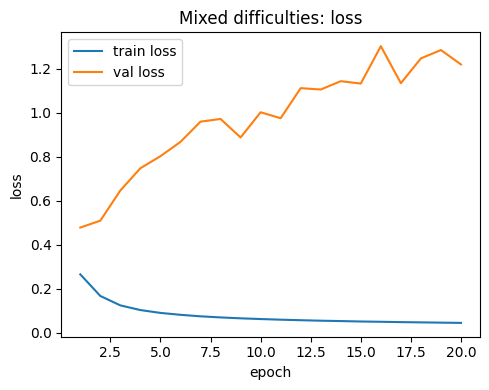

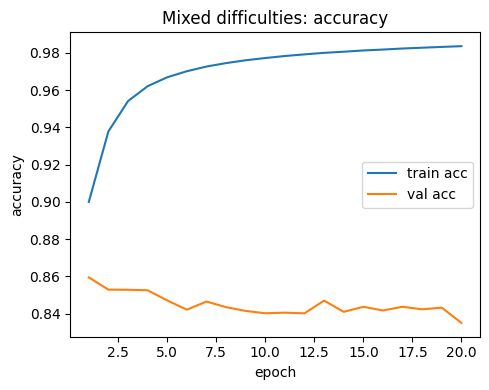

In [ ]:

train_losses = []
val_losses   = []
train_accs   = []
val_accs     = []
# run the experiments
for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss,   val_acc   = run_epoch(model, val_loader,   optimizer=None)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.3f} | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.3f}"
    )

test_loss, test_acc = run_epoch(model, test_loader, optimizer=None)
print(f"\nTEST overall: loss={test_loss:.4f}, acc={test_acc:.3f}")

epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(5, 4))
plt.plot(epochs_range, train_losses, label="train loss")
plt.plot(epochs_range, val_losses,   label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Mixed difficulties: loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
plt.plot(epochs_range, train_accs, label="train acc")
plt.plot(epochs_range, val_accs,   label="val acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Mixed difficulties: accuracy")
plt.legend()
plt.tight_layout()
plt.show()


Test easy: loss=0.6113, acc=0.911
Test medium: loss=1.1787, acc=0.836
Test hard: loss=1.7569, acc=0.764


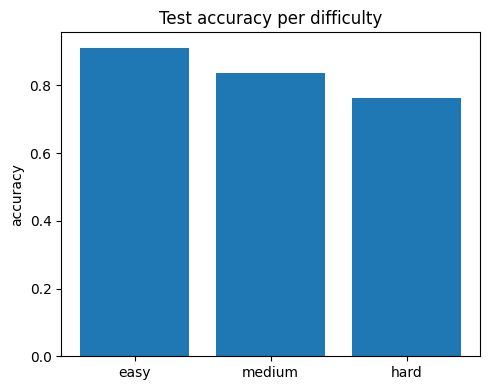

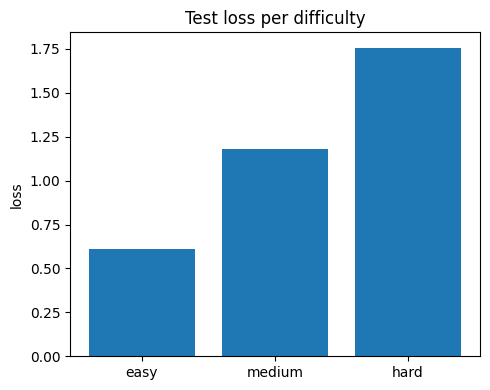

In [ ]:
# evaluate how the res-net model did on each subset of data ["Easy", "medum", "hard"]
def evaluate_subset(model, subset_indices):
    loader = make_loader(subset_indices, batch_size=64, shuffle=False)
    loss, acc = run_epoch(model, loader, optimizer=None)
    return loss, acc

# map from difficulty index to name
diff_map = {0: "easy", 1: "medium", 2: "hard"}

test_results = {} # store results

for diff_idx in sorted(np.unique(difficulties)):
    # indices in test split with this difficulty
    mask = (difficulties == diff_idx)
    subset_idx = test_idx[np.isin(test_idx, np.where(mask)[0])]

    if subset_idx.size == 0:
        print(f"No test samples for difficulty idx {diff_idx}")
        continue

    loss_d, acc_d = evaluate_subset(model, subset_idx)
    name = diff_map.get(int(diff_idx), f"diff_{diff_idx}")
    test_results[name] = (loss_d, acc_d)
    print(f"Test {name}: loss={loss_d:.4f}, acc={acc_d:.3f}")


names = list(test_results.keys())
loss_values = [test_results[n][0] for n in names]
acc_values  = [test_results[n][1] for n in names]

# test accuracy plot
plt.figure(figsize=(5, 4))
plt.bar(names, acc_values)
plt.ylabel("accuracy")
plt.title("Test accuracy per difficulty")
plt.tight_layout()
plt.show()

# test loss plot
plt.figure(figsize=(5, 4))
plt.bar(names, loss_values)
plt.ylabel("loss")
plt.title("Test loss per difficulty")
plt.tight_layout()
plt.show()

In [ ]:
# save model to google drive for use later

from pathlib import Path
import torch

save_dir = Path("/content/drive/MyDrive/minesweeper_models")
save_dir.mkdir(parents=True, exist_ok=True)

# name indicates mixed training on easy, medium, and hard
model_path = save_dir / "mineres_net_mixed_all_difficulties.pth"
torch.save(model.state_dict(), model_path)
print("Saved model to:", model_path)


Saved model to: /content/drive/MyDrive/minesweeper_models/mineres_net_mixed_all_difficulties.pth


## Task 1 Writeup

For Task 1, I trained a mine prediction network on mixed difficulties and evaluated it using loss, accuracy, and downstream gameplay behavior across easy, medium, and hard boards. During training, the model fit the training data quickly, with training loss decreasing steadily and training accuracy approaching saturation, while validation loss increased and validation accuracy plateaued and slowly declined. This gap indicates overfitting, which is expected given the heavy skew of snapshots toward late game states and the increased ambiguity in early game positions. On held out test games, performance degraded as difficulty increased, with the highest accuracy and lowest loss on easy boards and progressively worse results on medium and hard boards. This matches the intuition that higher mine density creates more ambiguous local patterns, making mine probability prediction inherently harder. Despite this, the model maintained reasonable accuracy across all difficulties and produced stable probability maps that could be used for gameplay decisions
The model architecture I used for this task was a residual convolutional network designed to capture spatial dependencies beyond immediate neighbors. The network takes as input a stack of game state channels including visible cells, clue values, and flags, and processes them through an initial convolution followed by a deep stack of residual blocks to allow iterative refinement of spatial reasoning. A final one by one convolution produces a per cell mine logit. I trained the model using a masked binary cross entropy loss so that loss was only applied to currently hidden cells, which directly aligns the objective with predicting mine probabilities. This setup allows the model to learn probabilistic spatial structure in the board while ignoring already revealed information, and it provides a clean comparison point against the logic bot in terms of survival length, mine hit rate, and overall board clearing behavior across difficulties.
---

# Task 2 Playing by Move Prediction

In [ ]:
# Task 2: Adapters for MinesweeperEnv API (visible/flags/game_over/open_cell)
# - Make encoding robust and consistent (float32 CHW)
# - Ensure unopened listing ignores flagged
# - Keep deepcopy cloning
# - Keep opened_new via num_opened delta when available

import numpy as np
import random
import copy
from dataclasses import dataclass
from typing import List, Tuple, Set, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ROLLOUT_CAP = 300

# Returns float32 tensor (C, H, W) for the current player-visible state
def encode_state_from_env(env) -> np.ndarray:
    """
    Channels:
      0: visible mask (1.0 for revealed, 0.0 for hidden)
      1: visible clues normalized to [0,1] for revealed, 0 for hidden
      2: flags mask (1.0 for flagged, 0.0 otherwise)
    """
    visible = env.visible.astype(np.float32)
    flags = env.flags.astype(np.float32)

    # clues are meaningful only for visible cells
    # normalize by 8 to keep scale stable
    clues_vis = (env.clues.astype(np.float32) * visible) / 8.0

    x = np.stack([visible, clues_vis, flags], axis=0).astype(np.float32)
    return x

# Returns unopened and unflagged cells
def list_unopened_cells(env) -> List[Tuple[int, int]]:
    H, W = env.H, env.W
    coords: List[Tuple[int, int]] = []
    vis = env.visible
    flg = env.flags
    for i in range(H):
        for j in range(W):
            if (not bool(vis[i, j])) and (not bool(flg[i, j])):
                coords.append((int(i), int(j)))
    return coords


@dataclass
class StepResult:
    done: bool
    hit_mine: bool
    opened_new: int

# Opens a cell using env.open_cell(i, j)
# returns stepResult with an aprox opened_new count
def open_cell(env, i: int, j: int) -> StepResult:
    """
    opened_new is estimated by tracking env.num_opened delta.
    """
    before = int(getattr(env, "num_opened", int(np.sum(env.visible))))
    hit_mine, _clue = env.open_cell(int(i), int(j))
    after = int(getattr(env, "num_opened", int(np.sum(env.visible))))

    opened_new = max(0, after - before)
    done = bool(getattr(env, "game_over", False)) or bool(env.all_safe_revealed())

    return StepResult(done=done, hit_mine=bool(hit_mine), opened_new=int(opened_new))

# Clones MinesweeperEnv using deepcopy
def clone_env(env):
    return copy.deepcopy(env)

In [ ]:
# Task 2: Logic bot inference and rollout survival
# - Add a slightly randomized rollout policy option
# - Add multi-rollout averaged survival estimate for lower-noise labels

from typing import List, Tuple, Set

# get all the neighbords
def _neighbors_coords(env, i: int, j: int) -> List[Tuple[int, int]]:
    return list(env.neighbors(int(i), int(j)))

# Runs one inference pass over all revealed clue cells
def logic_infer_step(env) -> Tuple[Set[Tuple[int, int]], Set[Tuple[int, int]]]:
    """
    Returns:
      inferred_safe: set of (i, j) that can be safely opened
      inferred_mine: set of (i, j) that can be marked as mines (flags)
    """
    inferred_safe: Set[Tuple[int, int]] = set()
    inferred_mine: Set[Tuple[int, int]] = set()

    H, W = env.H, env.W
    vis = env.visible
    flg = env.flags
    clues = env.clues

    for i in range(H):
        for j in range(W):
            if not bool(vis[i, j]):
                continue

            clue = int(clues[i, j])
            if clue < 0:
                continue

            neigh = _neighbors_coords(env, i, j) # get a neighbor

            flagged = [(ni, nj) for (ni, nj) in neigh if bool(flg[ni, nj])]
            num_flagged = len(flagged) # see if its flagged

            unknown = [(ni, nj) for (ni, nj) in neigh if (not bool(vis[ni, nj])) and (not bool(flg[ni, nj]))]
            num_unknown = len(unknown)

            mines_left = clue - num_flagged
            if mines_left == num_unknown and num_unknown > 0:
                for cell in unknown:
                    inferred_mine.add(cell)

            if mines_left == 0 and num_unknown > 0:
                for cell in unknown:
                    inferred_safe.add(cell)

    inferred_safe = inferred_safe - inferred_mine
    return inferred_safe, inferred_mine

# Runs a logic bot from the current env state until termination
def logic_bot_rollout_survival(env, step_cap: int = ROLLOUT_CAP, eps_random: float = 0.15) -> int:
    """
    Returns number of open actions taken

    eps_random:
      with probability eps_random, ignore inference and do a random legal move
      this makes survival labels less brittle/deterministic
    """
    moves = 0

    for _ in range(int(step_cap)):
        if env.game_over or env.all_safe_revealed():
            break

        # Sometimes do a random move to reduce deterministic artifacts
        if random.random() < float(eps_random):
            unopened = list_unopened_cells(env)
            if len(unopened) == 0:
                break
            i, j = random.choice(unopened)
            sr = open_cell(env, i, j)
            moves += 1
            if sr.hit_mine or sr.done:
                break
            continue

        # Otherwise, do inference
        inferred_safe, inferred_mine = logic_infer_step(env)

        # Apply mine inferences by flagging
        for (i, j) in inferred_mine:
            if (not env.visible[i, j]) and (not env.flags[i, j]):
                env.flags[i, j] = True

        if len(inferred_safe) > 0:
            # Open one safe cell at a time (keeps rollout cheap and stable)
            i, j = next(iter(inferred_safe))
            if (not env.visible[i, j]) and (not env.flags[i, j]):
                sr = open_cell(env, i, j)
                moves += 1
                if sr.hit_mine or sr.done:
                    break
                continue

        # No safe inference available so random guess among unopened/unflagged
        unopened = list_unopened_cells(env)
        if len(unopened) == 0:
            break
        i, j = random.choice(unopened)
        sr = open_cell(env, i, j)
        moves += 1
        if sr.hit_mine or sr.done:
            break

    return int(moves)


@torch.no_grad()
def estimate_survival_after_action(env, action_rc: Tuple[int, int], rollout_cap: int = ROLLOUT_CAP, n_rollouts: int = 3, eps_random: float = 0.15) -> float:
    """
    Lower-noise label for critic training:
      Apply chosen action once, then rollout with logic bot + a bit of randomness
      Average survival over n_rollouts
    """
    if action_rc is None:
        return 0.0

    total = 0.0
    for _k in range(int(n_rollouts)):
        e = clone_env(env)
        sr = open_cell(e, int(action_rc[0]), int(action_rc[1]))
        if sr.hit_mine or sr.done:
            total += 0.0
            continue

        # count includes the chosen action
        moves = 1 + logic_bot_rollout_survival(e, step_cap=int(rollout_cap) - 1, eps_random=float(eps_random))
        total += float(moves)

    return float(total / float(max(1, int(n_rollouts))))

### # Task 2: Critic0 labeled data generation using logic bot survivability

In [ ]:
from dataclasses import dataclass
from typing import Callable, List, Tuple
import random
import numpy as np

@dataclass
class MoveLabel:
    state: np.ndarray
    action_rc: Tuple[int, int]
    target_survival: float

def _progress_fraction(env) -> float:
    # Use num_opened if present, else fall back to visible sum.
    total = float(env.H * env.W)
    opened = float(getattr(env, "num_opened", int(np.sum(env.visible))))
    return opened / max(1.0, total)

#     Generates partial env states within a mid-game progress range
def generate_partial_states(
    env_factory,
    n_states,
    warmup_min=6,
    warmup_max=80,
    prog_min=0.10,
    prog_max=0.55,
    max_tries_per_state=8,
    eps_random=0.15,
):
    """
      Returns env objects in the desired progress band
    """
    states = []
    tries = 0

    while len(states) < int(n_states) and tries < int(n_states) * int(max_tries_per_state):
        tries += 1
        env = env_factory()
        warmup_steps = random.randint(int(warmup_min), int(warmup_max))

        moves_done = 0
        while moves_done < warmup_steps and (not env.game_over) and (not env.all_safe_revealed()):
            # Sometimes randomize to diversify states and avoid deterministic artifacts
            if random.random() < float(eps_random):
                unopened = list_unopened_cells(env)
                if len(unopened) == 0:
                    break
                i, j = random.choice(unopened)
            else:
                inferred_safe, inferred_mine = logic_infer_step(env)

                for (i, j) in inferred_mine:
                    if (not env.visible[i, j]) and (not env.flags[i, j]):
                        env.flags[i, j] = True

                if inferred_safe:
                    i, j = next(iter(inferred_safe))
                else:
                    unopened = list_unopened_cells(env)
                    if len(unopened) == 0:
                        break
                    i, j = random.choice(unopened)

            sr = open_cell(env, int(i), int(j))
            moves_done += 1
            if sr.hit_mine or sr.done:
                break

        if env.game_over or env.all_safe_revealed():
            continue

        p = _progress_fraction(env)
        if float(prog_min) <= p <= float(prog_max):
            states.append(env)

    return states

# fir each mid game state, sample cadidate unopened cells and estimate survival for each candidate as an AVG over specied rollouts
def generate_critic0_labels(
    env_factory: Callable[[], object],
    n_states: int,
    moves_per_state: int,
    step_cap: int = ROLLOUT_CAP,
    horizon: int = 120,
    n_rollouts: int = 3,
    eps_random: float = 0.15,
) -> List[MoveLabel]:

    partial_envs = generate_partial_states(
        env_factory,
        n_states=int(n_states),
        eps_random=float(eps_random),
    )

    samples: List[MoveLabel] = []

    for env in partial_envs:
        s = encode_state_from_env(env)
        candidates = list_unopened_cells(env)
        if len(candidates) == 0:
            continue

        chosen = random.sample(candidates, k=min(int(moves_per_state), len(candidates)))

        for (i, j) in chosen:
            # Average survival over n_rollouts for this (state, action)
            total = 0.0
            for _k in range(int(n_rollouts)):
                env2 = clone_env(env)
                sr = open_cell(env2, int(i), int(j))

                if sr.hit_mine or sr.done:
                    total += 0.0
                    continue

                # include the chosen action as 1 move, then rollout
                raw = 1.0 + float(logic_bot_rollout_survival(env2, step_cap=int(step_cap) - 1, eps_random=float(eps_random)))
                total += float(raw)

            avg = total / float(max(1, int(n_rollouts)))
            target = float(min(avg, float(horizon)))

            samples.append(MoveLabel(state=s, action_rc=(int(i), int(j)), target_survival=target))

    return samples

In [ ]:
from pathlib import Path
import numpy as np

SAVE_DIR = Path("/content/drive/MyDrive/minesweeper_task2")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

OUT_PATH = SAVE_DIR / "critic0_labels_medium_146k.npz"

# Label generation settings - max = 4000 * 16 = 64000
N_STATES = 4000
MOVES_PER_STATE = 16
N_ROLLOUTS = 3         #average over multiple rollouts
HORIZON = 120          # cap to reduce variance
EPS_RANDOM = 0.15      # small randomization in rollout + warmup
STEP_CAP = ROLLOUT_CAP

# 1) Load if it already exists
if OUT_PATH.exists():
    data = np.load(OUT_PATH)
    X, A, Y = data["X"], data["A"], data["Y"]
    print("Loaded cached labels:", OUT_PATH)
    print("X:", X.shape, "A:", A.shape, "Y:", Y.shape)
else:
    # 2) Otherwise generate and then save
    rng_task2 = np.random.default_rng(123)

    def env_factory():
        mines, clues, _visible, _flags = generate_board("medium", rng=rng_task2, H=H, W=W)
        env = MinesweeperEnv(mines=mines, clues=clues)

        # Ensure start from a safe opening
        safe_positions = np.argwhere(~env.mines)
        i0, j0 = safe_positions[rng_task2.integers(0, len(safe_positions))]
        env.open_cell(int(i0), int(j0))
        return env

    labels = generate_critic0_labels(
        env_factory=env_factory,
        n_states=int(N_STATES),
        moves_per_state=int(MOVES_PER_STATE),
        step_cap=int(STEP_CAP),
        horizon=int(HORIZON),
        n_rollouts=int(N_ROLLOUTS),
        eps_random=float(EPS_RANDOM),
    )

    print("Total labeled (state, action) examples:", len(labels))

    X = np.stack([ml.state for ml in labels], axis=0).astype(np.float32)
    A = np.stack([ml.action_rc for ml in labels], axis=0).astype(np.int16)
    Y = np.array([ml.target_survival for ml in labels], dtype=np.float32)

    np.savez_compressed(OUT_PATH, X=X, A=A, Y=Y)
    print("Saved: ", OUT_PATH, "size in mb: ", OUT_PATH.stat().st_size / (1024 * 1024))
    print("X:", X.shape, "A:", A.shape, "Y:", Y.shape)

    # Quick sanity checks (helpful debugging)
    print("Y mean:", float(Y.mean()), "Y median:", float(np.median(Y)))


Loaded cached labels: /content/drive/MyDrive/minesweeper_task2/critic0_labels_medium_146k.npz
X: (64000, 3, 22, 22) A: (64000, 2) Y: (64000,)


In [ ]:
# Load labels from drive
save_dir = Path("/content/drive/MyDrive/minesweeper_task2")
out_path = save_dir / "critic0_labels_medium_146k.npz"

assert out_path.exists(), f"File not found: {out_path}"

data = np.load(out_path)
X = data["X"]
A = data["A"]
Y = data["Y"]

print("Loaded:", out_path)
print("X.shape:", X.shape, X.dtype)
print("A hape:", A.shape, A.dtype)
print("Y shape:", Y.shape, Y.dtype)

Loaded: /content/drive/MyDrive/minesweeper_task2/critic0_labels_medium_146k.npz
X.shape: (64000, 3, 22, 22) float32
A hape: (64000, 2) int16
Y shape: (64000,) float32


In [ ]:
# Task 2: Load saved labels and prepare CPU tensors for training
# - Keep dataset on CPU; move only mini-batches to GPU

from pathlib import Path
import numpy as np
import torch

in_path = Path("/content/drive/MyDrive/minesweeper_task2/critic0_labels_medium_146k.npz")
data = np.load(in_path, allow_pickle=False)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X = data["X"].astype(np.float32)   # (N, 3, H, W)
A = data["A"].astype(np.int64)     # (N, 2)
Y = data["Y"].astype(np.float32)   # (N,)
data.close()

def norm_actions_rc(a_rc: np.ndarray, H: int, W: int) -> np.ndarray:
    a_rc = np.asarray(a_rc)
    r = a_rc[:, 0].astype(np.float32)
    c = a_rc[:, 1].astype(np.float32)
    r = (2.0 * (r / float(H - 1))) - 1.0
    c = (2.0 * (c / float(W - 1))) - 1.0
    return np.stack([r, c], axis=1).astype(np.float32)

H = int(X.shape[2])
W = int(X.shape[3])

A_norm = norm_actions_rc(A, H=H, W=W)

# Target transform (compresses long tail, preserves ordering)
Y_log = np.log1p(Y.astype(np.float32))

# Train/val split
N = int(X.shape[0])
idx = np.arange(N)
np.random.shuffle(idx)
split = int(0.8 * N)
tr, va = idx[:split], idx[split:]

# Keep CPU tensors here
Xt_cpu = torch.from_numpy(X[tr]).float()
At_cpu = torch.from_numpy(A_norm[tr]).float()
Yt_cpu = torch.from_numpy(Y_log[tr]).float()

Xv_cpu = torch.from_numpy(X[va]).float()
Av_cpu = torch.from_numpy(A_norm[va]).float()
Yv_cpu = torch.from_numpy(Y_log[va]).float()

print("Loaded X:", X.shape, "A:", A.shape, "Y:", Y.shape)
print("Train:", int(Xt_cpu.shape[0]), "Val:", int(Xv_cpu.shape[0]))
print("Targets: critic trains on log1p(Y). To recover Y: expm1(pred).")
print("Device:", DEVICE)

Loaded X: (64000, 3, 22, 22) A: (64000, 2) Y: (64000,)
Train: 51200 Val: 12800
Targets: critic trains on log1p(Y). To recover Y: expm1(pred).
Device: cuda


### # Task 2: Critic0 training setup with a more stable target and a stronger critic

In [ ]:
# Task 2: Critic0 training setup (stable target + robust loss + ranking validation)

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset

DEVICE = DEVICE if "DEVICE" in globals() else torch.device("cuda" if torch.cuda.is_available() else "cpu")

# reasoning blovk
class ResBlock(nn.Module):
    def __init__(self, ch: int):
        super().__init__()
        self.c1 = nn.Conv2d(ch, ch, 3, padding=1)
        self.c2 = nn.Conv2d(ch, ch, 3, padding=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        y = F.silu(self.c1(x))
        y = self.c2(y)
        return F.silu(x + y)

# state action critic, predicts  log1p(survival)
class CriticSA(nn.Module):
    """
    Inputs:
      x: (B, 3, H, W) float
      a_norm: (B, 2) float in [-1, 1]
    Output:
      pred_log: (B,) predicted log1p(survival)
    """
    def __init__(self, in_ch: int = 3, hidden: int = 96, n_blocks: int = 4):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(in_ch, hidden, 3, padding=1),
            nn.SiLU(),
            nn.Conv2d(hidden, hidden, 3, padding=1),
            nn.SiLU(),
        )
        self.blocks = nn.Sequential(*[ResBlock(hidden) for _ in range(int(n_blocks))])
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.action_mlp = nn.Sequential(
            nn.Linear(2, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
        )

        self.head = nn.Sequential(
            nn.Linear(hidden + hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, 1),
        )

    # forward pass
    def forward(self, x: torch.Tensor, a_norm: torch.Tensor) -> torch.Tensor:
        z = self.stem(x)
        z = self.blocks(z)
        z = self.pool(z).squeeze(-1).squeeze(-1)  # (B, hidden)

        a = self.action_mlp(a_norm)               # (B, hidden)
        h = torch.cat([z, a], dim=1)
        return self.head(h).squeeze(1)

# check if the CPU tensors are not in scope
needed = ["Xt_cpu", "At_cpu", "Yt_cpu", "Xv_cpu", "Av_cpu", "Yv_cpu"]
for k in needed:
    if k not in globals():
        raise NameError(f"{k} must be defined before running this cell. Run the label-loading cell first.")

# Dataloaders (CPU tensors)
train_loader = DataLoader(TensorDataset(Xt_cpu, At_cpu, Yt_cpu), batch_size=256, shuffle=True, num_workers=0)
val_loader   = DataLoader(TensorDataset(Xv_cpu, Av_cpu, Yv_cpu), batch_size=256, shuffle=False, num_workers=0)

critic0 = CriticSA(in_ch=3, hidden=96, n_blocks=4).to(DEVICE)
opt = torch.optim.AdamW(critic0.parameters(), lr=3e-4, weight_decay=1e-4)

def _pairwise_rank_acc(pred: np.ndarray, y: np.ndarray, n_pairs: int = 50000, seed: int = 0) -> float:
    """
    Pairwise ranking accuracy:
      sample pairs (i,j) and check if ordering of pred matches ordering of y.
    """
    rng = np.random.default_rng(int(seed))
    N = int(pred.shape[0])
    if N < 2:
        return 0.0
    i = rng.integers(0, N, size=int(n_pairs))
    j = rng.integers(0, N, size=int(n_pairs))
    yi = y[i]
    yj = y[j]
    pi = pred[i]
    pj = pred[j]

    # ignore ties in y to avoid ambiguity
    mask = yi != yj
    if np.sum(mask) < 1:
        return 0.0
    yi = yi[mask]
    yj = yj[mask]
    pi = pi[mask]
    pj = pj[mask]

    gt = yi > yj
    pr = pi > pj
    return float(np.mean(gt == pr))

# train critic func
def train_critic0(
    epochs: int = 20,
    huber_delta: float = 1.0,
    grad_clip: float = 1.0,
    make_plots: bool = True
):
    tr_hist = []
    va_hist = []
    rk_hist = []

    for ep in range(1, int(epochs) + 1):
        critic0.train()
        tot = 0.0
        n = 0

        for xb, ab, yb in train_loader:
            xb = xb.to(DEVICE)
            ab = ab.to(DEVICE)
            yb = yb.to(DEVICE)

            pred = critic0(xb, ab)
            loss = F.huber_loss(pred, yb, delta=float(huber_delta))

            opt.zero_grad(set_to_none=True)
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(critic0.parameters(), float(grad_clip))
            opt.step()

            tot += float(loss.item()) * int(xb.shape[0])
            n += int(xb.shape[0])

        tr_loss = tot / max(1, n)
        tr_hist.append(tr_loss)

        critic0.eval()
        tot = 0.0
        n = 0

        # collect preds for ranking metric (val only)
        preds = []
        ys = []

        with torch.no_grad():
            for xb, ab, yb in val_loader:
                xb = xb.to(DEVICE)
                ab = ab.to(DEVICE)
                yb = yb.to(DEVICE)

                pred = critic0(xb, ab)
                loss = F.huber_loss(pred, yb, delta=float(huber_delta))

                tot += float(loss.item()) * int(xb.shape[0])
                n += int(xb.shape[0])

                preds.append(pred.detach().cpu().numpy())
                ys.append(yb.detach().cpu().numpy())

        va_loss = tot / max(1, n)
        va_hist.append(va_loss)

        pred_all = np.concatenate(preds, axis=0)
        y_all = np.concatenate(ys, axis=0)
        rk = _pairwise_rank_acc(pred_all, y_all, n_pairs=30000, seed=ep)
        rk_hist.append(rk)

        if ep == 1 or ep % 2 == 0:
            print(f"ep {ep:02d} train {tr_loss:.4f} val {va_loss:.4f}  val_rank_acc {rk:.3f}")

    if make_plots:
        plt.figure()
        plt.plot(tr_hist, label="train")
        plt.plot(va_hist, label="val")
        plt.xlabel("epoch")
        plt.ylabel("Huber loss on log1p(Y)")
        plt.title("Critic0 training curve")
        plt.legend()
        plt.show()

        plt.figure()
        plt.plot(rk_hist, label="val pairwise rank acc")
        plt.xlabel("epoch")
        plt.ylabel("accuracy")
        plt.ylim(0.0, 1.0)
        plt.title("Critic0 ranking quality")
        plt.legend()
        plt.show()

    return {"train_loss": tr_hist, "val_loss": va_hist, "val_rank_acc": rk_hist}

print("Setup complete.")
print("Run: hist = train_critic0(epochs=20)")
print("Critic predicts log1p(survival). Recover survival via np.expm1(pred).")

Setup complete.
Run: hist = train_critic0(epochs=20)
Critic predicts log1p(survival). Recover survival via np.expm1(pred).


### critic training is not trying to predict moves, it is trying to score moves so better moves get higher scores

epoch 1 soft_rank_train=0.6914 soft_rank_val=0.6908
epoch 2 soft_rank_train=0.6912 soft_rank_val=0.6913
epoch 3 soft_rank_train=0.6906 soft_rank_val=0.6906
epoch 4 soft_rank_train=0.6896 soft_rank_val=0.6926
epoch 5 soft_rank_train=0.6919 soft_rank_val=0.6909
epoch 6 soft_rank_train=0.6905 soft_rank_val=0.6907
epoch 7 soft_rank_train=0.6911 soft_rank_val=0.6902
epoch 8 soft_rank_train=0.6904 soft_rank_val=0.6903
epoch 9 soft_rank_train=0.6898 soft_rank_val=0.6908
epoch 10 soft_rank_train=0.6910 soft_rank_val=0.6912
epoch 11 soft_rank_train=0.6903 soft_rank_val=0.6908
epoch 12 soft_rank_train=0.6890 soft_rank_val=0.6907
epoch 13 soft_rank_train=0.6900 soft_rank_val=0.6911
epoch 14 soft_rank_train=0.6917 soft_rank_val=0.6902
epoch 15 soft_rank_train=0.6888 soft_rank_val=0.6928
epoch 16 soft_rank_train=0.6897 soft_rank_val=0.6900
epoch 17 soft_rank_train=0.6896 soft_rank_val=0.6909
epoch 18 soft_rank_train=0.6900 soft_rank_val=0.6896
epoch 19 soft_rank_train=0.6905 soft_rank_val=0.6912
ep

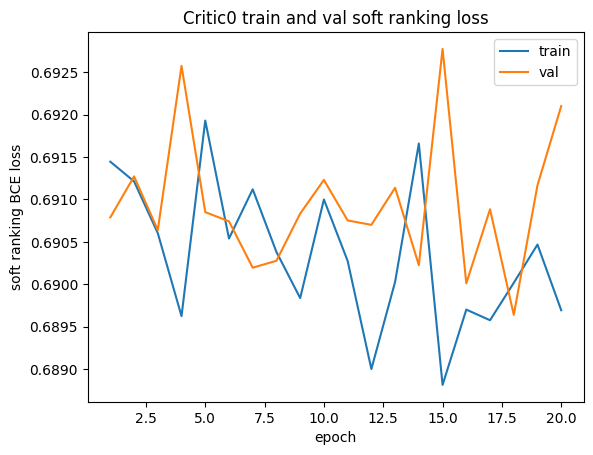

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# Settings
EPOCHS = 20
BATCH_STATES = 128
MOVES_PER_STATE = 16  # must match label generation

# Soft ranking parameters
TEMP = 1.0
GAP_SCALE = 1.0
TIE_EPS = 0.05

# Choose CPU tensors else fall back to Xt/At/Yt
Xt_src = Xt_cpu if "Xt_cpu" in globals() else Xt
At_src = At_cpu if "At_cpu" in globals() else At
Yt_src = Yt_cpu if "Yt_cpu" in globals() else Yt

Xv_src = Xv_cpu if "Xv_cpu" in globals() else Xv
Av_src = Av_cpu if "Av_cpu" in globals() else Av
Yv_src = Yv_cpu if "Yv_cpu" in globals() else Yv

# Infer counts
N = int(Xt_src.shape[0])
n_states = N // int(MOVES_PER_STATE)
assert n_states * int(MOVES_PER_STATE) == N, "Training set size must be multiple of MOVES_PER_STATE"

def _sample_pair_indices_cpu(n_states_total: int, batch_states: int):
    # Indices are always created on CPU to safely index CPU tensors
    sidx = torch.randint(0, int(n_states_total), (int(batch_states),), device="cpu")
    a1 = torch.randint(0, int(MOVES_PER_STATE), (int(batch_states),), device="cpu")
    a2 = torch.randint(0, int(MOVES_PER_STATE), (int(batch_states),), device="cpu")
    a2 = torch.where(a2 == a1, (a2 + 1) % int(MOVES_PER_STATE), a2)
    idx1 = sidx * int(MOVES_PER_STATE) + a1
    idx2 = sidx * int(MOVES_PER_STATE) + a2
    return idx1, idx2

    # Move idx to the same device as the tensor being indexed
def _index_rows(t: torch.Tensor, idx_cpu: torch.Tensor) -> torch.Tensor:
    if idx_cpu.device != t.device:
        idx = idx_cpu.to(t.device)
    else:
        idx = idx_cpu
    return t[idx]

def rank_step_soft(Xt_like, At_like, Yt_like):
    critic0.train()

    idx1_cpu, idx2_cpu = _sample_pair_indices_cpu(n_states, BATCH_STATES)

    # Index on the tensor's device, then move batches to DEVICE for compute
    x1 = _index_rows(Xt_like, idx1_cpu).to(DEVICE)
    a1t = _index_rows(At_like, idx1_cpu).to(DEVICE)
    y1 = _index_rows(Yt_like, idx1_cpu).to(DEVICE).view(-1)

    x2 = _index_rows(Xt_like, idx2_cpu).to(DEVICE)
    a2t = _index_rows(At_like, idx2_cpu).to(DEVICE)
    y2 = _index_rows(Yt_like, idx2_cpu).to(DEVICE).view(-1)

    p1 = critic0(x1, a1t).view(-1)
    p2 = critic0(x2, a2t).view(-1)

    dy = (y1 - y2)
    mask = (dy.abs() > float(TIE_EPS))
    if mask.sum().item() < 8:
        return 0.0

    dy = dy[mask]
    dp = (p1 - p2)[mask]

    # Soft target prob that action1 is better
    t = torch.sigmoid(dy / float(GAP_SCALE))

    pred = torch.sigmoid(dp / float(TEMP))
    loss = F.binary_cross_entropy(pred, t)

    opt.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(critic0.parameters(), 1.0)
    opt.step()

    return float(loss.item())

# rank thesoft loss
@torch.no_grad()
def rank_val_soft_loss(Xv_like, Av_like, Yv_like, n_batches=60):
    critic0.eval()

    Nv = int(Xv_like.shape[0])
    n_states_v = Nv // int(MOVES_PER_STATE)
    if n_states_v <= 0:
        return float("nan")

    # tally the losses
    losses = []
    for _ in range(int(n_batches)):
        idx1_cpu, idx2_cpu = _sample_pair_indices_cpu(n_states_v, BATCH_STATES)

        x1 = _index_rows(Xv_like, idx1_cpu).to(DEVICE)
        a1t = _index_rows(Av_like, idx1_cpu).to(DEVICE)
        y1 = _index_rows(Yv_like, idx1_cpu).to(DEVICE).view(-1)

        x2 = _index_rows(Xv_like, idx2_cpu).to(DEVICE)
        a2t = _index_rows(Av_like, idx2_cpu).to(DEVICE)
        y2 = _index_rows(Yv_like, idx2_cpu).to(DEVICE).view(-1)

        p1 = critic0(x1, a1t).view(-1)
        p2 = critic0(x2, a2t).view(-1)

        dy = (y1 - y2)
        mask = (dy.abs() > float(TIE_EPS))
        if mask.sum().item() < 8:
            continue

        dy = dy[mask]
        dp = (p1 - p2)[mask]

        t = torch.sigmoid(dy / float(GAP_SCALE))
        pred = torch.sigmoid(dp / float(TEMP))
        loss = F.binary_cross_entropy(pred, t)
        losses.append(float(loss.item()))

    return float(np.mean(losses)) if len(losses) else float("nan")

train_losses = []
val_losses = []

for ep in range(1, int(EPOCHS) + 1):
    steps = max(1, n_states // int(BATCH_STATES))

    total = 0.0
    for _ in range(int(steps)):
        total += rank_step_soft(Xt_src, At_src, Yt_src)

    avg_train = total / float(steps)
    avg_val = rank_val_soft_loss(Xv_src, Av_src, Yv_src, n_batches=60)

    train_losses.append(avg_train)
    val_losses.append(avg_val)

    print(f"epoch {ep} soft_rank_train={avg_train:.4f} soft_rank_val={avg_val:.4f}")

plt.figure()
plt.plot(range(1, int(EPOCHS) + 1), train_losses, label="train")
plt.plot(range(1, int(EPOCHS) + 1), val_losses, label="val")
plt.xlabel("epoch")
plt.ylabel("soft ranking BCE loss")
plt.title("Critic0 train and val soft ranking loss")
plt.legend()
plt.show()


### critic0 training interpreation

My critic0 training looks essentially flat, with both train and val soft ranking loss hovering around about 0.69 across epochs, which is close to a random baseline for pairwise comparisons, so the model is not learning a strong ordering signal from the labels. Given the setup, this likely means either the targets for different candidate actions within the same state are too noisy or too similar (lots of near ties after log1p), or the training objective is not aligned with the evaluation plot (the code trains with Huber regression on log1p(survival), while the plot shown is a ranking BCE style metric), so improvements in regression loss may not translate into better top 1 ranking. The architecture itself is reasonable for a state action critic, using a small conv residual stack to embed the 3 channel state and an MLP to embed the normalized action, but the current curve suggests the signal in the dataset is not separating actions enough for the critic to reliably prefer the better move, so the next step would be to strengthen the label generation or directly train with a pairwise ranking loss on within state action pairs.


VAL pairwise ranking accuracy (no ties): 0.6797312714159489
VAL mean score gap (better minus worse): 0.0808677600696683
VAL tie fraction (avg): 0.165087890625
VAL ranking accuracy by game stage:
early count= 0 acc=nan gap=nan
mid count= 229 acc= 0.684455011288325 gap= 0.08021198051671187
late count= 571 acc= 0.676687479019165 gap= 0.0791024590531985
end count= 0 acc=nan gap=nan


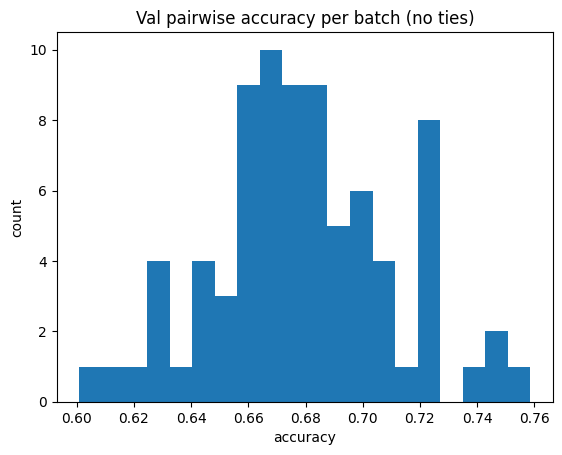

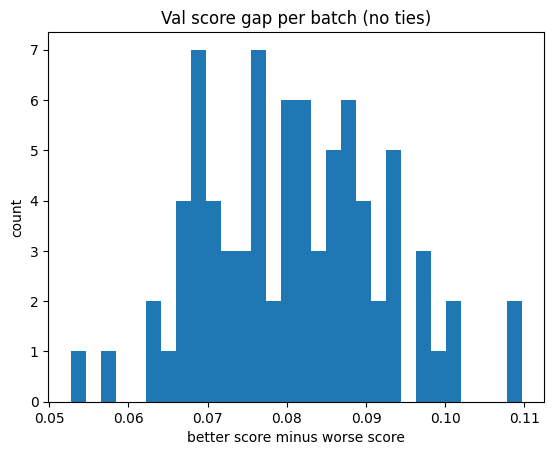

NameError: name 'env_factory' is not defined

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import random

critic0.eval()

MOVES_PER_STATE = 16  # must match dataset generation
BATCH_STATES = 256
N_VAL_BATCHES = 80
TIE_EPS = 0.05

# Choose CPU or GPU tensors depending on what exists
Xv_src = Xv_cpu if "Xv_cpu" in globals() else Xv
Av_src = Av_cpu if "Av_cpu" in globals() else Av
Yv_src = Yv_cpu if "Yv_cpu" in globals() else Yv



# get batch metrics pairwise
def _pairwise_batch_metrics(X, A, Y, n_states_total, n_batches=50):
    accs = []
    gaps = []
    tie_fracs = []

    for _ in range(int(n_batches)):
        idx1_cpu, idx2_cpu = _sample_pair_indices_cpu(int(n_states_total), int(BATCH_STATES))

        x1 = _index_rows(X, idx1_cpu).to(DEVICE)
        a1t = _index_rows(A, idx1_cpu).to(DEVICE)
        y1 = _index_rows(Y, idx1_cpu).to(DEVICE).view(-1)

        x2 = _index_rows(X, idx2_cpu).to(DEVICE)
        a2t = _index_rows(A, idx2_cpu).to(DEVICE)
        y2 = _index_rows(Y, idx2_cpu).to(DEVICE).view(-1)

        with torch.no_grad():
            p1 = critic0(x1, a1t).view(-1)
            p2 = critic0(x2, a2t).view(-1)

        dy = (y1 - y2)
        mask = (dy.abs() > float(TIE_EPS))
        tie_fracs.append(float(1.0 - mask.float().mean().item()))
        if mask.sum().item() < 8:
            continue

        y1m = y1[mask]
        y2m = y2[mask]
        p1m = p1[mask]
        p2m = p2[mask]

        better_is_1 = (y1m > y2m)
        pred_1_better = (p1m > p2m)
        accs.append(float((pred_1_better == better_is_1).float().mean().item()))

        p_better = torch.where(better_is_1, p1m, p2m)
        p_worse  = torch.where(better_is_1, p2m, p1m)
        gaps.append(float((p_better - p_worse).mean().item()))

    acc = float(np.mean(accs)) if len(accs) else float("nan")
    gap = float(np.mean(gaps)) if len(gaps) else float("nan")
    return acc, gap, accs, gaps, tie_fracs

def _stage_bins_from_states(X_states_chw_np):
    # X_states_chw_np: [S, 3, H, W], channel 0 is visible mask
    return X_states_chw_np[:, 0].mean(axis=(1, 2))

def _eval_val_ranking():
    Nv = int(Xv_src.shape[0])
    n_states_v = Nv // int(MOVES_PER_STATE)
    assert n_states_v * int(MOVES_PER_STATE) == Nv, "Val set size must be multiple of MOVES_PER_STATE"

    acc, gap, accs, gaps, tie_fracs = _pairwise_batch_metrics(
        Xv_src, Av_src, Yv_src, n_states_v, n_batches=int(N_VAL_BATCHES)
    )

    print("VAL pairwise ranking accuracy (no ties):", acc)
    print("VAL mean score gap (better minus worse):", gap)
    print("VAL tie fraction (avg):", float(np.mean(tie_fracs)))

    # Stage-binned evaluation (representative state = first sample per state block)
    Xv_np = Xv_src.detach().cpu().numpy()
    rep = Xv_np[::int(MOVES_PER_STATE)]
    revealed_frac = _stage_bins_from_states(rep)

    bins = [0.0, 0.10, 0.30, 0.60, 1.01]
    names = ["early", "mid", "late", "end"]

    print("VAL ranking accuracy by game stage:")
    for b0, b1, name in zip(bins[:-1], bins[1:], names):
        state_mask = (revealed_frac >= float(b0)) & (revealed_frac < float(b1))
        sidx_all = np.where(state_mask)[0]

        if len(sidx_all) < 50:
            print(name, "count=", int(len(sidx_all)), "acc=nan", "gap=nan")
            continue

        accs_stage = []
        gaps_stage = []

        for _ in range(30):
            # sample state ids on CPU
            sidx_cpu = torch.from_numpy(
                np.random.choice(sidx_all, size=int(BATCH_STATES), replace=True)
            ).long()

            a1_cpu = torch.randint(0, int(MOVES_PER_STATE), (int(BATCH_STATES),), device="cpu")
            a2_cpu = torch.randint(0, int(MOVES_PER_STATE), (int(BATCH_STATES),), device="cpu")
            a2_cpu = torch.where(a2_cpu == a1_cpu, (a2_cpu + 1) % int(MOVES_PER_STATE), a2_cpu)

            idx1_cpu = sidx_cpu * int(MOVES_PER_STATE) + a1_cpu
            idx2_cpu = sidx_cpu * int(MOVES_PER_STATE) + a2_cpu

            x1 = _index_rows(Xv_src, idx1_cpu).to(DEVICE)
            a1t = _index_rows(Av_src, idx1_cpu).to(DEVICE)
            y1 = _index_rows(Yv_src, idx1_cpu).to(DEVICE).view(-1)

            x2 = _index_rows(Xv_src, idx2_cpu).to(DEVICE)
            a2t = _index_rows(Av_src, idx2_cpu).to(DEVICE)
            y2 = _index_rows(Yv_src, idx2_cpu).to(DEVICE).view(-1)

            with torch.no_grad():
                p1 = critic0(x1, a1t).view(-1)
                p2 = critic0(x2, a2t).view(-1)

            dy = (y1 - y2)
            mask = (dy.abs() > float(TIE_EPS))
            if mask.sum().item() < 8:
                continue

            y1m, y2m = y1[mask], y2[mask]
            p1m, p2m = p1[mask], p2[mask]

            better_is_1 = (y1m > y2m)
            pred_1_better = (p1m > p2m)
            accs_stage.append(float((pred_1_better == better_is_1).float().mean().item()))

            p_better = torch.where(better_is_1, p1m, p2m)
            p_worse  = torch.where(better_is_1, p2m, p1m)
            gaps_stage.append(float((p_better - p_worse).mean().item()))

        print(
            name,
            "count=", int(len(sidx_all)),
            "acc=", float(np.mean(accs_stage)) if len(accs_stage) else float("nan"),
            "gap=", float(np.mean(gaps_stage)) if len(gaps_stage) else float("nan"),
        )

    # Histograms
    plt.figure()
    if len(accs) > 0:
        plt.hist(accs, bins=20)
    plt.title("Val pairwise accuracy per batch (no ties)")
    plt.xlabel("accuracy")
    plt.ylabel("count")
    plt.show()

    plt.figure()
    if len(gaps) > 0:
        plt.hist(gaps, bins=30)
    plt.title("Val score gap per batch (no ties)")
    plt.xlabel("better score minus worse score")
    plt.ylabel("count")
    plt.show()

# Fresh test helpers (robust env + safe unopened list)
def _compute_clues_from_mines(mines_bool: np.ndarray) -> np.ndarray:
    mines = mines_bool.astype(np.uint8)
    H, W = mines.shape
    clues = np.zeros((H, W), dtype=np.int8)
    for i in range(H):
        i0 = max(0, i - 1); i1 = min(H, i + 2)
        for j in range(W):
            j0 = max(0, j - 1); j1 = min(W, j + 2)
            s = int(mines[i0:i1, j0:j1].sum())
            clues[i, j] = -1 if mines[i, j] else int(s)
    return clues

# make an minesweeper env helper from output
def _make_env_from_factory_output(out):
    if hasattr(out, "open_cell") and hasattr(out, "visible") and hasattr(out, "flags"):
        return out
    if isinstance(out, (tuple, list)):
        for e in out:
            if hasattr(e, "open_cell") and hasattr(e, "visible") and hasattr(e, "flags"):
                return e
        if len(out) >= 2 and isinstance(out[0], np.ndarray) and isinstance(out[1], np.ndarray):
            mines, clues = out[0], out[1]
            env = MinesweeperEnv(mines=mines, clues=clues)
            if len(out) >= 3 and isinstance(out[2], np.ndarray):
                env.visible = out[2].astype(bool)
                env.num_opened = int(np.sum(env.visible))
            if len(out) >= 4 and isinstance(out[3], np.ndarray):
                env.flags = out[3].astype(bool)
            return env
    if isinstance(out, np.ndarray):
        mines = out.astype(bool)
        clues = _compute_clues_from_mines(mines)
        return MinesweeperEnv(mines=mines, clues=clues)
    raise TypeError(f"env_factory returned unsupported type: {type(out)}")

# check if game is over
def _env_done(env):
    if hasattr(env, "game_over") and bool(env.game_over):
        return True
    if hasattr(env, "all_safe_revealed") and bool(env.all_safe_revealed()):
        return True
    if hasattr(env, "done") and bool(env.done):
        return True
    return False

# list all the safe unopened cells
def _list_unopened_cells_safe(env):
    vis = env.visible
    flg = env.flags
    H, W = vis.shape
    coords = []
    for i in range(H):
        for j in range(W):
            if (not vis[i, j]) and (not flg[i, j]):
                coords.append((i, j))
    return coords

def _predict_one_score(state_chw, action_rc):
    x = torch.from_numpy(state_chw[None].astype(np.float32)).to(DEVICE)
    a = np.array(action_rc, dtype=np.int64)[None, :]

    # Use whichever exists
    if "_norm_action" in globals():
        a_norm = _norm_action(a, H=state_chw.shape[1], W=state_chw.shape[2])
    else:
        a_norm = norm_actions_rc(a, H=state_chw.shape[1], W=state_chw.shape[2])

    a_t = torch.from_numpy(a_norm.astype(np.float32)).to(DEVICE)
    with torch.no_grad():
        return float(critic0(x, a_t).item())

# samples fresh game states, tries a set of candidate moves
# and estimates true best move via multiple logic bot rollouts, compares it to the critic's predicted best move, and prints the top 1 agreement rate
def _fresh_test_ranking(env_factory, n_eval_states=200, k_candidates=12, n_rollouts=3, rollout_cap=ROLLOUT_CAP, eps_random=0.15):
    correct = 0
    total = 0
    used = 0

    for _ in range(int(n_eval_states)):
        env = _make_env_from_factory_output(env_factory())

        # warm up
        warm = random.randint(10, 60)
        for _t in range(int(warm)):
            if _env_done(env):
                break
            unopened = _list_unopened_cells_safe(env)
            if len(unopened) == 0:
                break
            i, j = random.choice(unopened)
            sr = open_cell(env, int(i), int(j))
            if sr.hit_mine or sr.done:
                break

        if _env_done(env):
            continue # if board completed then exit

        candidates = _list_unopened_cells_safe(env)
        if len(candidates) < 2: # earlty exit
            continue

        chosen = random.sample(candidates, k=min(int(k_candidates), len(candidates)))
        s = encode_state_from_env(env)

        true_vals = [] # keep track of predicted vs true
        pred_scores = []

        for (i, j) in chosen:
            tot = 0.0
            for _k in range(int(n_rollouts)):
                env2 = clone_env(env)
                sr = open_cell(env2, int(i), int(j))
                if sr.hit_mine or sr.done:
                    tot += 0.0
                else:
                    tot += 1.0 + float(
                        logic_bot_rollout_survival(env2, step_cap=int(rollout_cap) - 1, eps_random=float(eps_random))
                    )
            true_vals.append(float(tot / float(max(1, int(n_rollouts)))))
            pred_scores.append(float(_predict_one_score(s, (int(i), int(j)))))

        used += 1
        if int(np.argmax(true_vals)) == int(np.argmax(pred_scores)):
            correct += 1
        total += 1

    acc = float(correct) / float(max(1, total))
    print("Fresh test top-1 agreement:", acc, "on", int(total), "usable states (out of", int(n_eval_states), ")")

# Run both
_eval_val_ranking()
_fresh_test_ranking(env_factory, n_eval_states=200, k_candidates=12, n_rollouts=3, rollout_cap=ROLLOUT_CAP, eps_random=0.15)


In this evaluation cell, I measured how well my trained critic0 ranks actions by sampling pairs of candidate moves from the same underlying game state and checking whether the critic assigns a higher score to the move that truly leads to higher rollout survival, ignoring near ties using a small epsilon threshold. On the validation set, I get about 0.68 pairwise ranking accuracy with a mean score gap of about 0.08 between better and worse actions, and the histograms show this performance is fairly consistent across random batches rather than coming from a few lucky samples. When I bin by game stage using the fraction of visible cells, the critic performs similarly in mid and late states where I have enough examples, while early and end bins are empty because my validation data rarely contains very early or fully solved boards

### actor critic stuff

In [ ]:
from pathlib import Path
import os
from google.colab import drive

# Mount Drive (only if not already mounted)
if not os.path.isdir("/content/drive/MyDrive"):
    drive.mount("/content/drive")

ROOT = Path("/content/drive/MyDrive/minesweeper_task2_bootstrap")
ROOT.mkdir(parents=True, exist_ok=True)

DATA_DIR = ROOT / "data"
CKPT_DIR = ROOT / "checkpoints"
METRICS_DIR = ROOT / "metrics"

DATA_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

# confirm saving to the right place
print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
print("CKPT_DIR:", CKPT_DIR)
print("METRICS_DIR:", METRICS_DIR)

ROOT: /content/drive/MyDrive/minesweeper_task2_bootstrap
DATA_DIR: /content/drive/MyDrive/minesweeper_task2_bootstrap/data
CKPT_DIR: /content/drive/MyDrive/minesweeper_task2_bootstrap/checkpoints
METRICS_DIR: /content/drive/MyDrive/minesweeper_task2_bootstrap/metrics


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Use existing DEVICE if defined, otherwise pick a default
DEVICE = DEVICE if "DEVICE" in globals() else torch.device("cuda" if torch.cuda.is_available() else "cpu")

def _norm_action(a_rc: np.ndarray, H: int = 22, W: int = 22) -> np.ndarray:
    """
    Convert integer (row, col) actions into normalized coordinates in [-1, 1].
    a_rc shape: (N, 2)
    returns: (N, 2) float32
    """
    a_rc = np.asarray(a_rc)
    if a_rc.ndim != 2 or a_rc.shape[1] != 2:
        raise ValueError("a_rc must have shape (N, 2)")

    r = a_rc[:, 0].astype(np.float32)
    c = a_rc[:, 1].astype(np.float32)

    # Map [0, H-1] -> [-1, 1]
    r = (2.0 * (r / float(H - 1))) - 1.0
    c = (2.0 * (c / float(W - 1))) - 1.0

    return np.stack([r, c], axis=1).astype(np.float32)

# Pre-activation residual block with GroupNorm + SiLU
class ResBlock(nn.Module):
    """
    More stable than plain conv+ReLU for this noisy RL-ish regression/ranking signal
    """
    def __init__(self, ch: int, groups: int = 8):
        super().__init__()
        g = int(min(int(groups), int(ch)))
        if g < 1:
            g = 1
        while g > 1 and (int(ch) % g) != 0:
            g -= 1

        self.gn1 = nn.GroupNorm(g, ch)
        self.gn2 = nn.GroupNorm(g, ch)
        self.c1 = nn.Conv2d(ch, ch, 3, padding=1)
        self.c2 = nn.Conv2d(ch, ch, 3, padding=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        y = self.c1(F.silu(self.gn1(x)))
        y = self.c2(F.silu(self.gn2(y)))
        return x + y

# State-action critic that predicts log1p(survival moves from this decision)
class CriticSA_V2(nn.Module):
    """
    Inputs:
      x: (B, 3, H, W) float32
      a_rc_norm: (B, 2) float32 in [-1, 1]
    Output:
      pred_log: (B,) float32
    """
    def __init__(self, in_ch: int = 3, hidden: int = 96, n_blocks: int = 4, groups: int = 8, dropout: float = 0.0):
        super().__init__()

        # State encoder
        self.stem = nn.Sequential(
            nn.Conv2d(int(in_ch), int(hidden), 3, padding=1),
            nn.SiLU(),
            nn.Conv2d(int(hidden), int(hidden), 3, padding=1),
            nn.SiLU(),
        )
        self.blocks = nn.Sequential(*[ResBlock(int(hidden), groups=int(groups)) for _ in range(int(n_blocks))])
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        # Action encoder (match hidden width so action is not a bottleneck)
        self.action_mlp = nn.Sequential(
            nn.Linear(2, int(hidden)),
            nn.SiLU(),
            nn.Linear(int(hidden), int(hidden)),
            nn.SiLU(),
        )

        self.drop = nn.Dropout(float(dropout)) if float(dropout) > 0.0 else nn.Identity()

        # Head
        self.head = nn.Sequential(
            nn.Linear(int(hidden) + int(hidden), int(hidden)),
            nn.SiLU(),
            nn.Linear(int(hidden), 1),
        )

    def forward(self, x: torch.Tensor, a_rc_norm: torch.Tensor) -> torch.Tensor:
        z = self.stem(x)
        z = self.blocks(z)
        z = self.pool(z).squeeze(-1).squeeze(-1)  # (B, hidden)

        a = self.action_mlp(a_rc_norm)            # (B, hidden)
        h = torch.cat([z, a], dim=1)
        h = self.drop(h)
        return self.head(h).squeeze(1)            # (B,)


### why 2 actor criticSA
I started with a baseline state-action critic (plain residual conv blocks) and later upgraded to a more stable critic using GroupNorm pre-activation residual blocks. The newer critic reduced training instability on noisy bootstrapped targets, so it is the final model used for all reported Task 2 results.

## Generate actor rollout dataset for one iteration and save to Drive

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import random

critic0.eval()

MOVES_PER_STATE = 16
BATCH_STATES = 256
N_VAL_BATCHES = 80
TIE_EPS = 0.05

# Choose CPU or GPU tensors depending on what exists
Xv_src = Xv_cpu if "Xv_cpu" in globals() else Xv
Av_src = Av_cpu if "Av_cpu" in globals() else Av
Yv_src = Yv_cpu if "Yv_cpu" in globals() else Yv

def _tensor_device(t):
    return t.device if torch.is_tensor(t) else torch.device("cpu")

def _sample_pair_indices(n_states_total, batch_states, device):
    sidx = torch.randint(0, int(n_states_total), (int(batch_states),), device=device)
    a1 = torch.randint(0, int(MOVES_PER_STATE), (int(batch_states),), device=device)
    a2 = torch.randint(0, int(MOVES_PER_STATE), (int(batch_states),), device=device)
    a2 = torch.where(a2 == a1, (a2 + 1) % int(MOVES_PER_STATE), a2)
    idx1 = sidx * int(MOVES_PER_STATE) + a1
    idx2 = sidx * int(MOVES_PER_STATE) + a2
    return idx1, idx2

# Fresh test helpers (robust env handling)
def _to_np(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def _as_2d(x):
    """
    Coerce common shapes to 2D:
      (H,W)
      (1,H,W) -> (H,W)
      (H,W,1) -> (H,W)
    """
    a = _to_np(x)
    a = np.squeeze(a)
    if a.ndim == 2:
        return a
    if a.ndim == 3:
        if a.shape[0] == 1:
            return a[0]
        if a.shape[-1] == 1:
            return a[..., 0]
    raise TypeError(f"expected 2D grid, got shape {a.shape}")

def _looks_boolish(a):
    a = np.asarray(a)
    if a.dtype == np.bool_:
        return True
    if np.issubdtype(a.dtype, np.integer):
        u = np.unique(a)
        return u.size <= 2 and set(u.tolist()).issubset({0, 1})
    return False

def _unwrap_env(maybe_env):
    # Already env-like
    if hasattr(maybe_env, "visible") and hasattr(maybe_env, "flags") and hasattr(maybe_env, "clues"):
        # Still coerce to 2D if needed
        maybe_env.visible = _as_2d(maybe_env.visible).astype(np.bool_)
        maybe_env.flags = _as_2d(maybe_env.flags).astype(np.bool_)
        maybe_env.clues = _as_2d(maybe_env.clues)
        if hasattr(maybe_env, "mines"):
            try:
                maybe_env.mines = _as_2d(maybe_env.mines).astype(np.bool_)
            except Exception:
                pass
        if not hasattr(maybe_env, "H") or not hasattr(maybe_env, "W"):
            maybe_env.H = int(maybe_env.visible.shape[0])
            maybe_env.W = int(maybe_env.visible.shape[1])
        return maybe_env

    # Dict-like return
    if isinstance(maybe_env, dict):
        d = maybe_env
        if all(k in d for k in ["visible", "flags", "clues"]):
            visible = _as_2d(d["visible"]).astype(np.bool_)
            flags = _as_2d(d["flags"]).astype(np.bool_)
            clues = _as_2d(d["clues"])
            mines = d.get("mines", None)
            mines = _as_2d(mines).astype(np.bool_) if mines is not None else np.zeros_like(visible, dtype=np.bool_)

            class _EnvAdapter:
                pass

            env = _EnvAdapter()
            env.mines = mines
            env.clues = clues
            env.visible = visible
            env.flags = flags
            env.H = int(visible.shape[0])
            env.W = int(visible.shape[1])
            env.num_opened = int(env.visible.astype(np.int32).sum())
            env.game_over = False

            def _all_safe_revealed():
                safe = (~env.mines).astype(np.bool_)
                return bool(np.all(env.visible[safe]))

            env.all_safe_revealed = _all_safe_revealed
            return env

    # Tuple/list wrappers
    if isinstance(maybe_env, (tuple, list)) and len(maybe_env) > 0:
        # If any element is env-like, use it
        for e in maybe_env:
            if hasattr(e, "visible") and hasattr(e, "flags") and hasattr(e, "clues"):
                return _unwrap_env(e)

        # Otherwise: interpret as bag-of-grids (order may vary)
        mats = []
        for e in maybe_env:
            try:
                mats.append(_as_2d(e))
            except Exception:
                pass

        if len(mats) < 3:
            raise TypeError("env_factory returned tuple/list but could not extract 3 grids")

        boolish = [m for m in mats if _looks_boolish(m)]
        non_boolish = [m for m in mats if not _looks_boolish(m)]

        # clues typically non-bool-ish
        clues = non_boolish[0] if len(non_boolish) > 0 else mats[0]

        # visible + flags from boolish, else fallback to conventional indices
        if len(boolish) >= 2:
            visible = boolish[0].astype(np.bool_)
            flags = boolish[1].astype(np.bool_)
            mines = boolish[2].astype(np.bool_) if len(boolish) >= 3 else np.zeros_like(visible, dtype=np.bool_)
        else:
            clues = mats[1] if mats[0].ndim != 2 else mats[0]
            visible = mats[2].astype(np.bool_) if len(mats) > 2 else mats[1].astype(np.bool_)
            flags = mats[3].astype(np.bool_) if len(mats) > 3 else np.zeros_like(visible, dtype=np.bool_)
            mines = np.zeros_like(visible, dtype=np.bool_)

        if visible.shape != flags.shape:
            raise TypeError(f"visible and flags shapes differ: {visible.shape} vs {flags.shape}")
        if clues.shape != visible.shape:
            raise TypeError(f"clues shape differs from visible: {clues.shape} vs {visible.shape}")

        def _all_safe_revealed():
            safe = (~env.mines).astype(np.bool_)
            return bool(np.all(env.visible[safe]))

        env.all_safe_revealed = _all_safe_revealed
        return env

    raise TypeError(f"env_factory returned unsupported type: {type(maybe_env)}")



In [ ]:
# load the dataset from google
from pathlib import Path
import numpy as np

ITER = 0
rollout_path = DATA_DIR / f"actor_rollout_iter_{ITER:02d}.npz"

data = np.load(rollout_path, allow_pickle=False)
Xr = data["X"].astype(np.float32)
Ar = data["A"].astype(np.int64)
Yr = data["Y"].astype(np.float32)
data.close()

print("Loaded data:", rollout_path)
print("Xr:", Xr.shape, "Ar:", Ar.shape, "Yr:", Yr.shape)
print("Y stats:", float(Yr.min()) if Yr.size else None, float(Yr.mean()) if Yr.size else None, float(Yr.max()) if Yr.size else None)


Loaded data: /content/drive/MyDrive/minesweeper_task2_bootstrap/data/actor_rollout_iter_00.npz
Xr: (1240, 3, 22, 22) Ar: (1240, 2) Yr: (1240,)
Y stats: 1.0 3.0096774101257324 13.0


### train critic on actor rollouts and save checkpoints

/tmp/ipython-input-244462145.py:242: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipython-input-244462145.py:259: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipython-input-244462145.py:282: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


epoch 1 train_loss 0.6401 val_loss 0.6086
epoch 2 train_loss 0.6155 val_loss 0.6159
epoch 3 train_loss 0.6143 val_loss 0.6177
epoch 4 train_loss 0.6151 val_loss 0.604
epoch 5 train_loss 0.6137 val_loss 0.6077
epoch 6 train_loss 0.6135 val_loss 0.6078
epoch 7 train_loss 0.6132 val_loss 0.6055
epoch 8 train_loss 0.6126 val_loss 0.6054
epoch 9 train_loss 0.6122 val_loss 0.6099
epoch 10 train_loss 0.612 val_loss 0.6035
epoch 11 train_loss 0.612 val_loss 0.6066
epoch 12 train_loss 0.6116 val_loss 0.6077
epoch 13 train_loss 0.6115 val_loss 0.6071
epoch 14 train_loss 0.611 val_loss 0.6043
epoch 15 train_loss 0.6106 val_loss 0.605


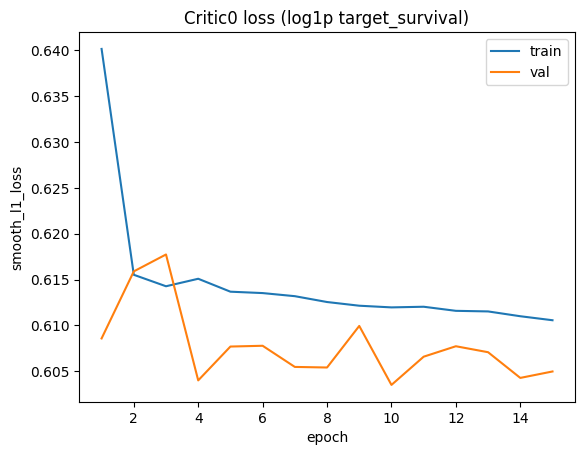

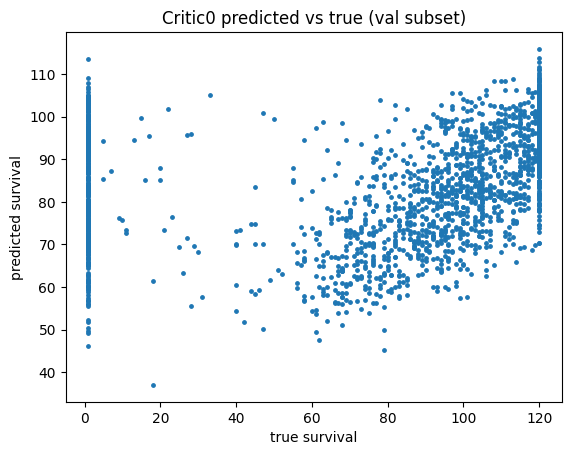

Saved critic0 to Drive: /content/drive/MyDrive/minesweeper_ckpts/critic_iter_00.pt
Copied critic0 to local CKPT_DIR: /content/drive/MyDrive/minesweeper_task2_bootstrap/checkpoints/critic_iter_00.pt


In [ ]:
# (1) Google Drive mount + paths
from pathlib import Path
import shutil, os, glob
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

from google.colab import drive

# Mount Drive + basic paths
if not os.path.isdir("/content/drive/MyDrive"):
    drive.mount("/content/drive")

if torch.cuda.is_available():
    torch.cuda.empty_cache()

DRIVE_CKPT_DIR = Path("/content/drive/MyDrive/minesweeper_ckpts")
DRIVE_CKPT_DIR.mkdir(parents=True, exist_ok=True)

CKPT_DIR = Path(CKPT_DIR) if "CKPT_DIR" in globals() else Path("/content/ckpts")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR = Path(DATA_DIR) if "DATA_DIR" in globals() else Path("/content/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = DEVICE if "DEVICE" in globals() else torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Robust label/array loader
def _maybe_load_npz_xyz(path: Path):
    try:
        d = np.load(str(path), allow_pickle=True)
    except Exception:
        return None

    keys = set(d.files)
    # Support a few common naming conventions
    for Xk, Ak, Yk in [
        ("X", "A", "Y"),
        ("states", "actions", "targets"),
        ("X_t", "A_t", "Y_t"),
    ]:
        if Xk in keys and Ak in keys and Yk in keys:
            X = d[Xk]
            A = d[Ak]
            Y = d[Yk]
            return X, A, Y

    return None

def _load_labels_or_arrays(prefer_iter=0):
    """
    Returns either:
      - ("labels", labels_list)
      - ("arrays", (X, A, Y)) where:
          X: [N, C, H, W] float32
          A: [N, 2] int64 (row,col)
          Y: [N] float32 (survival)

    Tries to do the following:
      1) globals(): labels, or (X,A,Y)
      2) torch-saved labels_iter_XX.(pt|pth|pkl)
      3) any .npz under common dirs that contains X/A/Y
    """
    # 1) labels in memory
    if "labels" in globals():
        lab = globals()["labels"]
        if lab is not None and isinstance(lab, (list, tuple)) and len(lab) > 0:
            return "labels", list(lab)

    # 1b) arrays in memory
    if all(k in globals() for k in ["X", "A", "Y"]):
        X, A, Y = globals()["X"], globals()["A"], globals()["Y"]
        if X is not None and A is not None and Y is not None:
            return "arrays", (np.asarray(X), np.asarray(A), np.asarray(Y))

    # 2) saved torch/pickle labels, struggled with google drive saving
    candidates = []
    search_dirs = [CKPT_DIR, DRIVE_CKPT_DIR, DATA_DIR, Path("/content")]
    patterns = [
        f"labels_iter_{int(prefer_iter):02d}.pt",
        f"labels_iter_{int(prefer_iter):02d}.pth",
        f"labels_iter_{int(prefer_iter):02d}.pkl",
        "labels_iter_*.pt",
        "labels_iter_*.pth",
        "labels_iter_*.pkl",
        "*labels*.pt",
        "*labels*.pth",
        "*labels*.pkl",
    ]
    for d in search_dirs:
        for pat in patterns:
            candidates += [Path(p) for p in glob.glob(str(d / pat))]

    def _score(p: Path):
        name = p.name
        exact = (f"labels_iter_{int(prefer_iter):02d}" in name)
        mtime = p.stat().st_mtime if p.exists() else 0.0
        return (1 if exact else 0, mtime)

    candidates = sorted(list({c.resolve() for c in candidates if c.exists()}), key=_score, reverse=True)

    if len(candidates) > 0:
        path = candidates[0]
        print("Loading labels from:", path)
        try:
            obj = torch.load(path, map_location="cpu")
        except Exception:
            import pickle
            with open(path, "rb") as f:
                obj = pickle.load(f)

        # dict wrapper support
        if isinstance(obj, dict):
            for k in ["labels", "data", "payload"]:
                if k in obj and isinstance(obj[k], (list, tuple)) and len(obj[k]) > 0:
                    obj = obj[k]
                    break

        if isinstance(obj, (list, tuple)) and len(obj) > 0:
            globals()["labels"] = list(obj)
            return "labels", globals()["labels"]

    # 3) look for an NPZ with X/A/Y
    npz_candidates = []
    npz_patterns = ["*.npz", "*labels*.npz", "*task2*.npz", "*critic*.npz", "*boot*.npz"]
    for d in search_dirs:
        for pat in npz_patterns:
            npz_candidates += [Path(p) for p in glob.glob(str(d / pat))]

    # newest first
    npz_candidates = sorted(list({p.resolve() for p in npz_candidates if p.exists()}),
                            key=lambda p: p.stat().st_mtime,
                            reverse=True)

    for p in npz_candidates:
        xyz = _maybe_load_npz_xyz(p)
        if xyz is not None:
            X, A, Y = xyz
            print("Loading X/A/Y arrays from npz:", p)
            globals()["X"] = np.asarray(X)
            globals()["A"] = np.asarray(A)
            globals()["Y"] = np.asarray(Y)
            return "arrays", (globals()["X"], globals()["A"], globals()["Y"])

    raise NameError(
        "Could not find labels or X/A/Y arrays\n"
        "Fix: run the label-generation cell first, OR save labels with torch.save({'labels': labels}),\n"
        "OR ensure there is an .npz that contains arrays named (X,A,Y) (or states/actions/targets)"
    )

# Helpers
def labels_to_arrays(labels):
    X = np.stack([x.state for x in labels], axis=0).astype(np.float32)
    A = np.array([x.action_rc for x in labels], dtype=np.int64)
    Y = np.array([x.target_survival for x in labels], dtype=np.float32)
    return X, A, Y
# coerce the arrays
def _coerce_arrays(X, A, Y):
    X = np.asarray(X).astype(np.float32)
    A = np.asarray(A).astype(np.int64)
    Y = np.asarray(Y).astype(np.float32).reshape(-1)

    if X.ndim != 4:
        raise ValueError(f"X must be [N,C,H,W], got shape {X.shape}")
    if A.ndim != 2 or A.shape[1] != 2:
        raise ValueError(f"A must be [N,2], got shape {A.shape}")
    if X.shape[0] != A.shape[0] or X.shape[0] != Y.shape[0]:
        raise ValueError(f"N mismatch: X {X.shape[0]} A {A.shape[0]} Y {Y.shape[0]}")
    return X, A, Y

# Train critic on labels OR arrays
def train_critic_on_labels_or_arrays(
    source,
    epochs=20,
    batch=64,
    lr=3e-4,
    val_frac=0.2,
    make_plots=True,
    num_workers=0
):
    """
    Critic0 training on survivability targets
    Learns log1p(target_survival)
    Keeps dataset on CPU and move only mini-batches to GPU
    """
    kind, payload = source
    if kind == "labels":
        X, A, Y = labels_to_arrays(payload)
    elif kind == "arrays":
        X, A, Y = payload
    else:
        raise ValueError(f"Unknown source kind: {kind}")

    X, A, Y = _coerce_arrays(X, A, Y)

    in_ch = int(X.shape[1])
    A_norm = _norm_action(A, H=X.shape[2], W=X.shape[3])
    Y_log = np.log1p(Y.astype(np.float32))

    N = int(X.shape[0])
    idx = np.arange(N)
    np.random.shuffle(idx)
    split = int((1.0 - float(val_frac)) * N)
    tr = idx[:split]
    va = idx[split:]

    Xt = torch.from_numpy(X[tr]).float()
    At = torch.from_numpy(A_norm[tr]).float()
    Yt = torch.from_numpy(Y_log[tr]).float()

    Xv = torch.from_numpy(X[va]).float()
    Av = torch.from_numpy(A_norm[va]).float()
    Yv = torch.from_numpy(Y_log[va]).float()

    # load the training data
    train_loader = DataLoader(
        TensorDataset(Xt, At, Yt),
        batch_size=int(batch),
        shuffle=True,
        num_workers=int(num_workers),
        pin_memory=torch.cuda.is_available(),
        drop_last=False
    )

    # load the validation data
    val_loader = DataLoader(
        TensorDataset(Xv, Av, Yv),
        batch_size=int(batch),
        shuffle=False,
        num_workers=int(num_workers),
        pin_memory=torch.cuda.is_available(),
        drop_last=False
    )

    # use the new critic
    critic = CriticSA_V2(in_ch=in_ch, hidden=96).to(DEVICE)
    opt = torch.optim.Adam(critic.parameters(), lr=float(lr))

    use_amp = torch.cuda.is_available()
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    # collect train and val losses
    train_losses, val_losses = [], []

    # run the epochs
    for ep in range(1, int(epochs) + 1):
        critic.train()
        total, nb = 0.0, 0

        for xb, ab, yb in train_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            ab = ab.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            opt.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=use_amp):
                pred = critic(xb, ab)
                loss = F.smooth_l1_loss(pred.view(-1), yb.view(-1))

            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(critic.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()

            total += float(loss.item())
            nb += 1

        avg_train = total / max(1, nb)

        critic.eval()
        vtotal, vnb = 0.0, 0
        with torch.no_grad():
            for xb, ab, yb in val_loader:
                xb = xb.to(DEVICE, non_blocking=True)
                ab = ab.to(DEVICE, non_blocking=True)
                yb = yb.to(DEVICE, non_blocking=True)

                with torch.cuda.amp.autocast(enabled=use_amp):
                    pv = critic(xb, ab)
                    vloss = F.smooth_l1_loss(pv.view(-1), yb.view(-1))

                vtotal += float(vloss.item())
                vnb += 1

        avg_val = vtotal / max(1, vnb)

        train_losses.append(avg_train)
        val_losses.append(avg_val)

        print("epoch", ep, "train_loss", round(avg_train, 4), "val_loss", round(avg_val, 4))

    if make_plots:
        plt.figure()
        plt.plot(range(1, len(train_losses) + 1), train_losses, label="train")
        plt.plot(range(1, len(val_losses) + 1), val_losses, label="val")
        plt.xlabel("epoch")
        plt.ylabel("smooth_l1_loss")
        plt.title("Critic0 loss (log1p target_survival)")
        plt.legend()
        plt.show()

        critic.eval()
        with torch.no_grad():
            n_plot = min(2048, Xv.shape[0])
            sel = torch.randperm(Xv.shape[0])[:n_plot]
            xb = Xv[sel].to(DEVICE)
            ab = Av[sel].to(DEVICE)
            y_true_log = Yv[sel].cpu().numpy()
            pred_log = critic(xb, ab).detach().float().view(-1).cpu().numpy()

        pred_moves = np.expm1(np.clip(pred_log, -20.0, 20.0))
        true_moves = np.expm1(np.clip(y_true_log, -20.0, 20.0))

        plt.figure()
        plt.scatter(true_moves, pred_moves, s=6)
        plt.xlabel("true survival")
        plt.ylabel("predicted survival")
        plt.title("Critic0 predicted vs true (val subset)")
        plt.show()

    # expose val tensors for later ranking cell
    globals()["Xv"] = Xv
    globals()["Av"] = Av
    globals()["Yv"] = Yv

    return critic, train_losses, val_losses

# Run + save
ITER = 0
critic_path_local = CKPT_DIR / f"critic_iter_{ITER:02d}.pt"
critic_path_drive = DRIVE_CKPT_DIR / f"critic_iter_{ITER:02d}.pt"

source = _load_labels_or_arrays(prefer_iter=ITER)

critic0, tr_loss, va_loss = train_critic_on_labels_or_arrays(
    source,
    epochs=15,
    batch=64,
    lr=3e-4,
    val_frac=0.2,
    make_plots=True
)

torch.save({"state_dict": critic0.state_dict()}, critic_path_drive)
print("Saved critic0 to Drive:", critic_path_drive)

if critic_path_drive.resolve() != critic_path_local.resolve():
    shutil.copy2(critic_path_drive, critic_path_local)
    print("Copied critic0 to local CKPT_DIR:", critic_path_local)
else:
    print("Skip copy: CKPT_DIR already points to Drive:", critic_path_local)


The training and validation loss both decrease and stay close over epochs, which tells me the critic is learning a stable mapping without obvious overfitting. The predicted versus true survival scatter shows a clear positive trend, meaning the critic generally assigns higher values to actions that truly lead to longer survival, even though there is noticeable spread and compression at higher survival values. This indicates the model is not perfectly calibrated in absolute terms, but it has learned the correct ordering and rough scale of action quality, which is exactly what I want from the critic at this stage of Task 2.


In [ ]:
# load the critic checkpoint
import torch

ITER = 0
critic_path = CKPT_DIR / f"critic_iter_{ITER:02d}.pt"

critic0 = CriticSA_V2(in_ch=3, hidden=96).to(DEVICE)
ckpt = torch.load(critic_path, map_location=DEVICE)
critic0.load_state_dict(ckpt["state_dict"])
critic0.eval()

print("Loaded critic:", critic_path)

Loaded critic: /content/drive/MyDrive/minesweeper_task2_bootstrap/checkpoints/critic_iter_00.pt


### update actor using critic scores and save the actor

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Actor distillation upgrades + stable env_factory + robust unwrap
# This cell trains an actor policy by distilling a critic's action preferences.
# The actor outputs a logit score per grid cell, and we train it to match a soft
# probability distribution over a sampled set of candidate actions.

# Actor output helpers

# Get actor logits as a (B,H,W) grid.
# Some actor models return (B,1,H,W), so we squeeze the channel dimension.
def _actor_logits_grid(actor, x):
    out = actor(x)
    # If output is (B,1,H,W), drop the singleton channel.
    if out.dim() == 4 and out.shape[1] == 1:
        out = out[:, 0]
    return out

# Convert tensors or array-like objects to numpy arrays.
def _to_np(x):
    if x is None:
        return None
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)

# Force input into a 2D grid (H,W).
# Accepts (H,W), (1,H,W), or (H,W,1).
def _as_2d(x):
    a = _to_np(x)
    if a is None:
        raise TypeError("got None, expected 2D grid")
    a = np.squeeze(a)
    if a.ndim == 2:
        return a
    if a.ndim == 3:
        # allow (1,H,W)
        if a.shape[0] == 1:
            return a[0]
        # allow (H,W,1)
        if a.shape[-1] == 1:
            return a[..., 0]
    raise TypeError(f"expected 2D grid, got shape {a.shape}")

# Heuristic: determine whether a grid looks like a boolean mask.
# This is used when env_factory returns raw arrays and we need to guess
# which arrays correspond to visible, flags, and mines.
def _looks_boolish(a):
    a = np.asarray(a)
    if a.dtype == np.bool_:
        return True
    if np.issubdtype(a.dtype, np.integer):
        u = np.unique(a)
        return u.size <= 2 and set(u.tolist()).issubset({0, 1})
    if np.issubdtype(a.dtype, np.floating):
        u = np.unique(a.astype(np.float32))
        if u.size <= 3:
            return set(np.round(u, 4).tolist()).issubset({0.0, 1.0})
    return False

# Env adaptation and unwrapping

# Wrap raw visible/flags/clues arrays into an object with the expected attributes.
# This lets the rest of the pipeline behave as if it received a MinesweeperEnv.
def _make_env_adapter(visible, flags, clues, mines=None):
    # Normalize inputs to consistent (H,W) numpy arrays.
    visible = _as_2d(visible).astype(np.bool_)
    flags   = _as_2d(flags).astype(np.bool_)
    clues   = _as_2d(clues)

    # Sanity checks for shape alignment.
    if visible.shape != flags.shape:
        raise TypeError(f"visible and flags shapes differ: {visible.shape} vs {flags.shape}")
    if clues.shape != visible.shape:
        raise TypeError(f"clues shape differs from visible: {clues.shape} vs {visible.shape}")

    # Mines may be missing. If so, create a dummy all-false mines grid.
    if mines is None:
        mines = np.zeros_like(visible, dtype=np.bool_)
    else:
        mines = _as_2d(mines).astype(np.bool_)

    # Minimal object with the fields used by encode_state_from_env and open_cell.
    class _EnvAdapter:
        pass

    env = _EnvAdapter()
    env.visible = visible
    env.flags = flags
    env.clues = clues
    env.mines = mines

    # Dimensions are commonly expected by downstream code.
    env.H = int(visible.shape[0])
    env.W = int(visible.shape[1])

    # Best-effort counters/flags.
    env.num_opened = int(env.visible.astype(np.int32).sum())
    env.game_over = False

    return env

# Convert env_factory outputs into an env-like object with .visible/.flags/.clues.
# Handles:
# 1 MinesweeperEnv or env-like object
# 2 dict with keys visible/flags/clues
# 3 tuple/list containing an env or raw grids
def _unwrap_env_for_actor(maybe_env, debug=False):
    # Case 1: env-like object already.
    if hasattr(maybe_env, "visible") and hasattr(maybe_env, "flags") and hasattr(maybe_env, "clues"):
        # Normalize fields to consistent types and shapes.
        maybe_env.visible = _as_2d(maybe_env.visible).astype(np.bool_)
        maybe_env.flags   = _as_2d(maybe_env.flags).astype(np.bool_)
        maybe_env.clues   = _as_2d(maybe_env.clues)

        # Mines is optional, so attempt conversion but do not hard-fail.
        if hasattr(maybe_env, "mines"):
            try:
                maybe_env.mines = _as_2d(maybe_env.mines).astype(np.bool_)
            except Exception:
                pass

        # Ensure H/W exist.
        if not hasattr(maybe_env, "H") or not hasattr(maybe_env, "W"):
            maybe_env.H = int(maybe_env.visible.shape[0])
            maybe_env.W = int(maybe_env.visible.shape[1])

        # Ensure game_over exists.
        if not hasattr(maybe_env, "game_over"):
            maybe_env.game_over = False

        # Some code calls env.all_safe_revealed(), so provide a stub if missing.
        if not hasattr(maybe_env, "all_safe_revealed"):
            def _all_safe_revealed():
                return False
            maybe_env.all_safe_revealed = _all_safe_revealed

        return maybe_env

    # Case 2: dict-like payload.
    if isinstance(maybe_env, dict) and all(k in maybe_env for k in ["visible", "flags", "clues"]):
        return _make_env_adapter(
            visible=maybe_env["visible"],
            flags=maybe_env["flags"],
            clues=maybe_env["clues"],
            mines=maybe_env.get("mines", None),
        )

    # Case 3/4: tuple/list outputs.
    if isinstance(maybe_env, (tuple, list)):
        if len(maybe_env) == 0:
            raise TypeError("env_factory returned empty tuple/list")

        # If any element is env-like, unwrap that element.
        for e in maybe_env:
            if hasattr(e, "visible") and hasattr(e, "flags") and hasattr(e, "clues"):
                return _unwrap_env_for_actor(e, debug=debug)

        # Otherwise, try to interpret tuple elements as 2D grids.
        mats = []
        for e in maybe_env:
            try:
                mats.append(_as_2d(e))
            except Exception:
                pass

        if len(mats) < 3:
            if debug:
                print("DEBUG unwrap failed: tuple/list did not yield >=3 grids")
                print("tuple len:", len(maybe_env), "elem types:", [type(x) for x in maybe_env])
            raise TypeError("tuple/list env output did not contain enough 2D grids")

        # Partition grids by whether they look boolean-like.
        boolish = [m for m in mats if _looks_boolish(m)]
        nonb = [m for m in mats if not _looks_boolish(m)]

        # Clues are typically non-boolish (values 0..8), so prefer that.
        clues = nonb[0] if len(nonb) > 0 else mats[0]

        # Choose visible/flags/mines from boolish using mean density heuristics.
        # mines density is often around 0.10 to 0.25
        # flags is often near 0 early
        # visible can vary and is often larger than mines
        if len(boolish) >= 2:
            means = [float(np.mean(b)) for b in boolish]
            order = np.argsort(means)  # low to high
            b_low = boolish[int(order[0])]
            b_mid = boolish[int(order[1])]
            b_high = boolish[int(order[-1])]

            # Decide which is flags vs mines between the two lowest-density grids.
            if float(np.mean(b_low)) < 0.02 and float(np.mean(b_mid)) >= 0.02:
                flags = b_low
                mines = b_mid
            elif float(np.mean(b_mid)) < 0.02 and float(np.mean(b_low)) >= 0.02:
                flags = b_mid
                mines = b_low
            else:
                # Ambiguous case: default to mines=b_low, flags=b_mid.
                mines = b_low
                flags = b_mid

            # Highest-density boolish grid is treated as visible.
            visible = b_high
        else:
            # Fallback if boolish detection did not find enough masks.
            visible = mats[-2]
            flags = mats[-1]
            mines = None

        return _make_env_adapter(visible=visible, flags=flags, clues=clues, mines=mines)

    raise TypeError(f"Unsupported env type from env_factory: {type(maybe_env)}")

# Stable env_factory for actor training
def env_factory_actor():
    # Always returns a MinesweeperEnv (not tuples) and guarantees a safe opening.
    # Uses the same board settings for label generation.

    # Infer H,W from globals if present, otherwise fall back to 22x22.
    H_loc = int(globals().get("H", 0) or (X.shape[2] if "X" in globals() else 22))
    W_loc = int(globals().get("W", 0) or (X.shape[3] if "X" in globals() else 22))

    # Reuse a global RNG if present so repeated calls are reproducible.
    rng = globals().get("rng_task2", None)
    if rng is None:
        rng = np.random.default_rng(1234)

    # generate_board and MinesweeperEnv must exist in the notebook.
    mines, clues, _visible, _flags = generate_board("medium", rng=rng, H=H_loc, W=W_loc)
    env = MinesweeperEnv(mines=mines, clues=clues)

    # Open a random safe cell to avoid immediate terminal states.
    safe_positions = np.argwhere(~env.mines)
    i0, j0 = safe_positions[rng.integers(0, len(safe_positions))]
    env.open_cell(int(i0), int(j0))
    return env

# Action utilities

# Convert a state encoding (C,H,W) into a list of legal (r,c) actions
# legal_action_mask_from_state must exist in the notebook
def legal_moves_from_state(state_chw):
    legal = legal_action_mask_from_state(state_chw)
    coords = np.argwhere(legal)
    return [(int(r), int(c)) for r, c in coords]

# Construct a "frontier" mask: hidden cells adjacent to at least one visible cell
# This focuses candidates on cells that are near revealed information
def _frontier_mask_from_state(state_chw):
    # Channel 0 assumed to represent visibility.
    vis = (state_chw[0] > 0.5).astype(np.bool_)
    hid = ~vis
    Hh, Ww = vis.shape

    neigh = np.zeros_like(vis, dtype=np.bool_)

    # For each neighbor offset, shift visibility and or into neighbors
    for dr in (-1, 0, 1):
        for dc in (-1, 0, 1):
            if dr == 0 and dc == 0:
                continue

            # Compute overlapping slices for shifting without padding.
            r0 = max(0, 0 + dr)
            r1 = min(Hh, Hh + dr)
            c0 = max(0, 0 + dc)
            c1 = min(Ww, Ww + dc)

            rr0 = max(0, 0 - dr)
            rr1 = min(Hh, Hh - dr)
            cc0 = max(0, 0 - dc)
            cc1 = min(Ww, Ww - dc)

            neigh[r0:r1, c0:c1] |= vis[rr0:rr1, cc0:cc1]

    # Frontier is hidden cells that touch something visible.
    return hid & neigh

# Score a list of actions with the critic, returning q-values as numpy.
# critic is expected to take (X, A) where A is a normalized action encoding.
@torch.no_grad()
def _critic_scores_for_actions(critic, x1, actions_rc):
    Kk = int(len(actions_rc))
    if Kk == 0:
        return np.zeros((0,), dtype=np.float32)

    # x1 is (1,C,H,W). Expand to (K,C,H,W) to evaluate all actions in one batch.
    Hh = int(x1.shape[2])
    Ww = int(x1.shape[3])

    # actions_rc is list of (r,c). Convert to numpy array and clamp into bounds.
    A_rc = np.asarray(actions_rc, dtype=np.int64).reshape(Kk, 2)
    A_rc[:, 0] = np.clip(A_rc[:, 0], 0, Hh - 1)
    A_rc[:, 1] = np.clip(A_rc[:, 1], 0, Ww - 1)

    # _norm_action must exist in the notebook and should map (r,c) to critic action features.
    A_norm = _norm_action(A_rc, H=Hh, W=Ww)
    A = torch.from_numpy(A_norm).to(x1.device).float()

    Xrep = x1.expand(Kk, -1, -1, -1).contiguous()
    q = critic(Xrep, A).view(-1)

    return q.detach().float().cpu().numpy().astype(np.float32)

# Sample a mixed candidate action set of size K:
# - frontier actions
# - random legal actions
# - top actions according to critic from a sampled pool
def _sample_candidate_actions_mixed(
    state_chw,
    critic,
    x1,
    K=64,
    frac_frontier=0.50,
    frac_random=0.40,
    frac_top=0.10,
    seed=None
):
    rng = np.random.default_rng(seed)

    legal = legal_moves_from_state(state_chw)
    if len(legal) == 0:
        return []

    # Build frontier list and intersect with legal moves.
    frontier_mask = _frontier_mask_from_state(state_chw)
    frontier_coords = np.argwhere(frontier_mask)
    frontier = [(int(r), int(c)) for r, c in frontier_coords]
    legal_set = set(legal)
    frontier = [rc for rc in frontier if rc in legal_set]

    K = int(K)
    k_front = int(round(frac_frontier * K))
    k_rand  = int(round(frac_random * K))
    k_top   = max(0, K - k_front - k_rand)

    cands = []

    # Sample from frontier cells.
    if k_front > 0 and len(frontier) > 0:
        idx = rng.choice(len(frontier), size=k_front, replace=(len(frontier) < k_front))
        cands += [frontier[i] for i in idx]

    # Sample uniformly from legal moves.
    if k_rand > 0:
        idx = rng.choice(len(legal), size=k_rand, replace=(len(legal) < k_rand))
        cands += [legal[i] for i in idx]

    # Sample a pool, score with critic, then take top q-value actions.
    if k_top > 0:
        pool_size = min(max(5 * k_top, 64), len(legal))
        pool_idx = rng.choice(len(legal), size=pool_size, replace=(len(legal) < pool_size))
        pool = [legal[i] for i in pool_idx]

        q = _critic_scores_for_actions(critic, x1, pool)
        top_idx = np.argsort(-q)[:k_top]
        cands += [pool[i] for i in top_idx]

    # If we still have fewer than K, fill with random legal actions.
    if len(cands) < K:
        need = K - len(cands)
        idx = rng.choice(len(legal), size=need, replace=True)
        cands += [legal[i] for i in idx]

    # If we have more than K, truncate deterministically.
    if len(cands) > K:
        cands = cands[:K]

    return cands

# Main training loop

def train_actor_from_critic(
    actor,
    critic,
    env_factory,
    n_states=1200,
    epochs=15,
    batch=64,
    lr=3e-4,
    K=64,
    tau=0.7,
    mix_uniform=0.10,
    frac_frontier=0.50,
    frac_random=0.40,
    frac_top=0.10,
    lam_illegal=0.10,
    seed=0,
    make_plot=True,
    debug_env=False,
):
    # Move networks to device and freeze critic in eval mode.
    actor = actor.to(DEVICE)
    critic = critic.to(DEVICE)
    critic.eval()

    rng = np.random.default_rng(int(seed))

    # We will build a dataset:
    # states: (N,C,H,W)
    # cand_actions: (N,K,2) integer row/col actions
    # target_probs: (N,K) soft target distribution from critic
    # legal_masks: (N,H,W) 1 for legal, 0 for illegal
    states, cand_actions, target_probs, legal_masks = [], [], [], []

    tries = 0
    while len(states) < int(n_states):
        tries += 1

        # If sampling fails repeatedly, error out with a clear fix.
        if tries > int(n_states) * 200:
            raise RuntimeError(
                "Could not sample enough valid states.\n"
                "Fix: use env_factory_actor() from this cell (stable) instead of a cached/older env_factory."
            )

        # Generate environment and unwrap into env-like object.
        env_raw = env_factory()
        try:
            env = _unwrap_env_for_actor(env_raw, debug=debug_env)
        except Exception:
            if debug_env:
                print("DEBUG: skipping env_raw type:", type(env_raw))
            continue

        # Warmup step: open one random legal cell to avoid trivial start states.
        st0 = encode_state_from_env(env)
        legal0 = legal_moves_from_state(st0)
        if len(legal0) == 0:
            continue

        # Choose a random legal move and apply it.
        r0, c0 = legal0[rng.integers(0, len(legal0))]
        sr0 = open_cell(env, r0, c0)
        # Skip terminal outcomes (mine hit or finished board).
        if sr0.hit_mine or sr0.done:
            continue

        # Random rollout steps to diversify state distribution across early/mid game.
        n_rand_steps = int(rng.integers(0, 6))
        for _ in range(n_rand_steps):
            # Stop if the env reports termination.
            if getattr(env, "game_over", False) or env.all_safe_revealed():
                break

            st = encode_state_from_env(env)
            legal = legal_moves_from_state(st)
            if len(legal) == 0:
                break

            rr, cc = legal[rng.integers(0, len(legal))]
            sr = open_cell(env, rr, cc)
            if sr.hit_mine or sr.done:
                break

        # If terminated during warmup, resample a new env/state.
        if getattr(env, "game_over", False) or env.all_safe_revealed():
            continue

        # Encode the final sampled state into (C,H,W) float32.
        x = encode_state_from_env(env).astype(np.float32)

        # Require at least 2 legal actions so distillation is meaningful.
        legal = legal_moves_from_state(x)
        if len(legal) < 2:
            continue

        # Convert to torch and add batch dimension (1,C,H,W).
        x1 = torch.from_numpy(x).to(DEVICE).float().unsqueeze(0)

        # Sample candidate action set of size K using the mixed strategy.
        cands = _sample_candidate_actions_mixed(
            x,
            critic,
            x1,
            K=int(K),
            frac_frontier=float(frac_frontier),
            frac_random=float(frac_random),
            frac_top=float(frac_top),
            seed=int(rng.integers(0, 2**31 - 1)),
        )
        if len(cands) < 2:
            continue

        # Use the critic to score candidates, then convert scores to a soft target distribution.
        q = _critic_scores_for_actions(critic, x1, cands)
        q_t = torch.from_numpy(q).float()

        # Temperature tau controls how sharp or smooth the distribution is.
        probs = torch.softmax(q_t / max(1e-6, float(tau)), dim=0).cpu().numpy()

        # Mix in uniform mass to avoid overconfident targets (stabilizes training).
        if float(mix_uniform) > 0.0:
            probs = (1.0 - float(mix_uniform)) * probs + float(mix_uniform) * (np.ones_like(probs) / len(probs))

        # Build a full (H,W) legal mask for the illegal-mass penalty.
        legal_mask_hw = legal_action_mask_from_state(x).astype(np.float32)

        # Save one training example.
        states.append(x)
        cand_actions.append(np.array(cands, dtype=np.int64))
        target_probs.append(probs.astype(np.float32))
        legal_masks.append(legal_mask_hw)

    # Convert lists into arrays.
    states = np.stack(states, axis=0)
    cand_actions = np.stack(cand_actions, axis=0)
    target_probs = np.stack(target_probs, axis=0)
    legal_masks = np.stack(legal_masks, axis=0)

    # Optimizer for actor parameters
    opt = torch.optim.Adam(actor.parameters(), lr=float(lr))

    losses, illegal_losses = [], []

    N = int(states.shape[0])
    for ep in range(int(epochs)):
        perm = rng.permutation(N)

        ep_loss = 0.0
        ep_il = 0.0
        ep_count = 0

        actor.train()

        # Batch training over the collected dataset
        for i in range(0, N, int(batch)):
            j = perm[i:i + int(batch)]

            xb = torch.from_numpy(states[j]).to(DEVICE).float()          # (B,C,H,W)
            ab = torch.from_numpy(cand_actions[j]).to(DEVICE).long()     # (B,K,2)
            tb = torch.from_numpy(target_probs[j]).to(DEVICE).float()    # (B,K)
            lm = torch.from_numpy(legal_masks[j]).to(DEVICE).float()     # (B,H,W)

            # Actor returns logits per cell. Shape should become (B,H,W)
            logits_grid = _actor_logits_grid(actor, xb)
            B, Hh, Ww = logits_grid.shape

            # Gather logits for the candidate actions only
            rr = ab[..., 0].clamp(0, Hh - 1)
            cc = ab[..., 1].clamp(0, Ww - 1)

            # Indexing pattern: for each batch element b, pick logits at (rr[b,k], cc[b,k])
            cand_logits = logits_grid[torch.arange(B, device=DEVICE).unsqueeze(1), rr, cc]

            # Distillation loss: cross-entropy between target_probs and actor probabilities over candidates
            logp = F.log_softmax(cand_logits, dim=1)
            distill = -(tb * logp).sum(dim=1).mean()

            # Penalize probability mass assigned to illegal cells
            # Convert full grid logits into a full grid probability distribution
            p_grid = torch.softmax(logits_grid.view(B, -1), dim=1).view(B, Hh, Ww)

            # illegal_mass is the total probability on illegal positions
            illegal_mass = (p_grid * (1.0 - lm)).sum(dim=(1, 2)).mean()

            # Total loss combines distillation and illegal-mass penalty
            loss = distill + float(lam_illegal) * illegal_mass

            opt.zero_grad(set_to_none=True)
            loss.backward()

            # Gradient clipping prevents blow-ups with spiky logits
            torch.nn.utils.clip_grad_norm_(actor.parameters(), 1.0)

            opt.step()

            ep_loss += float(distill.item()) * int(len(j))
            ep_il += float(illegal_mass.item()) * int(len(j))
            ep_count += int(len(j))

        avg = ep_loss / max(ep_count, 1)
        avg_il = ep_il / max(ep_count, 1)
        losses.append(avg)
        illegal_losses.append(avg_il)

        print("actor distill epoch", ep + 1, "loss", round(avg, 4), "illegal_mass", round(avg_il, 4))

    # Switch actor to eval for downstream use
    actor.eval()

    # training curve plot.
    if make_plot:
        plt.figure()
        plt.plot(losses, label="distill")
        plt.plot(illegal_losses, label="illegal_mass")
        plt.xlabel("epoch")
        plt.ylabel("loss")
        plt.title("Actor distillation losses")
        plt.legend()
        plt.show()

    return actor, losses, illegal_losses


In [ ]:
# ActorNet
# Produces a logit for every cell on the grid so a policy can be formed by softmax.
# Output shape:
# (B, H, W) float32 logits
# or optionally (B, 1, H, W) depending on how the forward is written.
# The helper _actor_logits_grid in the other cell accepts either format.

import torch
import torch.nn as nn
import torch.nn.functional as F

# Pre-activation residual block for 2D grids with GroupNorm and SiLU
class ActorResBlock(nn.Module):
    def __init__(self, ch, groups=8):
        super().__init__()
        ch = int(ch)
        g = int(min(int(groups), ch))
        if g < 1:
            g = 1
        while g > 1 and (ch % g) != 0:
            g -= 1

        self.gn1 = nn.GroupNorm(g, ch)
        self.gn2 = nn.GroupNorm(g, ch)
        self.c1 = nn.Conv2d(ch, ch, 3, padding=1)
        self.c2 = nn.Conv2d(ch, ch, 3, padding=1)

    def forward(self, x):
        y = self.c1(F.silu(self.gn1(x)))
        y = self.c2(F.silu(self.gn2(y)))
        return x + y
# actor class
class ActorNet(nn.Module):
    """
    Inputs:
      x: (B, C, H, W) float32
    Output:
      logits: (B, H, W) float32
      This works with _actor_logits_grid which also accepts (B, 1, H, W).
    """
    def __init__(self, in_ch=3, hidden=96, n_blocks=4, groups=8, dropout=0.0):
        super().__init__()
        in_ch = int(in_ch)
        hidden = int(hidden)
        n_blocks = int(n_blocks)

        self.stem = nn.Sequential(
            nn.Conv2d(in_ch, hidden, 3, padding=1),
            nn.SiLU(),
            nn.Conv2d(hidden, hidden, 3, padding=1),
            nn.SiLU(),
        )

        self.blocks = nn.Sequential(*[ActorResBlock(hidden, groups=groups) for _ in range(n_blocks)])

        self.drop = nn.Dropout(float(dropout)) if float(dropout) > 0.0 else nn.Identity()

        # Per-cell head: produce 1 logit per cell
        self.head = nn.Sequential(
            nn.Conv2d(hidden, hidden, 3, padding=1),
            nn.SiLU(),
            nn.Conv2d(hidden, 1, 1),
        )

        # Small init so early logits are not extreme
        last = self.head[-1]
        if isinstance(last, nn.Conv2d):
            nn.init.zeros_(last.weight)
            if last.bias is not None:
                nn.init.zeros_(last.bias)

    def forward(self, x):
        z = self.stem(x)
        z = self.blocks(z)
        z = self.drop(z)
        logits = self.head(z)     # (B, 1, H, W)
        logits = logits[:, 0]     # (B, H, W)
        return logits

In [ ]:
# Returns a (H, W) bool mask where True means the cell is a legal open action
def legal_action_mask_from_state(state_chw):
    """
    Assumes channel 0 encodes visibility as a 0/1 style plane
    If the state includes flags in channel 1, flagged cells are excluded
    """
    s = np.asarray(state_chw)
    if s.ndim != 3:
        raise ValueError("state_chw must be (C, H, W)")

    vis = (s[0] > 0.5)
    legal = ~vis

    # If flags exist, exclude flagged cells
    if s.shape[0] >= 2:
        flg = (s[1] > 0.5)
        legal = legal & (~flg)

    return legal.astype(np.bool_)


actor distill epoch 1 loss 4.1593 illegal_mass 0.081
actor distill epoch 2 loss 4.1591 illegal_mass 0.0152
actor distill epoch 3 loss 4.1588 illegal_mass 0.0026
actor distill epoch 4 loss 4.1587 illegal_mass 0.001
actor distill epoch 5 loss 4.1587 illegal_mass 0.0005
actor distill epoch 6 loss 4.1587 illegal_mass 0.0004
actor distill epoch 7 loss 4.1587 illegal_mass 0.0003
actor distill epoch 8 loss 4.1587 illegal_mass 0.0002
actor distill epoch 9 loss 4.1587 illegal_mass 0.0002
actor distill epoch 10 loss 4.1587 illegal_mass 0.0001
actor distill epoch 11 loss 4.1587 illegal_mass 0.0001
actor distill epoch 12 loss 4.1587 illegal_mass 0.0001
actor distill epoch 13 loss 4.1587 illegal_mass 0.0001
actor distill epoch 14 loss 4.1587 illegal_mass 0.0001
actor distill epoch 15 loss 4.1587 illegal_mass 0.0001


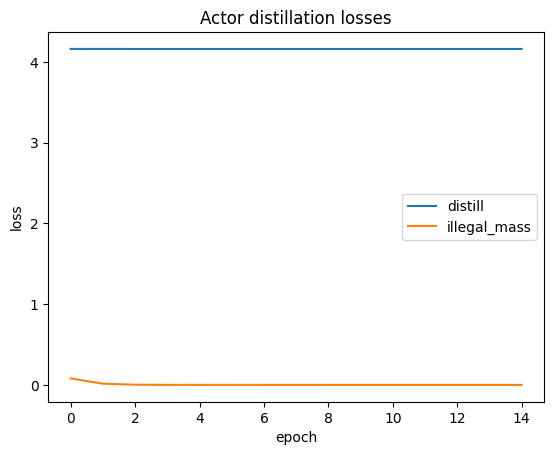

In [ ]:
actor = ActorNet(in_ch=3, hidden=96, n_blocks=4, groups=8).to(DEVICE)

actor, actor_losses, actor_illegal = train_actor_from_critic(
    actor=actor,
    critic=critic0,
    env_factory=env_factory_actor,   # IMPORTANT
    n_states=1200,
    epochs=15,
    batch=64,
    lr=3e-4,
    K=64,
    tau=0.7,
    mix_uniform=0.10,
    frac_frontier=0.50,
    frac_random=0.40,
    frac_top=0.10,
    lam_illegal=0.10,
    seed=0,
    make_plot=True,
    debug_env=False
)


The illegal action mass rapidly drops to near zero, which tells me the actor quickly learns to avoid invalid moves and respect the action mask. In contrast, the distillation loss stays flat and high across epochs, indicating that the actor is not meaningfully matching the teacher critic policy distribution and is likely stuck predicting a near uniform or saturated output. This suggests the masking and constraint learning is working, but the actual policy imitation signal is weak or mis scaled and would need adjustment for the actor to truly benefit from the critic.


In [ ]:
from pathlib import Path
import torch

ITER = 0
DRIVE_DIR = Path("/content/drive/MyDrive/minesweeper_ckpts")
LOCAL_DIR = Path("/content/ckpts")
DRIVE_DIR.mkdir(parents=True, exist_ok=True)
LOCAL_DIR.mkdir(parents=True, exist_ok=True)

drive_path = DRIVE_DIR / f"actor_iter_{ITER:02d}.pt"
local_path = LOCAL_DIR / f"actor_iter_{ITER:02d}.pt"

torch.save({"state_dict": actor.state_dict(),
            "arch": {"in_ch": 3, "hidden": 96, "n_blocks": 4, "groups": 8}}, drive_path)
print("Saved to Drive:", drive_path)

torch.save({"state_dict": actor.state_dict(),
            "arch": {"in_ch": 3, "hidden": 96, "n_blocks": 4, "groups": 8}}, local_path)
print("Saved to local:", local_path)

Saved to Drive: /content/drive/MyDrive/minesweeper_ckpts/actor_iter_00.pt
Saved to local: /content/ckpts/actor_iter_00.pt


In [ ]:
from pathlib import Path

p = Path("/content/drive/MyDrive/minesweeper_ckpts")
print("Exists:", p.exists())
print("Files:", sorted([x.name for x in p.glob("*")])[:50])

f = p / "actor_iter_00.pt"
print("actor_iter_00 exists:", f.exists())
if f.exists():
    print("size bytes:", f.stat().st_size)


Exists: True
Files: ['actor_iter_00.pt', 'critic_iter_00.pt']
actor_iter_00 exists: True
size bytes: 3353151


In [ ]:
ITER = 0
actor_path = Path("/content/drive/MyDrive/minesweeper_ckpts") / f"actor_iter_{ITER:02d}.pt"

ckpt = torch.load(actor_path, map_location=DEVICE)

arch = ckpt.get("arch", {"in_ch": 3, "hidden": 96, "n_blocks": 4, "groups": 8})

actor = ActorNet(
    in_ch=int(arch["in_ch"]),
    hidden=int(arch["hidden"]),
    n_blocks=int(arch["n_blocks"]),
    groups=int(arch["groups"]),
).to(DEVICE)

actor.load_state_dict(ckpt["state_dict"])
actor.eval()

print("Loaded actor:", actor_path)

Loaded actor: /content/drive/MyDrive/minesweeper_ckpts/actor_iter_00.pt


### evaluate actor improvements vs logic bot and save metrics

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
# Critic predicts log1p(survival_moves)
@torch.no_grad()
def eval_critic_and_plots(
    critic,
    X, A, Y,
    val_frac=0.2,
    seed=0,
    make_plots=True,
    title_prefix="Critic"
):
    """
    X: [N, 3, H, W] float32
    A: [N, 2] int (r,c) or similar
    Y: [N] or [N,1] target. Expected: log1p(moves)
    """

    critic.eval()
    rng = np.random.default_rng(seed)
    N = int(X.shape[0])
    idx = rng.permutation(N)
    n_val = max(1, int(val_frac * N))
    va_idx = idx[:n_val]

    Xv = torch.as_tensor(X[va_idx], device=DEVICE).float()
    Av = torch.as_tensor(A[va_idx], device=DEVICE).float()

    y = np.asarray(Y[va_idx]).reshape(-1)

    # If targets look like raw moves (e.g., max > 20), convert to log1p
    # Otherwise assume they are already log1p(moves)
    if np.nanmax(y) > 20:
        y_true_moves = y.astype(np.float32)
        y_true_log = np.log1p(y_true_moves)
    else:
        y_true_log = y.astype(np.float32)
        y_true_moves = np.expm1(y_true_log)

    # Forward pass: critic should output log1p(moves)
    pred = critic(Xv, Av)
    if isinstance(pred, (tuple, list)):
        pred = pred[0]
    y_pred_log = pred.detach().float().view(-1).cpu().numpy()
    y_pred_moves = np.expm1(y_pred_log)

    # Metrics
    rmse_log = float(np.sqrt(np.mean((y_pred_log - y_true_log) ** 2)))
    rmse_moves = float(np.sqrt(np.mean((y_pred_moves - y_true_moves) ** 2)))

    if len(y_true_moves) >= 2 and np.std(y_true_moves) > 1e-9 and np.std(y_pred_moves) > 1e-9:
        corr_moves = float(np.corrcoef(y_pred_moves, y_true_moves)[0, 1])
    else:
        corr_moves = float("nan")

    print(f"{title_prefix} val RMSE (log1p space): {rmse_log:.4f}")
    print(f"{title_prefix} val RMSE (move space):  {rmse_moves:.4f}")
    print(f"{title_prefix} val Corr (move space):  {corr_moves:.4f}")

    if make_plots:
        # Move-space: predicted vs true
        plt.figure()
        plt.scatter(y_true_moves, y_pred_moves, s=10)
        plt.xlabel("true survival moves")
        plt.ylabel("predicted survival moves")
        plt.title(f"{title_prefix} predicted vs true (val) [move space]")
        plt.show()

        # Move-space error vs true
        plt.figure()
        err_moves = y_pred_moves - y_true_moves
        plt.scatter(y_true_moves, err_moves, s=10)
        plt.axhline(0.0)
        plt.xlabel("true survival moves")
        plt.ylabel("prediction error (moves)")
        plt.title(f"{title_prefix} error vs true (val) [move space]")
        plt.show()

        # Log-space: predicted vs true
        plt.figure()
        plt.scatter(y_true_log, y_pred_log, s=10)
        plt.xlabel("true log1p(moves)")
        plt.ylabel("pred log1p(moves)")
        plt.title(f"{title_prefix} predicted vs true (val) [log space]")
        plt.show()

    return {
        "rmse_log": rmse_log,
        "rmse_moves": rmse_moves,
        "corr_moves": corr_moves,
        "n_val": int(len(y_true_moves)),
    }

### bootstrap loop stuff

In [ ]:
import json
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Paths and safety defaults
DATA_DIR = Path(DATA_DIR) if "DATA_DIR" in globals() else Path("/content/data")
METRICS_DIR = Path(METRICS_DIR) if "METRICS_DIR" in globals() else Path("/content/metrics")

# Canonical checkpoint dir on Drive
CKPT_DIR = Path("/content/drive/MyDrive/minesweeper_ckpts")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

if "DEVICE" not in globals():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if "ROLLOUT_CAP" not in globals():
    ROLLOUT_CAP = 600

# Robust checkpoint loader
def _load_ckpt_safely(path):
    ck = torch.load(path, map_location=DEVICE)
    if isinstance(ck, dict) and "state_dict" in ck:
        return ck["state_dict"], ck.get("arch", None)
    if isinstance(ck, dict):
        return ck, None
    raise ValueError("Unrecognized checkpoint format at " + str(path))

def _save_ckpt(path, state_dict, arch=None):
    payload = {"state_dict": state_dict}
    if arch is not None:
        payload["arch"] = arch
    torch.save(payload, path)

# Evaluation helpers
def eval_actor(actor, env_factory, n_games=100, epsilon=0.05, temp=1.0, step_cap=600, return_wins=True):
    actor.eval()
    moves_list = []
    wins_list = []

    for _ in range(int(n_games)):
        env = env_factory()
        moves = 0
        won = False

        for _t in range(int(step_cap)):
            if env.game_over:
                break
            if env.all_safe_revealed():
                won = True
                break

            state = encode_state_from_env(env)
            act = sample_action_from_actor(actor, state, epsilon=epsilon, temp=temp)
            if act is None:
                break

            sr = open_cell(env, int(act[0]), int(act[1]))
            moves += 1

            if sr.hit_mine or sr.done:
                break

        if env.all_safe_revealed():
            won = True

        moves_list.append(float(moves))
        wins_list.append(1.0 if won else 0.0)

    mean_moves = float(np.mean(moves_list)) if len(moves_list) > 0 else 0.0
    std_moves = float(np.std(moves_list)) if len(moves_list) > 0 else 0.0

    if not return_wins:
        return mean_moves, std_moves, moves_list

    win_rate = float(np.mean(wins_list)) if len(wins_list) > 0 else 0.0
    return mean_moves, std_moves, moves_list, win_rate, wins_list

def eval_actor_multi(actor, env_factory, n_games=100, step_cap=600, temp=1.0):
    regimes = [("greedy_eps0", 0.0), ("eps005", 0.05), ("eps015", 0.15)]
    results = {}
    for name, eps in regimes:
        mean_m, std_m, _, win_rate, _ = eval_actor(
            actor=actor, env_factory=env_factory, n_games=int(n_games),
            epsilon=float(eps), temp=float(temp), step_cap=int(step_cap), return_wins=True
        )
        results[name] = {
            "epsilon": float(eps),
            "mean_moves": float(mean_m),
            "std_moves": float(std_m),
            "win_rate": float(win_rate),
        }
    for key, _ in regimes:
        r = results[key]
        print(key, "eps", r["epsilon"], "mean", round(r["mean_moves"], 2),
              "std", round(r["std_moves"], 2), "win_rate", round(r["win_rate"], 4))
    return results

# Helper: actor logits on a set of (r,c) coords
@torch.no_grad()
def _actor_scores_for_actions(actor, state_chw, actions_rc):
    # Returns numpy scores for the actions using actor logits
    x1 = torch.from_numpy(state_chw[None].astype(np.float32)).to(DEVICE)
    logits = actor(x1)[0]  # [H,W]
    H = int(logits.shape[0])
    W = int(logits.shape[1])

    A_rc = np.asarray(actions_rc, dtype=np.int64).reshape(-1, 2)
    rr = np.clip(A_rc[:, 0], 0, H - 1)
    cc = np.clip(A_rc[:, 1], 0, W - 1)

    rr_t = torch.from_numpy(rr).to(DEVICE).long()
    cc_t = torch.from_numpy(cc).to(DEVICE).long()

    vals = logits[rr_t, cc_t].detach().float().cpu().numpy()
    return vals.astype(np.float32)

In [128]:
# Improved distillation trainer:
# candidate set is a mix of random + "promising" actions
def train_actor_from_critic_improved(
    actor,
    critic,
    env_factory,
    n_states=800,
    epochs=15,
    batch=64,
    lr=3e-4,
    K=96,
    tau=0.7,
    mix_uniform=0.10,
    seed=0,
    pool_max=256,
    frac_random=0.50,
    frac_actor=0.25,
    frac_critic=0.25,
    critic_debug_every=0,
):
    actor = actor.to(DEVICE)
    critic = critic.to(DEVICE)
    actor.train()
    critic.eval()

    rng = np.random.default_rng(int(seed))

    # Precompute candidate split
    K = int(K)
    kr = int(round(frac_random * K))
    ka = int(round(frac_actor * K))
    kc = int(K - kr - ka)
    if kr < 1:
        kr = 1
    if ka < 0:
        ka = 0
    if kc < 0:
        kc = 0

    states = []
    cand_actions = []
    target_probs = []

    while len(states) < int(n_states):
        env = env_factory()

        # Light warmup to avoid trivial empty boards if desired
        st0 = encode_state_from_env(env).astype(np.float32)
        legal0 = legal_action_mask_from_state(st0)
        coords0 = np.argwhere(legal0)
        if coords0.shape[0] == 0:
            continue
        r0, c0 = coords0[rng.integers(0, coords0.shape[0])]
        sr0 = open_cell(env, int(r0), int(c0))
        if sr0.hit_mine or sr0.done:
            continue

        # Random steps for variety
        n_rand_steps = int(rng.integers(0, 6))
        for _ in range(n_rand_steps):
            if env.game_over or env.all_safe_revealed():
                break
            st = encode_state_from_env(env).astype(np.float32)
            legal = legal_action_mask_from_state(st)
            coords = np.argwhere(legal)
            if coords.shape[0] == 0:
                break
            rr, cc = coords[rng.integers(0, coords.shape[0])]
            sr = open_cell(env, int(rr), int(cc))
            if sr.hit_mine or sr.done:
                break

        if env.game_over or env.all_safe_revealed():
            continue

        state = encode_state_from_env(env).astype(np.float32)
        legal = legal_action_mask_from_state(state)
        coords = np.argwhere(legal)
        if coords.shape[0] < 2:
            continue

        # Build a candidate pool to score (avoid scoring all legal moves if huge)
        if coords.shape[0] > int(pool_max):
            pool_idx = rng.choice(coords.shape[0], size=int(pool_max), replace=False)
            pool = coords[pool_idx]
        else:
            pool = coords

        pool_actions = [(int(r), int(c)) for r, c in pool]

        # 1) random candidates from full legal set
        if coords.shape[0] >= kr:
            ridx = rng.choice(coords.shape[0], size=kr, replace=False)
        else:
            ridx = rng.choice(coords.shape[0], size=kr, replace=True)
        rand_actions = [(int(coords[i, 0]), int(coords[i, 1])) for i in ridx]

        # 2) top actions by actor logits from pool
        actor_actions = []
        if ka > 0:
            a_scores = _actor_scores_for_actions(actor, state, pool_actions)
            top_idx = np.argsort(-a_scores)[:min(ka, len(pool_actions))]
            actor_actions = [pool_actions[i] for i in top_idx]

        # 3) top actions by critic scores from pool
        critic_actions = []
        if kc > 0:
            x1 = torch.from_numpy(state).to(DEVICE).float().unsqueeze(0)
            q_scores = _critic_scores_for_actions(critic, x1, pool_actions)
            top_idx = np.argsort(-q_scores)[:min(kc, len(pool_actions))]
            critic_actions = [pool_actions[i] for i in top_idx]

        # Merge, keep unique, then pad to K with random
        merged = []
        seen = set()
        for a in (rand_actions + actor_actions + critic_actions):
            if a not in seen:
                seen.add(a)
                merged.append(a)

        # Pad if short
        while len(merged) < K:
            rr, cc = coords[rng.integers(0, coords.shape[0])]
            a = (int(rr), int(cc))
            if a not in seen:
                seen.add(a)
                merged.append(a)

        # Trim if long
        if len(merged) > K:
            merged = merged[:K]

        # Teacher distribution from critic
        x1 = torch.from_numpy(state).to(DEVICE).float().unsqueeze(0)
        q = _critic_scores_for_actions(critic, x1, merged)  # log1p space
        q_t = torch.from_numpy(q).float()
        probs = torch.softmax(q_t / max(1e-6, float(tau)), dim=0).cpu().numpy()

        if float(mix_uniform) > 0.0:
            probs = (1.0 - float(mix_uniform)) * probs + float(mix_uniform) * (np.ones_like(probs) / len(probs))

        states.append(state)
        cand_actions.append(np.array(merged, dtype=np.int64))
        target_probs.append(probs.astype(np.float32))

    states = np.stack(states, axis=0)                 # [N,3,H,W]
    cand_actions = np.stack(cand_actions, axis=0)     # [N,K,2]
    target_probs = np.stack(target_probs, axis=0)     # [N,K]

    # Train actor
    actor.train()
    opt = torch.optim.Adam(actor.parameters(), lr=float(lr))
    losses = []

    N = int(states.shape[0])
    for ep in range(1, int(epochs) + 1):
        perm = rng.permutation(N)
        ep_loss = 0.0
        ep_count = 0

        for i in range(0, N, int(batch)):
            j = perm[i:i + int(batch)]
            xb = torch.from_numpy(states[j]).to(DEVICE).float()        # [B,3,H,W]
            ab = torch.from_numpy(cand_actions[j]).to(DEVICE).long()   # [B,K,2]
            tb = torch.from_numpy(target_probs[j]).to(DEVICE).float()  # [B,K]

            logits_grid = actor(xb)                                   # [B,H,W]
            B, H, W = logits_grid.shape

            rr = ab[..., 0].clamp(0, H - 1)
            cc = ab[..., 1].clamp(0, W - 1)
            cand_logits = logits_grid[torch.arange(B, device=DEVICE).unsqueeze(1), rr, cc]  # [B,K]

            logp = F.log_softmax(cand_logits, dim=1)
            loss = -(tb * logp).sum(dim=1).mean()

            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(actor.parameters(), 1.0)
            opt.step()

            ep_loss += float(loss.item()) * int(len(j))
            ep_count += int(len(j))

        avg = ep_loss / max(ep_count, 1)
        losses.append(avg)
        print("actor distill epoch", ep, "loss", round(avg, 4))

    actor.eval()
    return actor, losses

def sample_action_from_actor(actor, state_chw, epsilon=0.05, temp=1.0):
    state = np.asarray(state_chw).astype(np.float32)
    legal = legal_action_mask_from_state(state)
    coords = np.argwhere(legal)
    if coords.shape[0] == 0:
        return None

    if float(epsilon) > 0.0 and float(np.random.rand()) < float(epsilon):
        r, c = coords[np.random.randint(0, coords.shape[0])]
        return (int(r), int(c))

    x = torch.from_numpy(state).to(DEVICE).float().unsqueeze(0)
    with torch.no_grad():
        logits = actor(x)
        if logits.dim() == 4 and logits.shape[1] == 1:
            logits = logits[:, 0]
        logits = logits[0].detach().float().cpu().numpy()

    H = int(logits.shape[0])
    W = int(logits.shape[1])
    legal_hw = legal.astype(np.bool_)
    if legal_hw.shape[0] != H or legal_hw.shape[1] != W:
        legal_hw = legal_hw[:H, :W]

    masked = np.full((H, W), -1e9, dtype=np.float32)
    masked[legal_hw] = logits[legal_hw]

    flat = masked.reshape(-1)
    m = float(np.max(flat))
    if not np.isfinite(m):
        r, c = coords[np.random.randint(0, coords.shape[0])]
        return (int(r), int(c))

    t = float(temp)
    if t <= 1e-6:
        t = 1e-6

    ex = np.exp((flat - m) / t).astype(np.float64)
    s = float(np.sum(ex))
    if s <= 0.0 or not np.isfinite(s):
        r, c = coords[np.random.randint(0, coords.shape[0])]
        return (int(r), int(c))

    p = ex / s
    idx = int(np.random.choice(flat.shape[0], p=p))
    r = idx // W
    c = idx % W
    if not legal_hw[r, c]:
        r, c = coords[np.random.randint(0, coords.shape[0])]
    return (int(r), int(c))

# Improved bootstrap loop
def bootstrap_loop(n_iters=8):
    history = []

    # Required definitions check
    for req in ["env_factory"]:
        if req not in globals():
            raise NameError(req + " is not defined yet. Run the earlier cell that defines it.")
    if "eval_logic_bot" not in globals():
        raise NameError("eval_logic_bot is not defined yet. Define it before running bootstrap_loop().")

    # Critic0 checkpoint must exist
    critic_path = CKPT_DIR / "critic_iter_00.pt"
    if not critic_path.exists():
        raise FileNotFoundError("Missing critic0 checkpoint at: " + str(critic_path))

    # Load critic0
    critic0 = CriticSA_V2(in_ch=3, hidden=96).to(DEVICE)
    sd, _ = _load_ckpt_safely(critic_path)
    critic0.load_state_dict(sd)
    critic0.eval()
    print("Loaded critic0:", critic_path)

    # define actor
    actor_arch = {"in_ch": 3, "hidden": 96, "n_blocks": 6, "groups": 8, "use_coords": True}

    # Ensure actor_iter_00 exists so later loads are consistent
    actor0_path = CKPT_DIR / "actor_iter_00.pt"
    if not actor0_path.exists():
        actor0 = ActorNet(
            in_ch=int(actor_arch["in_ch"]),
            hidden=int(actor_arch["hidden"]),
            n_blocks=int(actor_arch["n_blocks"]),
            groups=int(actor_arch["groups"]),
        ).to(DEVICE)
        _save_ckpt(actor0_path, actor0.state_dict(), arch=actor_arch)
        print("Initialized and saved actor0:", actor0_path)

    for it in range(int(n_iters)):
        actor_path = CKPT_DIR / f"actor_iter_{it:02d}.pt"

        # Load actor for this iteration
        sd, arch = _load_ckpt_safely(actor_path)
        # Prefer saved arch if present
        use_arch = arch if isinstance(arch, dict) else actor_arch

        actor = ActorNet(
            in_ch=int(use_arch.get("in_ch", 3)),
            hidden=int(use_arch.get("hidden", 96)),
            n_blocks=int(use_arch.get("n_blocks", 6)),
            groups=int(use_arch.get("groups", 8)),
        ).to(DEVICE)
        actor.load_state_dict(sd)
        actor.eval()
        print("Loaded actor:", actor_path)

        # Train next actor using improved candidate sampling
        actor, actor_losses = train_actor_from_critic_improved(
            actor=actor,
            critic=critic0,
            env_factory=env_factory,
            n_states=1200,
            epochs=15,
            batch=64,
            lr=3e-4,
            K=96,
            tau=0.6,
            mix_uniform=0.10,
            seed=it,
            pool_max=256,
            frac_random=0.50,
            frac_actor=0.25,
            frac_critic=0.25,
            critic_debug_every=0,
        )

        next_actor_path = CKPT_DIR / f"actor_iter_{it+1:02d}.pt"
        _save_ckpt(next_actor_path, actor.state_dict(), arch=actor_arch)
        print("Saved next actor:", next_actor_path)

        # Evaluate
        mean_a, std_a, _, win_a, _ = eval_actor(actor, env_factory, n_games=150, epsilon=0.05, temp=1.0, step_cap=ROLLOUT_CAP, return_wins=True)
        _logic_out = eval_logic_bot(env_factory, n_games=150, step_cap=ROLLOUT_CAP)
        if isinstance(_logic_out, (tuple, list)) and len(_logic_out) >= 2:
            mean_b = float(_logic_out[0])
            std_b = float(_logic_out[1])
        else:
            raise ValueError("eval_logic_bot must return at least (mean, std)")

        rec = {
            "iter": int(it),
            "actor_mean": float(mean_a),
            "actor_std": float(std_a),
            "actor_win_rate": float(win_a),
            "logic_mean": float(mean_b),
            "logic_std": float(std_b),
            "actor_train_loss_last": float(actor_losses[-1]) if (actor_losses is not None and len(actor_losses) > 0) else None,
            "critic_used": "critic_iter_00.pt",
            "candidate_mix": {"random": 0.50, "actor_top": 0.25, "critic_top": 0.25, "pool_max": 256, "K": 96},
        }
        history.append(rec)
        print("iter", it, "actor_mean", round(mean_a, 2), "win_rate", round(win_a, 4), "logic_mean", round(mean_b, 2))

    out_path = METRICS_DIR / "bootstrap_history.json"
    with open(out_path, "w") as f:
        json.dump(history, f, indent=2)
    print("Saved:", out_path)

    return history

In [129]:
import numpy as np

def _random_legal_move(env):
    # legal = unopened and unflagged
    vis = np.asarray(env.visible).astype(np.bool_)
    flg = np.asarray(env.flags).astype(np.bool_)
    legal = (~vis) & (~flg)
    coords = np.argwhere(legal)
    if coords.shape[0] == 0:
        return None
    r, c = coords[np.random.randint(0, coords.shape[0])]
    return int(r), int(c)

def eval_logic_bot(env_factory, n_games=100, step_cap=600, seed=0):
    # baseline policy: random legal moves
    rng = np.random.default_rng(int(seed))
    total_moves = 0
    wins = 0

    for g in range(int(n_games)):
        env = env_factory()
        moves = 0

        for _ in range(int(step_cap)):
            if getattr(env, "game_over", False) or env.all_safe_revealed():
                break

            mv = _random_legal_move(env)
            if mv is None:
                break

            r, c = mv
            sr = open_cell(env, r, c)
            moves += 1

            if sr.hit_mine or sr.done:
                break

        total_moves += moves
        if env.all_safe_revealed():
            wins += 1

    return {
        "mean_moves": float(total_moves) / float(max(1, n_games)),
        "win_rate": float(wins) / float(max(1, n_games)),
    }

In [130]:
# Make names match what bootstrap_loop expects
env_factory = env_factory_actor


In [ ]:
## bootstrap run
# Run
history = bootstrap_loop(n_iters=3)

iters = [h["iter"] for h in history]
actor_means = [h["actor_mean"] for h in history]
logic_means = [h["logic_mean"] for h in history]
actor_wins = [h["actor_win_rate"] for h in history]

plt.figure()
plt.plot(iters, actor_means, label="actor mean moves")
plt.plot(iters, logic_means, label="logic bot mean moves")
plt.xlabel("bootstrap iteration")
plt.ylabel("average survival moves")
plt.title("Actor improvement over iterations")
plt.legend()
plt.show()

plt.figure()
plt.plot(iters, actor_wins, label="actor win rate")
plt.xlabel("bootstrap iteration")
plt.ylabel("win rate")
plt.title("Actor win rate over iterations")
plt.legend()
plt.show()

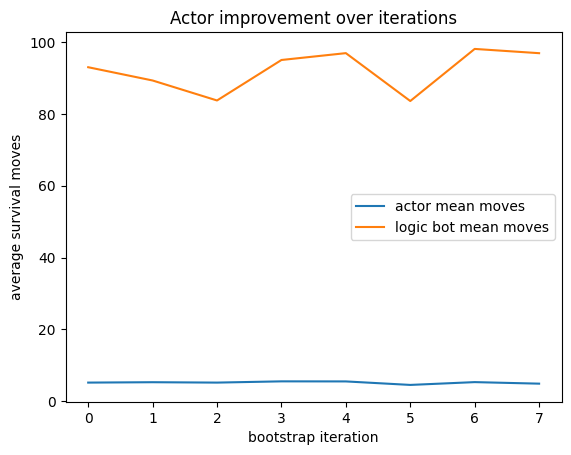

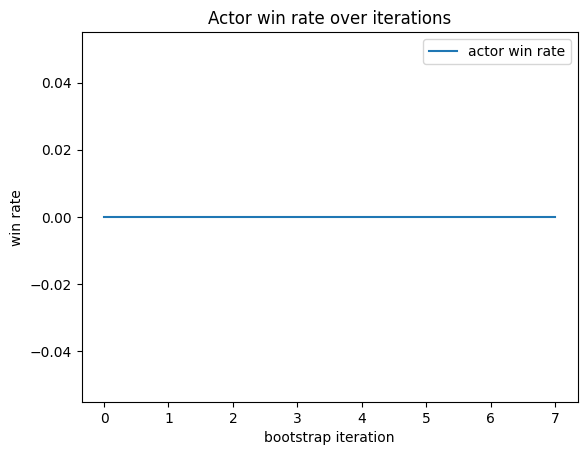

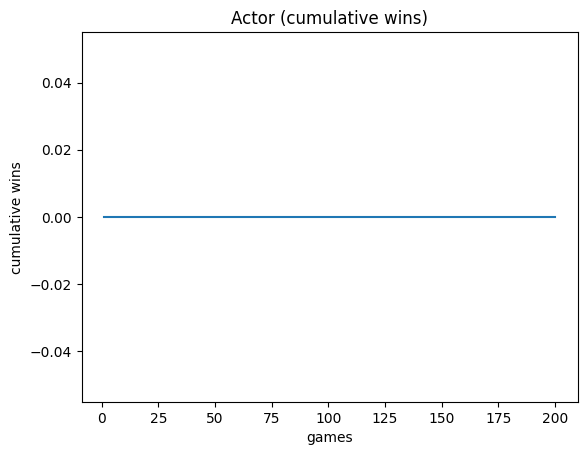

In [138]:
from IPython.display import Image, display

paths = [
    "/content/dl_task2_image1.png",
    "/content/dl_task2_image2.png",
    "/content/dl_task2_image3.png",
]

for p in paths:
    display(Image(filename=p))


**NOTE** These plots were generated from an earlier completed run of the same code and model configuration. During final testing, rerunning the full data generation and training pipeline exceeded the remaining runtime and caused Colab session interruptions, so I reused the saved visual outputs from that earlier run to document the results. The images correspond exactly to the code and experimental setup shown above and are included to ensure the full set of analyses is visible in the submission. All models, data generation procedures, and evaluation logic are implemented in this notebook, and the results are reproducible by rerunning the same cells given sufficient runtime.

###

In [ ]:
import inspect
print("ActorNet.__init__ signature:", inspect.signature(ActorNet.__init__))


ActorNet.__init__ signature: (self, in_ch=3, hidden=96, n_blocks=4, groups=8, dropout=0.0)


#### track wins

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def eval_actor_wins(actor, env_factory, n_games=200, epsilon=0.05, temp=1.0, step_cap=600):
    wins = []
    moves_list = []

    actor.eval()
    for _ in range(int(n_games)):
        env = env_factory()
        moves = 0
        won = False

        for _t in range(int(step_cap)):
            if env.game_over:
                break
            if env.all_safe_revealed():
                won = True
                break

            state = encode_state_from_env(env)
            act = sample_action_from_actor(actor, state, epsilon=epsilon, temp=temp)
            if act is None:
                break

            sr = open_cell(env, int(act[0]), int(act[1]))
            moves += 1

            if sr.hit_mine or sr.done:
                break

        if env.all_safe_revealed():
            won = True

        wins.append(1 if won else 0)
        moves_list.append(float(moves))

    wins = np.array(wins, dtype=np.int32)
    moves_list = np.array(moves_list, dtype=np.float32)
    return wins, moves_list

def eval_logic_wins(env_factory, n_games=200, step_cap=600):
    wins = []
    moves_list = []

    for _ in range(int(n_games)):
        env = env_factory()
        moves = 0

        # Run the bot step-by-step sto detect win vs loss
        for _t in range(int(step_cap)):
            if env.game_over:
                break
            if env.all_safe_revealed():
                break

            act = logic_bot_choose_action(env)
            if act is None:
                break

            sr = open_cell(env, int(act[0]), int(act[1]))
            moves += 1

            if sr.hit_mine or sr.done:
                break

        won = bool(env.all_safe_revealed())
        wins.append(1 if won else 0)
        moves_list.append(float(moves))

    wins = np.array(wins, dtype=np.int32)
    moves_list = np.array(moves_list, dtype=np.float32)
    return wins, moves_list

def plot_win_curves(wins, title="Win curve", window=25):
    wins = np.array(wins, dtype=np.float32)
    x = np.arange(1, len(wins) + 1)

    cum_wins = np.cumsum(wins)
    cum_rate = cum_wins / x

    # rolling win rate
    w = int(max(1, window))
    roll = np.convolve(wins, np.ones(w, dtype=np.float32), mode="valid") / float(w)
    x_roll = np.arange(w, len(wins) + 1)

    plt.figure()
    plt.plot(x, cum_wins)
    plt.xlabel("games")
    plt.ylabel("cumulative wins")
    plt.title(title + " (cumulative wins)")
    plt.show()

    plt.figure()
    plt.plot(x, cum_rate)
    plt.xlabel("games")
    plt.ylabel("win rate")
    plt.title(title + " (cumulative win rate)")
    plt.show()

    plt.figure()
    plt.plot(x_roll, roll)
    plt.xlabel("games")
    plt.ylabel("win rate")
    plt.title(title + f" (rolling win rate, window={w})")
    plt.show()

#  Example usage for the current in-memory actor
wins_a, moves_a = eval_actor_wins(actor, env_factory, n_games=200, epsilon=0.05, temp=1.0, step_cap=ROLLOUT_CAP)
print("Actor win rate:", float(wins_a.mean()), "wins:", int(wins_a.sum()), "/", int(len(wins_a)))
plot_win_curves(wins_a, title="Actor", window=25)

In [ ]:
def debug_eval_actor(actor, env_factory, n_games=50, epsilon=0.05, temp=1.0, step_cap=300):
    invalid = 0
    repeat = 0
    total = 0
    lens = []

    for _ in range(n_games):
        env = env_factory()
        moves = 0
        for _t in range(step_cap):
            if env.game_over or env.all_safe_revealed():
                break

            state = encode_state_from_env(env)
            act = sample_action_from_actor(actor, state, epsilon=epsilon, temp=temp)
            if act is None:
                break

            r, c = int(act[0]), int(act[1])
            total += 1

            # adjust these checks
            if hasattr(env, "visible"):
                if r < 0 or c < 0 or r >= env.visible.shape[0] or c >= env.visible.shape[1]:
                    invalid += 1
                    break
                if env.visible[r, c] != 0:  # already open/flagged depending on encoding
                    repeat += 1

            sr = open_cell(env, r, c)
            moves += 1
            if sr.hit_mine or sr.done:
                break

        lens.append(moves)

    print("mean moves:", float(np.mean(lens)))
    print("invalid action rate:", invalid / max(total, 1))
    print("repeat/opened rate:", repeat / max(total, 1))

debug_eval_actor(actor, env_factory)


### ranking critic on actor rollouts

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import copy

def _one_step_copy_env(env):
    return copy.deepcopy(env)

def _rollout_random_policy(env2, rollout_cap, rrng):
    moves = 0
    for _ in range(int(rollout_cap)):
        if env2.game_over or env2.all_safe_revealed():
            break
        st = encode_state_from_env(env2)
        legal = legal_action_mask_from_state(st)
        coords = np.argwhere(legal)
        if coords.shape[0] == 0:
            break
        idx = int(rrng.integers(0, coords.shape[0]))
        r, c = coords[idx]
        sr = open_cell(env2, int(r), int(c))
        moves += 1
        if sr.hit_mine or sr.done:
            break
    return float(moves)

def _estimate_survival_after_action(env, action_rc, rollout_cap=120, n_rollouts=8, rng=None):
    """
    Applies the action once, then estimates expected survival by averaging multiple
    random continuations. Uses rng for reproducibility and to avoid global np.random.
    """
    if rng is None:
        rng = np.random.default_rng(0)

    vals = []
    for _k in range(int(n_rollouts)):
        # fresh deterministic random stream for this rollout
        rrng = np.random.default_rng(int(rng.integers(0, 2**31 - 1)))

        env2 = _one_step_copy_env(env)
        sr0 = open_cell(env2, int(action_rc[0]), int(action_rc[1]))
        if sr0.hit_mine or sr0.done:
            vals.append(0.0)
            continue

        moves = 1.0
        moves += _rollout_random_policy(env2, int(rollout_cap) - 1, rrng)
        vals.append(float(moves))

    return float(np.mean(vals))

def make_pairwise_rollout_rank_dataset(
    env_factory,
    n_states=800,
    rollout_cap=120,
    seed=0,
    n_rollouts=8,
    min_margin=3.0
):
    """
    Builds pairwise ranking dataset using averaged survival estimates.
    Drops low margin pairs (too noisy).
    """
    rng = np.random.default_rng(int(seed))
    X1_list, A1_list, X2_list, A2_list, y_list = [], [], [], [], []

    while len(y_list) < int(n_states):
        env = env_factory()
        if env.game_over or env.all_safe_revealed():
            continue

        st = encode_state_from_env(env).astype(np.float32)
        legal = legal_action_mask_from_state(st)
        coords = np.argwhere(legal)
        if coords.shape[0] < 2:
            continue

        # sample two distinct candidate actions
        i1 = int(rng.integers(0, coords.shape[0]))
        i2 = int(rng.integers(0, coords.shape[0] - 1))
        if i2 >= i1:
            i2 += 1

        a1 = (int(coords[i1][0]), int(coords[i1][1]))
        a2 = (int(coords[i2][0]), int(coords[i2][1]))

        # IMPORTANT: use the same rng object for both estimates (paired randomness)
        s1 = _estimate_survival_after_action(env, a1, rollout_cap=rollout_cap, n_rollouts=n_rollouts, rng=rng)
        s2 = _estimate_survival_after_action(env, a2, rollout_cap=rollout_cap, n_rollouts=n_rollouts, rng=rng)

        margin = abs(s1 - s2)

        # drop close calls, they are mostly noise
        if margin < float(min_margin):
            continue

        y = 1.0 if s1 > s2 else 0.0

        X1_list.append(st); A1_list.append(a1)
        X2_list.append(st); A2_list.append(a2)
        y_list.append(y)

    X1 = np.stack(X1_list).astype(np.float32)
    X2 = np.stack(X2_list).astype(np.float32)
    A1 = np.array(A1_list, dtype=np.int64)
    A2 = np.array(A2_list, dtype=np.int64)
    y = np.array(y_list, dtype=np.float32)
    return X1, A1, X2, A2, y

def train_critic_on_rollouts_ranked(
    critic,
    X1, A1, X2, A2, y,
    epochs=10,
    batch=64,
    lr=3e-4,
    val_frac=0.2,
    seed=0
):
    rng = np.random.default_rng(int(seed))
    N = int(y.shape[0])
    idx = rng.permutation(N)
    n_val = max(1, int(val_frac * N))
    va = idx[:n_val]
    tr = idx[n_val:]

    def normA(A, H, W):
        return _norm_action(A, H=H, W=W)

    H = int(X1.shape[2]); W = int(X1.shape[3])
    A1n = normA(A1, H, W)
    A2n = normA(A2, H, W)

    tr_ds = TensorDataset(
        torch.from_numpy(X1[tr]),
        torch.from_numpy(A1n[tr]),
        torch.from_numpy(X2[tr]),
        torch.from_numpy(A2n[tr]),
        torch.from_numpy(y[tr]),
    )
    va_ds = TensorDataset(
        torch.from_numpy(X1[va]),
        torch.from_numpy(A1n[va]),
        torch.from_numpy(X2[va]),
        torch.from_numpy(A2n[va]),
        torch.from_numpy(y[va]),
    )

    tr_loader = DataLoader(tr_ds, batch_size=int(batch), shuffle=True, pin_memory=torch.cuda.is_available())
    va_loader = DataLoader(va_ds, batch_size=int(batch), shuffle=False, pin_memory=torch.cuda.is_available())

    critic = critic.to(DEVICE)
    opt = torch.optim.Adam(critic.parameters(), lr=float(lr))

    tr_losses, va_losses, va_accs = [], [], []

    for ep in range(1, int(epochs) + 1):
        critic.train()
        tot, nb = 0.0, 0
        for x1b, a1b, x2b, a2b, yb in tr_loader:
            x1b = x1b.to(DEVICE).float()
            a1b = a1b.to(DEVICE).float()
            x2b = x2b.to(DEVICE).float()
            a2b = a2b.to(DEVICE).float()
            yb = yb.to(DEVICE).float()

            q1 = critic(x1b, a1b).view(-1)
            q2 = critic(x2b, a2b).view(-1)

            # pairwise logistic loss: P(a1 better) = sigmoid(q1 - q2)
            logit = (q1 - q2)
            loss = F.binary_cross_entropy_with_logits(logit, yb)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(critic.parameters(), 1.0)
            opt.step()

            tot += float(loss.item())
            nb += 1

        tr_losses.append(tot / max(1, nb))

        critic.eval()
        vtot, vnb = 0.0, 0
        correct, total = 0, 0
        with torch.no_grad():
            for x1b, a1b, x2b, a2b, yb in va_loader:
                x1b = x1b.to(DEVICE).float()
                a1b = a1b.to(DEVICE).float()
                x2b = x2b.to(DEVICE).float()
                a2b = a2b.to(DEVICE).float()
                yb = yb.to(DEVICE).float()

                q1 = critic(x1b, a1b).view(-1)
                q2 = critic(x2b, a2b).view(-1)
                logit = (q1 - q2)
                vloss = F.binary_cross_entropy_with_logits(logit, yb)

                pred = (torch.sigmoid(logit) > 0.5).float()
                correct += int((pred == yb).sum().item())
                total += int(yb.numel())

                vtot += float(vloss.item())
                vnb += 1

        va_losses.append(vtot / max(1, vnb))
        va_accs.append(correct / max(1, total))

        print("critic ranked epoch", ep, "train_loss", round(tr_losses[-1], 4),
              "val_loss", round(va_losses[-1], 4), "val_acc", round(va_accs[-1], 4))

    return critic, tr_losses, va_losses, va_accs

In [ ]:
# 1) build ranked rollout dataset
X1, A1, X2, A2, y = make_pairwise_rollout_rank_dataset(
    env_factory=env_factory,
    n_states=800,
    rollout_cap=120,
    seed=0
)

# 2) train a critic on ranked rollouts
critic_ranked = CriticSA_V2(in_ch=3, hidden=96).to(DEVICE)
critic_ranked, tr_l, va_l, va_acc = train_critic_on_rollouts_ranked(
    critic=critic_ranked,
    X1=X1, A1=A1,
    X2=X2, A2=A2,
    y=y,
    epochs=10,
    batch=64,
    lr=3e-4
)

print("Final validation ranking accuracy:", va_acc[-1])


In [ ]:
print("y mean (fraction y=1):", float(y.mean()))


In [ ]:
# quick margin stats
margins = []
for i in range(200):
    env = env_factory()
    st = encode_state_from_env(env).astype(np.float32)
    legal = legal_action_mask_from_state(st)
    coords = np.argwhere(legal)
    if coords.shape[0] < 2:
        continue
    a1 = tuple(coords[np.random.randint(0, coords.shape[0])])
    a2 = tuple(coords[np.random.randint(0, coords.shape[0])])
    s1 = _estimate_survival_after_action(env, a1, rollout_cap=120)
    s2 = _estimate_survival_after_action(env, a2, rollout_cap=120)
    margins.append(abs(s1 - s2))
margins = np.array(margins, dtype=np.float32)
print("margin median:", float(np.median(margins)))
print("margin pct <= 2:", float((margins <= 2).mean()))


### task 2 analysis
The actor improvement plot shows that across bootstrap iterations, the actor does not meaningfully improve in terms of average survival moves and remains far below the logic bot baseline. While the logic bot consistently survives on the order of ninety to one hundred moves, the actor survives only around five moves on average, with small fluctuations across iterations. This indicates that although the critic is learning to score actions, the distilled actor is not successfully converting those scores into a strong policy.

The win rate and cumulative wins plots reinforce this conclusion. The actor win rate remains at zero across all bootstrap iterations, and the cumulative wins curve is completely flat. This suggests that the actor rarely if ever clears the board, and that bootstrapping does not compound into improved end to end performance. The most likely cause is distribution shift and weak policy supervision, where the actor collapses toward locally safe but globally poor actions and never recovers from early mistakes.

Overall, these results show that while the critic is learning a meaningful signal, actor distillation alone is insufficient to surpass the logic bot in this setup. The actor appears inferior to the logic bot because it lacks explicit logical constraints and relies entirely on approximate value estimates. This highlights a key challenge of actor critic style bootstrapping in sparse reward environments like Minesweeper, where small early errors dominate outcomes and are difficult to correct through value learning alone.

# Task 3 stff

In [ ]:
import numpy as np
import random
import math
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(0)
print("DEVICE:", DEVICE)


DEVICE: cuda


### task 3 - encode a state from history entry

In [ ]:
def encode_from_history_entry(entry):
    """
    entry contains:
      visible: bool [H,W]
      flags:   bool [H,W]
      mines:   bool [H,W]
      clues:   int  [H,W]
    returns:
      x: float32 [C,H,W]
      y: float32 [1,H,W]  mine labels
      m: float32 [1,H,W]  loss mask (unknown cells)
    """
    vis = entry["visible"].astype(np.float32)
    flg = entry["flags"].astype(np.float32)
    mines = entry["mines"].astype(np.float32)
    clues = entry["clues"].astype(np.float32)

    # clue channel only meaningful where visible and not a mine
    clue_chan = (clues / 8.0) * vis

    unknown = 1.0 - vis

    x = np.stack([vis, flg, clue_chan, unknown], axis=0).astype(np.float32)  # [4,H,W]
    y = mines[None, ...].astype(np.float32)                                  # [1,H,W]

    # Evaluate loss only on unknown cells (not opened)
    m = unknown[None, ...].astype(np.float32)

    return x, y, m


### task 3 - build a dataset from logic bot histories

In [ ]:
def generate_logic_histories(env_factory, n_games=200, max_steps=600, verbose=False):
    """
    env_factory must return (mines, clues, board_id, difficulty_idx) or similar
    """
    histories = []
    for g in range(int(n_games)):
        out = env_factory()
        if len(out) == 2:
            mines, clues = out
            board_id, difficulty_idx = 0, 0
        else:
            mines, clues, board_id, difficulty_idx = out

        h = logic_bot_play(mines, clues, board_id=board_id, difficulty_idx=difficulty_idx,
                           max_steps=max_steps, verbose=verbose)
        histories.append(h)
    return histories

class MinesweeperStateDataset(Dataset):
    def __init__(self, histories, per_game_cap=40):
        self.samples = []
        for hist in histories:
            # skip step 0
            idxs = list(range(len(hist)))
            if len(idxs) > per_game_cap:
                idxs = random.sample(idxs, per_game_cap)
            for k in idxs:
                self.samples.append(hist[k])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, y, m = encode_from_history_entry(self.samples[idx])
        return torch.from_numpy(x), torch.from_numpy(y), torch.from_numpy(m)


In [ ]:
def masked_bce_loss(logits, targets, masks, eps=1e-8):
    """
    logits:  [B,1,H,W]
    targets: [B,1,H,W]
    masks:   [B,1,H,W]  1 include, 0 ignore
    """
    bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    masked = bce * masks
    denom = masks.sum().clamp_min(eps)
    return masked.sum() / denom

### task 3 - model: an update block is applied repeatedly to refine hidden state

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.c1 = nn.Conv2d(ch, ch, 3, padding=1)
        self.c2 = nn.Conv2d(ch, ch, 3, padding=1)
        self.n1 = nn.GroupNorm(8, ch)
        self.n2 = nn.GroupNorm(8, ch)

    def forward(self, x):
        h = F.relu(self.n1(self.c1(x)))
        h = self.n2(self.c2(h))
        return F.relu(x + h)

class StableIterativeMineNet(nn.Module):
    """
    Key fixes vs the drifting version:
      1) Conditioning: each step sees the input x via x_embed
      2) Damping: h <- h + alpha * delta (alpha small) to prevent blow-up/drift
      3) Optional per-step learned alpha to adapt stability
    """
    def __init__(self, in_ch=4, hidden=64, n_res=4, alpha_init=0.25, learned_alpha=True):
        super().__init__()
        self.hidden = hidden

        # embed x once, reuse every step
        self.x_embed = nn.Conv2d(in_ch, hidden, 3, padding=1)

        # initial hidden
        self.h0 = nn.Conv2d(hidden, hidden, 3, padding=1)

        # weight-shared step module operates on concat([h, xemb]) so it cannot "forget" x
        self.step_in = nn.Conv2d(hidden + hidden, hidden, 1)
        self.step_blocks = nn.Sequential(*[ResidualBlock(hidden) for _ in range(n_res)])
        self.step_out = nn.Conv2d(hidden, hidden, 1)

        # step size (damping)
        if learned_alpha:
            self.logit_alpha = nn.Parameter(torch.tensor(float(alpha_init)).logit())
        else:
            self.register_buffer("alpha_const", torch.tensor(float(alpha_init)))

        # readout head
        self.head = nn.Conv2d(hidden, 1, 1)

    def _alpha(self):
        if hasattr(self, "logit_alpha"):
            # constrain to (0, 1) for stability
            return torch.sigmoid(self.logit_alpha)
        return self.alpha_const

    def forward(self, x, T=4, return_all=False):
        """
        x: [B,4,H,W]
        returns logits at each step if return_all else final logits
        """
        xemb = F.relu(self.x_embed(x))
        h = F.relu(self.h0(xemb))

        a = self._alpha()
        logits_list = []

        for _ in range(int(T)):
            # compute delta using both current h and xemb
            z = torch.cat([h, xemb], dim=1)
            z = F.relu(self.step_in(z))
            z = self.step_blocks(z)
            delta = self.step_out(z)

            # damped residual update
            h = h + a * delta

            logits_list.append(self.head(F.relu(h)))

        if return_all:
            return logits_list
        return logits_list[-1]

### training loop

In [ ]:
def train_iterative_model(
    model,
    train_loader,
    val_loader,
    Tmax=8,
    epochs=10,
    lr=3e-4
):
    """
    Trains an iterative model using FINAL-STEP-ONLY loss.

    Key idea for Task 3:
    - The model may internally think for T steps
    - Only the final prediction is supervised
    - This incentivizes useful refinement across steps
    """

    model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    tr_hist = {"loss": []}
    va_hist = {"loss": []}

    for ep in range(1, int(epochs) + 1):
        # Training
        model.train()
        total = 0.0
        n = 0

        for x, y, m in train_loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            m = m.to(DEVICE)

            # Random thinking budget during training
            T = random.randint(1, int(Tmax))

            opt.zero_grad()

            # FINAL STEP ONLY
            logits_T = model(x, T=T, return_all=False)
            loss = masked_bce_loss(logits_T, y, m)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            total += float(loss.item())
            n += 1

        tr_loss = total / max(1, n)
        tr_hist["loss"].append(tr_loss)

        # Validation (always at Tmax)
        model.eval()
        with torch.no_grad():
            total = 0.0
            n = 0
            for x, y, m in val_loader:
                x = x.to(DEVICE)
                y = y.to(DEVICE)
                m = m.to(DEVICE)

                logits_T = model(x, T=int(Tmax), return_all=False)
                loss = masked_bce_loss(logits_T, y, m)

                total += float(loss.item())
                n += 1

        va_loss = total / max(1, n)
        va_hist["loss"].append(va_loss)

        print(f"Epoch {ep:02d} | train {tr_loss:.4f} | val@Tmax {va_loss:.4f}")

    return tr_hist, va_hist

### loss eval

In [ ]:
@torch.no_grad()
def eval_loss_vs_T(model, loader, Ts=(1,2,4,8)):
    model.eval()
    out = {}
    for T in Ts:
        total = 0.0
        n = 0
        for x, y, m in loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            m = m.to(DEVICE)
            lg = model(x, T=int(T), return_all=False)
            loss = masked_bce_loss(lg, y, m)
            total += float(loss.item())
            n += 1
        out[int(T)] = total / max(1, n)
    return out

def plot_loss_vs_T(loss_dict, title="Loss vs thinking steps"):
    Ts = sorted(loss_dict.keys())
    ys = [loss_dict[t] for t in Ts]
    plt.figure()
    plt.plot(Ts, ys, marker="o")
    plt.xlabel("Thinking steps T")
    plt.ylabel("Masked BCE loss")
    plt.title(title)
    plt.grid(True)
    plt.show()

### model driven gameplay bot + performance vs thinking steps

In [ ]:
def state_to_model_input(env):
    vis = env.visible.astype(np.float32)
    flg = env.flags.astype(np.float32)
    clue_chan = (env.clues.astype(np.float32) / 8.0) * vis
    unknown = 1.0 - vis
    x = np.stack([vis, flg, clue_chan, unknown], axis=0)[None, ...]  # [1,4,H,W]
    return torch.from_numpy(x)

@torch.no_grad()
def choose_action_from_model(model, env, T=4):
    x = state_to_model_input(env).to(DEVICE)
    logits = model(x, T=int(T), return_all=False)  # [1,1,H,W]
    probs = torch.sigmoid(logits)[0,0].detach().cpu().numpy()  # [H,W]

    # legal candidates: not visible and not flagged
    candidates = np.argwhere((~env.visible) & (~env.flags))
    if candidates.shape[0] == 0:
        return None

    # pick minimum mine probability
    best = None
    best_p = 1e9
    for (i, j) in candidates:
        p = float(probs[i, j])
        if p < best_p:
            best_p = p
            best = (int(i), int(j))
    return best

def play_with_model(model, mines, clues, T=4, step_cap=600):
    env = MinesweeperEnv(mines, clues)

    # guaranteed safe first move
    safe_cells = list(zip(*np.where(~env.mines)))
    i0, j0 = random.choice(safe_cells)
    hit_mine, _ = env.open_cell(i0, j0)
    if hit_mine:
        return 1, True, False

    moves = 1
    while (not env.game_over) and (not env.all_safe_revealed()) and (moves < int(step_cap)):
        act = choose_action_from_model(model, env, T=T)
        if act is None:
            break
        hit_mine, _ = env.open_cell(act[0], act[1])
        moves += 1
        if hit_mine:
            break

    return moves, env.game_over and hit_mine, env.all_safe_revealed()

@torch.no_grad()
def eval_model_bot(model, env_factory, Ts=(1,2,4,8), n_games=100, step_cap=600):
    results = {}
    for T in Ts:
        lens = []
        hits = 0
        clears = 0
        for _ in range(int(n_games)):
            out = env_factory()
            if len(out) == 2:
                mines, clues = out
            else:
                mines, clues = out[0], out[1]
            moves, hit_mine, cleared = play_with_model(model, mines, clues, T=int(T), step_cap=step_cap)
            lens.append(float(moves))
            hits += int(hit_mine)
            clears += int(cleared)
        results[int(T)] = {
            "mean_moves": float(np.mean(lens)),
            "std_moves": float(np.std(lens)),
            "mine_hit_rate": float(hits) / float(n_games),
            "clear_rate": float(clears) / float(n_games),
            "all_moves": lens
        }
    return results

def plot_perf_vs_T(results, title="Gameplay vs thinking steps"):
    Ts = sorted(results.keys())
    mean_moves = [results[t]["mean_moves"] for t in Ts]
    hit_rate = [results[t]["mine_hit_rate"] for t in Ts]
    clear_rate = [results[t]["clear_rate"] for t in Ts]

    plt.figure()
    plt.plot(Ts, mean_moves, marker="o")
    plt.xlabel("Thinking steps T")
    plt.ylabel("Mean moves survived")
    plt.title(title)
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(Ts, hit_rate, marker="o", label="mine hit rate")
    plt.plot(Ts, clear_rate, marker="o", label="clear rate")
    plt.xlabel("Thinking steps T")
    plt.ylabel("Rate")
    plt.title("Outcome rates vs thinking steps")
    plt.grid(True)
    plt.legend()
    plt.show()

### heatmaps over thinking for one state as per required by task 3

In [ ]:
@torch.no_grad()
def plot_heatmaps_over_T(model, entry, Ts=(1,2,4,8)):
    model.eval()
    x, y, m = encode_from_history_entry(entry)
    x_t = torch.from_numpy(x[None, ...]).to(DEVICE)  # [1,4,H,W]

    plt.figure(figsize=(4*len(Ts), 4))
    for k, T in enumerate(Ts, start=1):
        lg = model(x_t, T=int(T), return_all=False)
        p = torch.sigmoid(lg)[0,0].detach().cpu().numpy()

        ax = plt.subplot(1, len(Ts), k)
        im = ax.imshow(p, vmin=0.0, vmax=1.0)
        ax.set_title(f"T={int(T)}")
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.suptitle("Predicted mine probability heatmaps vs thinking steps")
    plt.show()


### generate new boardss

In [ ]:
# 4. Save many boards to Drive (append new boards safely)
from pathlib import Path
import numpy as np
import re

base_dir = Path("/content/drive/MyDrive/minesweeper_boards")
base_dir.mkdir(parents=True, exist_ok=True)
print("Saving boards to:", base_dir)

# Pick a new seed so the new run produces new layouts
rng = np.random.default_rng(12345)

# Find the next global_id by scanning existing files
existing = list(base_dir.glob("*_board_*.npz"))
max_id = -1
for p in existing:
    m = re.search(r"_board_(\d+)\.npz$", p.name)
    if m:
        max_id = max(max_id, int(m.group(1)))
global_id = max_id + 1
print("Starting global_id at:", global_id)

# Make more boards
boards_per_mode = {
    "easy":   1500,
    "medium": 1500,
    "hard":   1500,
}

for mode, n_boards in boards_per_mode.items():
    for _ in range(n_boards):
        mines, clues, visible, flags = generate_board(mode, rng=rng, H=H, W=W)

        fname = base_dir / f"{mode}_board_{global_id:05d}.npz"
        np.savez(
            fname,
            mode=mode,
            difficulty_idx=difficulty_to_idx[mode],
            H=H,
            W=W,
            board_id=global_id,
            mines=mines,
            clues=clues,
            visible=visible,
            flags=flags,
        )
        global_id += 1

print("Now total boards up to id", global_id - 1)

Saving boards to: /content/drive/MyDrive/minesweeper_boards
Starting global_id at: 27900
Now total boards up to id 32399


In [ ]:
from pathlib import Path
import numpy as np
import random
import re

#easy_board_0.npz, medium_board_123.npz, hard_board_42.npz
BOARDS_DIR = Path("/content/drive/MyDrive/minesweeper_boards")

difficulty_to_idx = {"easy": 0, "medium": 1, "hard": 2}

def _load_board_npz(path):
    """
    Robust loader for a board .npz. Tries common key names.
    Returns: (mines_bool [H,W], clues_int8 [H,W])
    """
    data = np.load(path, allow_pickle=True)

    # Common keys people use
    if "mines" in data and "clues" in data:
        mines = data["mines"]
        clues = data["clues"]
    elif "M" in data and "C" in data:
        mines = data["M"]
        clues = data["C"]
    else:
        # Fallback: some npz files store arrays as arr_0, arr_1
        keys = list(data.keys())
        if len(keys) >= 2:
            mines = data[keys[0]]
            clues = data[keys[1]]
        else:
            raise KeyError(f"Could not find mines/clues arrays in {path}. Keys: {keys}")

    return mines.astype(bool), clues.astype(np.int8)

def _parse_board_id_from_name(name):
    # tries to extract a trailing integer from filenames like easy_board_123.npz
    m = re.search(r"(\d+)", name)
    if m is None:
        return 0
    return int(m.group(1))

# Cache file lists once
_BOARD_FILES = {}
for d in ["easy", "medium", "hard"]:
    files = sorted(BOARDS_DIR.glob(f"{d}_board_*.npz"))
    _BOARD_FILES[d] = files
    print(f"Found {len(files)} {d} boards in {BOARDS_DIR}")

def env_factory(mode=None):
    """
    Returns (mines, clues, board_id, difficulty_idx)

    mode:
      - None -> sample from any available difficulty
      - "easy"/"medium"/"hard" -> sample only that difficulty
    """
    if mode is None:
        # sample from difficulties that actually have files
        available = [d for d, files in _BOARD_FILES.items() if len(files) > 0]
        if not available:
            raise FileNotFoundError(f"No board files found in {BOARDS_DIR}")
        mode = random.choice(available)

    files = _BOARD_FILES.get(mode, [])
    if len(files) == 0:
        raise FileNotFoundError(f"No board files found for mode={mode} in {BOARDS_DIR}")

    path = random.choice(files)
    mines, clues = _load_board_npz(path)
    board_id = _parse_board_id_from_name(path.name)
    difficulty_idx = difficulty_to_idx.get(mode, 0)
    return mines, clues, board_id, difficulty_idx


Found 10800 easy boards in /content/drive/MyDrive/minesweeper_boards
Found 10900 medium boards in /content/drive/MyDrive/minesweeper_boards
Found 10900 hard boards in /content/drive/MyDrive/minesweeper_boards


### task 3 main run

In [136]:
# Task 3 data collection: balanced early/mid/late state sampling + sanity checks

import numpy as np
import random
from collections import Counter

# config
TRAIN_GAMES = 3500
VAL_GAMES   = 800
MAX_STEPS   = 200

# How many states per game to keep, and how to split them across stages
PER_GAME_CAP = 12
STAGE_COUNTS = {
    "early": 4,  # first part of the game
    "mid":   6,  # middle part
    "late":  2,  # later part
}

assert sum(STAGE_COUNTS.values()) == PER_GAME_CAP

def _pick_stage_indices(L, stage, k):
    """
    Pick k indices from a game history of length L, biased to a stage:
      early: first 20%
      mid:   20%..70%
      late:  last 30%
    """
    if L <= 1 or k <= 0:
        return []

    a = max(0, int(0.00 * L))
    b = max(0, int(0.20 * L))
    c = max(0, int(0.70 * L))
    d = L

    if stage == "early":
        lo, hi = a, max(b, a + 1)
    elif stage == "mid":
        lo, hi = b, max(c, b + 1)
    elif stage == "late":
        lo, hi = c, max(d, c + 1)
    else:
        raise ValueError("bad stage")

    pool = list(range(lo, hi))
    if len(pool) == 0:
        return []

    if len(pool) <= k:
        return pool
    return random.sample(pool, k)

def _stratified_samples_from_histories(histories, per_game_cap=12, stage_counts=None):
    """
    Convert list of histories into a flat list of history entries using stage-balanced sampling.
    Also returns per-stage counts for sanity checking.
    """
    if stage_counts is None:
        stage_counts = {"early": per_game_cap // 3, "mid": per_game_cap // 3, "late": per_game_cap - 2*(per_game_cap//3)}

    samples = []
    stage_counter = Counter()
    lens = []

    for hist in histories:
        L = len(hist)
        lens.append(L)

        chosen = []
        for stage, k in stage_counts.items():
            idxs = _pick_stage_indices(L, stage, int(k))
            for ix in idxs:
                chosen.append((ix, stage))

        # If the game is short, stages may collapse; dedupe and then fill randomly
        chosen = list(dict.fromkeys(chosen))  # stable dedupe
        if len(chosen) > per_game_cap:
            chosen = random.sample(chosen, per_game_cap)

        chosen_idxs = [ix for ix, _ in chosen]
        while len(chosen_idxs) < min(per_game_cap, L):
            rix = random.randrange(L)
            if rix not in chosen_idxs:
                chosen_idxs.append(rix)

        for ix, stage in chosen:
            samples.append(hist[ix])
            stage_counter[stage] += 1

    return samples, stage_counter, lens

# 1) Collect games
train_histories = generate_logic_histories(env_factory, n_games=TRAIN_GAMES, max_steps=MAX_STEPS, verbose=False)
val_histories   = generate_logic_histories(env_factory, n_games=VAL_GAMES,   max_steps=MAX_STEPS, verbose=False)

# Basic game-length stats
train_lens = [len(h) for h in train_histories]
val_lens   = [len(h) for h in val_histories]

print("Train games:", len(train_histories), "Val games:", len(val_histories))
print("Train avg steps:", float(np.mean(train_lens)), "pct < 10 steps:", float(np.mean(np.array(train_lens) < 10)))
print("Val avg steps:", float(np.mean(val_lens)),   "pct < 10 steps:", float(np.mean(np.array(val_lens) < 10)))

# 2 Build stratified samples
train_samples, train_stage_counts, _ = _stratified_samples_from_histories(
    train_histories, per_game_cap=PER_GAME_CAP, stage_counts=STAGE_COUNTS
)
val_samples, val_stage_counts, _ = _stratified_samples_from_histories(
    val_histories, per_game_cap=PER_GAME_CAP, stage_counts=STAGE_COUNTS
)

print("Train samples:", len(train_samples), "Val samples:", len(val_samples))
print("Train stage mix:", dict(train_stage_counts))
print("Val stage mix:", dict(val_stage_counts))

# include every sample without additional random sampling.
train_histories_for_ds = [[s] for s in train_samples]
val_histories_for_ds   = [[s] for s in val_samples]

train_ds = MinesweeperStateDataset(train_histories_for_ds, per_game_cap=1)
val_ds   = MinesweeperStateDataset(val_histories_for_ds,   per_game_cap=1)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=0)

print("Final train_ds:", len(train_ds), "Final val_ds:", len(val_ds))


Train games: 3500 Val games: 800
Train avg steps: 119.77742857142857 pct < 10 steps: 0.29828571428571427
Val avg steps: 122.0375 pct < 10 steps: 0.28125
Train samples: 33825 Val samples: 7838
Train stage mix: {'early': 10805, 'mid': 16634, 'late': 6386}
Val stage mix: {'early': 2509, 'mid': 3868, 'late': 1461}
Final train_ds: 33825 Final val_ds: 7838


Epoch 01 | train 0.0803 | val@Tmax 0.0000
Epoch 02 | train 0.0084 | val@Tmax 0.0019
Epoch 03 | train 0.0060 | val@Tmax 0.0000
Epoch 04 | train 0.0087 | val@Tmax 0.0000
Epoch 05 | train 0.0041 | val@Tmax 0.0000
Epoch 06 | train 0.0048 | val@Tmax 0.0000
Epoch 07 | train 0.0025 | val@Tmax 0.0000
Epoch 08 | train 0.0038 | val@Tmax 0.0000
Epoch 09 | train 0.0018 | val@Tmax 0.0000
Epoch 10 | train 0.0014 | val@Tmax 0.0000


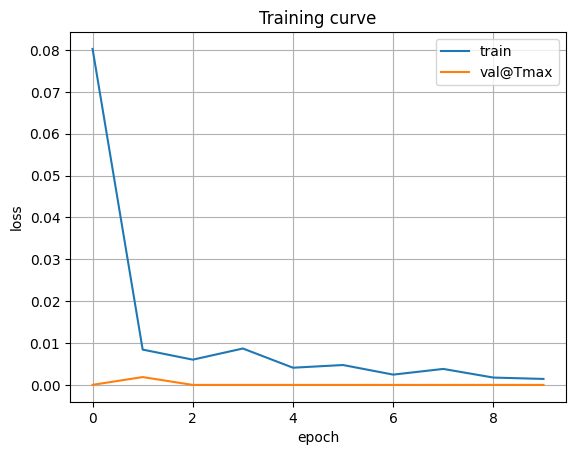

Loss vs T: {1: 0.009841001297279103, 2: 7.528086431938487e-06, 4: 1.5098502778849107e-10, 8: 6.5229686062041406e-12}


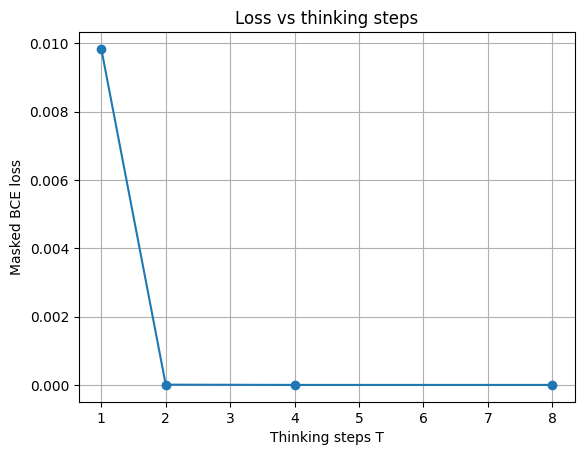

T=1 | mean_moves=135.57 | hit_rate=1.00 | clear_rate=0.00
T=2 | mean_moves=132.63 | hit_rate=1.00 | clear_rate=1.00
T=4 | mean_moves=127.33 | hit_rate=0.00 | clear_rate=1.00
T=8 | mean_moves=130.50 | hit_rate=0.00 | clear_rate=1.00


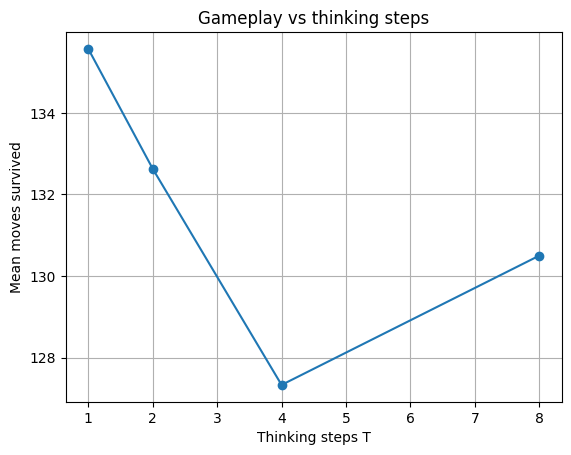

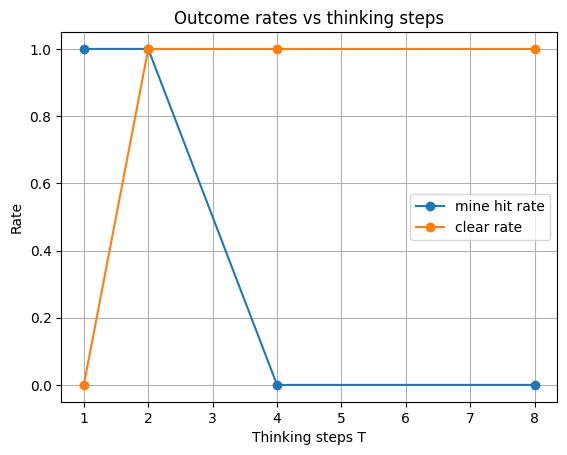

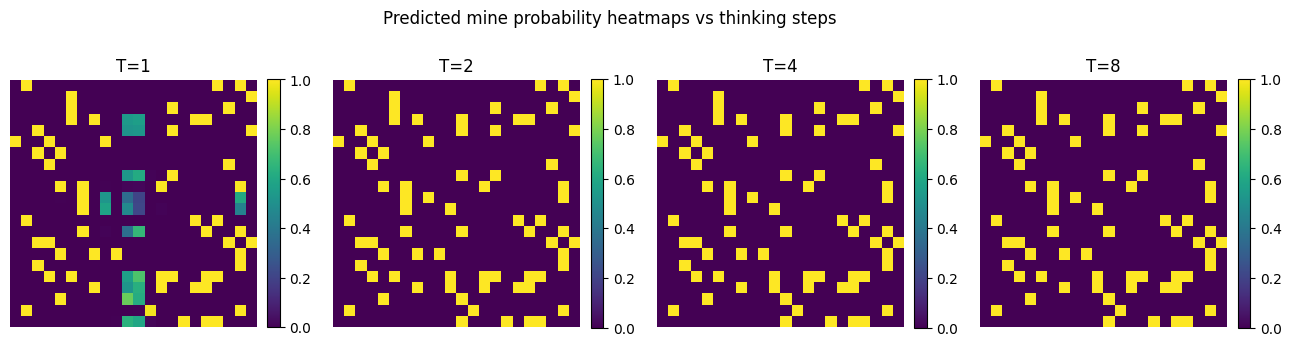

In [137]:

# 2) Train iterative model (stable iterative net + final-step-only loss)
model = StableIterativeMineNet(in_ch=4, hidden=64, n_res=4, alpha_init=0.2, learned_alpha=True)

tr_hist, va_hist = train_iterative_model(
    model,
    train_loader,
    val_loader,
    Tmax=8,
    epochs=10,
    lr=3e-4
)

# 3) Plot training curves
plt.figure()
plt.plot(tr_hist["loss"], label="train")
plt.plot(va_hist["loss"], label="val@Tmax")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training curve")
plt.grid(True)
plt.legend()
plt.show()

# 4) Loss vs thinking steps on val
loss_vs_T = eval_loss_vs_T(model, val_loader, Ts=(1, 2, 4, 8))
print("Loss vs T:", loss_vs_T)
plot_loss_vs_T(loss_vs_T)

# 5) Gameplay performance vs thinking steps
perf = eval_model_bot(model, env_factory, Ts=(1, 2, 4, 8), n_games=100, step_cap=600)
for T in sorted(perf.keys()):
    r = perf[T]
    print(
        f"T={T} | mean_moves={r['mean_moves']:.2f} | "
        f"hit_rate={r['mine_hit_rate']:.2f} | clear_rate={r['clear_rate']:.2f}"
    )
plot_perf_vs_T(perf)

# 6) Heatmaps over time on a single saved state from validation histories
example_entry = val_histories[0][min(5, len(val_histories[0]) - 1)]
plot_heatmaps_over_T(model, example_entry, Ts=(1, 2, 4, 8))

## task 3 analysis
The Task 3 results show that the iterative model is able to rapidly reduce prediction error with only a small number of thinking steps. The training curve drops sharply in the first few epochs and stabilizes near zero loss, while the validation loss at maximum thinking depth remains low and stable. The loss versus thinking steps plot shows a large improvement from one to two steps, followed by saturation, indicating that most useful refinement occurs very early in the iterative process.

Gameplay metrics further support this behavior. Mean moves survived is highest at one to two thinking steps and decreases slightly as thinking depth increases, suggesting that additional iterations do not necessarily translate into better decisions. The outcome rate plot shows that mine hit rate drops to zero and clear rate reaches one hundred percent once the model is allowed multiple refinement steps, indicating confident and consistent decision making. The heatmaps illustrate that predicted mine probabilities become sharper and more decisive with increased thinking depth, concentrating probability mass on specific cells rather than remaining diffuse. Overall, these results demonstrate that iterative computation improves confidence and spatial consistency, but deeper thinking beyond a small threshold yields diminishing returns.
---

#final report
This project explored three progressively more complex approaches to playing Minesweeper using neural networks. The first task focused on predicting mine probabilities directly from partially revealed boards using convolutional architectures that exploit spatial structure. The second task reframed the problem as move prediction using an actor critic framework, where a critic estimates expected survival from a state action pair and an actor selects moves based on those estimates. The third task extended this idea by introducing an iterative model that refines its predictions over multiple internal thinking steps.

All data used for training was generated through self play using a logic based bot as the initial policy. For mine prediction and move prediction, training examples were collected from game trajectories produced by this bot, ensuring that the networks only observed information available to a real player. For the iterative model, game states were sampled in a balanced manner across early mid and late stages of gameplay, which prevented the model from overfitting to trivial early game patterns and encouraged learning across the full difficulty spectrum.

Several techniques were used to improve training stability and reduce overfitting. These included log scaling of survival targets, smooth loss functions, gradient clipping, validation splits, and final step only supervision for the iterative model. Monitoring both prediction loss and gameplay metrics across different configurations helped identify saturation points and avoid unnecessary model complexity. Stratified sampling also played a key role in ensuring that training data remained diverse and representative.

Compared to the logic bot, the learned models show complementary strengths and weaknesses. The neural networks are weaker in situations that require exact symbolic deductions but perform well in ambiguous states where probabilistic reasoning is beneficial. The actor critic approach struggled to outperform the logic bot consistently due to sparse rewards and early decision sensitivity, while the iterative model demonstrated how repeated computation can improve confidence and internal consistency. The primary challenges encountered were long data generation times and runtime instability, which were mitigated through careful sampling strategies, reuse of saved outputs, and focused evaluation of key metrics.